#### BioEncryptSNN — CMA-ES initialisation and full noise-sensitivity evaluation

This notebook evaluates a **bounded Covariance Matrix Adaptation Evolution Strategy (CMA-ES)** for calibrating the main Layer-1 → Layer-2 → Layer-3 ciphertext-transport pathway **without creating or using the Teaching Layer**.

The optimisation and held-out evaluation are deliberately separated:

- CMA-ES fitness is computed only on a fixed, balanced calibration byte sequence that is independent of the vulnerability-dataset test records and independent of the cryptographic keys;
- the Teaching Layer is absent throughout CMA-ES optimisation;
- held-out test ciphertext is never used in the CMA-ES fitness;
- the same CMA-ES-derived transport parameters are reused for S-DES, DES, AES, ChaCha20, RSA and ECIES rather than optimising separately for each cipher;
- the primary evaluation uses **CMA-ES-initialised triplet-STDP training with no Teaching Layer**, followed by teacher-off inference;
- controls distinguish CMA-ES initialisation, triplet-STDP, default initialisation, and the historical Teaching-Layer route.

Successful teacher-independent recovery must therefore be attributable to the Layer-1 → Layer-2 → Layer-3 pathway rather than a direct supervisory connection.

The notebook includes measured triplet-STDP traces, matched ablations, a hierarchical full noise-sensitivity campaign, statistical tests, stage-by-stage latency, classification/leakage controls, reproducibility capture, scalability instrumentation, and strict separation between S-DES and standard DES.

The code does not assume that CMA-ES, plasticity, or the additional cryptographic configurations solve the transport problem. The final evidence audit requires low teacher-off BER and high exact recovery before a lossless-transport claim can be supported.

### Cryptographic scope

Six cryptographic configurations are evaluated through the same byte-oriented SNN transport interface: pedagogical S-DES, legacy standard DES, AES-128-CBC, ChaCha20, RSA-2048-OAEP, and an explicitly defined ECIES profile using P-256 ECDH, HKDF-SHA256, and AES-128-GCM. Cryptographic metadata required for decryption, such as IVs, nonces, authentication tags, and the ECIES ephemeral public key, is serialised with the cryptogram so that the complete decryptable representation passes through the SNN.

### Dedicated full noise experiment

The full noise campaign uses a hierarchical paired repeated-measures protocol. It evaluates the primary teacher-free CMA-ES + triplet-STDP architecture across independent held-out payloads, trained-model instances, noise realisations, noise types, and noise rates.

The notebook separates **noise sensitivity** from **demonstrated robustness**. Robustness is considered interpretable only when the teacher-free zero-noise baseline first satisfies the predeclared BER and exact-recovery criteria.


In [1]:
# =============================================================================
# DEPENDENCY BOOTSTRAP
# =============================================================================
import sys
import subprocess
import importlib
import importlib.util

REQUIRED_PIP_PACKAGES = {
    "Crypto": "pycryptodome",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "psutil": "psutil",
    "tqdm": "tqdm",
    "cma": "cma",
}

for import_name, pip_name in REQUIRED_PIP_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} into the active kernel...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--upgrade", pip_name
        ])
        importlib.invalidate_caches()
    else:
        print(f"Available: {import_name}")

print("Python dependency bootstrap complete.")
print("NEST is intentionally not installed automatically.")


Available: Crypto
Available: scipy
Available: sklearn
Available: psutil
Available: tqdm
Available: cma
Python dependency bootstrap complete.
NEST is intentionally not installed automatically.


In [2]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================
from pathlib import Path

# Dataset ---------------------------------------------------------------------
DATASET_FILENAME = "JSVulnerabilityDataSet-1.0.csv"
LABEL_COLUMN = "Vuln"

PAYLOAD_NUMERIC_COLUMNS = (
    "LOC", "McCC", "CLOC", "LLOC", "NOS",
    "NUMPAR", "HVOL", "HEFF", "HBUGS", "CYCL_DENS",
)

CLASSIFIER_FEATURE_COLUMNS = PAYLOAD_NUMERIC_COLUMNS

TRAIN_ROWS_PER_CLASS = 1
TEST_ROWS_PER_CLASS = 1

# Reproducibility -------------------------------------------------------------
SEED = 42
N_TRIALS = 10
N_BOOTSTRAP = 2000

# Cryptography ----------------------------------------------------------------
CRYPTO_ALGORITHMS = ("S-DES", "DES", "AES", "ChaCha20", "RSA", "ECIES")
RSA_KEY_BITS = 2048
S_DES_KEY = 0b1010000010

# ChaCha20 configuration. The nonce is serialised with the ciphertext.
CHACHA20_KEY_BYTES = 32
CHACHA20_NONCE_BYTES = 12

# Explicit ECIES profile used for reproducible experiments.
# ECIES is a family of constructions, so the curve, KDF, data-encryption
# mechanism, nonce size, tag size and public-key encoding are fixed here.
ECIES_CURVE = "P-256"
ECIES_KDF_KEY_BYTES = 16
ECIES_NONCE_BYTES = 12
ECIES_TAG_BYTES = 16
ECIES_EPHEMERAL_PUBLIC_KEY_BYTES = 65  # uncompressed SEC1 P-256 point
ECIES_COORDINATE_BYTES = 32

# SNN dual-rail architecture --------------------------------------------------
NUM_DATA_BITS = 8
RAILS_PER_BIT = 2
NUM_RAILS = NUM_DATA_BITS * RAILS_PER_BIT

HIDDEN_NEURONS_PER_RAIL = 2

NUM_LAYER1 = NUM_RAILS
NUM_LAYER2 = NUM_RAILS * HIDDEN_NEURONS_PER_RAIL
NUM_LAYER3 = NUM_RAILS
NUM_TEACHING = NUM_RAILS

SIMULATION_RESOLUTION_MS = 0.1

NEURON_PARAMS = {
    "C_m": 250.0,
    "tau_m": 20.0,
    "t_ref": 2.0,
    "E_L": -70.0,
    "V_reset": -70.0,
    "V_th": -55.0,
}

INPUT_CURRENT_ACTIVE_PA = 700.0
INPUT_CURRENT_INACTIVE_PA = 0.0

L1_L2_WEIGHT = 1200.0
L2_L3_INITIAL_WEIGHT = 650.0
L2_L3_WMAX = 1200.0

TEACHING_L3_WEIGHT = 1200.0
L3_PAIR_INHIBITION_WEIGHT = -250.0

# Optional explicit NEST triplet-STDP overrides.
STDP_PARAMETER_OVERRIDES = {}

# Temporal coding -------------------------------------------------------------
TRAIN_EPOCHS = 5
SYMBOL_DURATION_MS = 20.0
INTER_SYMBOL_GAP_MS = 5.0

# Evolution Strategy ----------------------------------------------------------
# CMA-ES calibrates ONLY the main transport pathway. The Teaching Layer is
# absent during fitness evaluation. The fixed calibration sequence is balanced
# and is independent of TRAINING_PLAINTEXT and TEST_PLAINTEXT.
RUN_EVOLUTION_STRATEGY = True
ES_METHOD = "CMA-ES"
ES_GENERATIONS = 12
ES_POPULATION_SIZE = 10
ES_INITIAL_SIGMA = 0.20

# Two matched simulator seeds make fitness less dependent on one NEST run.
ES_EVALUATION_REPLICATES = 2

# Fitness is dominated by BER; tie rate and byte-level errors provide smoother
# discrimination before exact recovery is reached.
ES_FITNESS_WEIGHTS = {
    "ber": 0.65,
    "tie": 0.15,
    "byte_error": 0.15,
    "exact_failure": 0.05,
}

# Search bounds. Wmax is represented by a positive margin over the initial
# L2→L3 weight so Wmax >= initial weight by construction.
ES_SEARCH_BOUNDS = {
    "l1_l2_weight": (700.0, 1800.0),
    "l2_l3_initial_weight": (300.0, 1100.0),
    "l2_l3_wmax_margin": (50.0, 900.0),
    "input_current_active_pa": (450.0, 1000.0),
    "l3_pair_inhibition_magnitude": (20.0, 600.0),
}

# Balanced generic byte patterns. These are calibration stimuli, not held-out
# dataset records and not cryptographic test ciphertext.
ES_CALIBRATION_BYTES = bytes([
    0x00, 0xFF, 0xAA, 0x55,
    0x0F, 0xF0, 0x33, 0xCC,
    0x3C, 0xC3, 0x5A, 0xA5,
    0x01, 0x02, 0x04, 0x08,
    0x10, 0x20, 0x40, 0x80,
])

# ES fitness includes a dominant zero-noise condition plus a small 10-Hz
# excitatory perturbation so the optimiser does not merely sit on a fragile
# threshold. Weights sum to 1.
ES_CALIBRATION_CONDITIONS = (
    ("none", 0.0, 0.75),
    ("poisson_excitatory", 10.0, 0.25),
)

# The primary model used for noise, timing and scalability experiments.
PRIMARY_TRANSPORT_VARIANT = "es_stdp_no_teacher"

# Noise -----------------------------------------------------------------------
NOISE_TYPE = "poisson_excitatory"
NOISE_RATE_HZ = 10.0

TRAIN_NOISE_TYPE = "none"
TRAIN_NOISE_RATE_HZ = 0.0

NOISE_TYPES = (
    "none",
    "poisson_excitatory",
    "poisson_inhibitory",
    "poisson_mixed",
)
NOISE_RATES_HZ = (0.0, 5.0, 10.0, 25.0, 50.0, 100.0)

NOISE_EXCITATORY_WEIGHT = 100.0
NOISE_INHIBITORY_WEIGHT = -100.0

# Experiments -----------------------------------------------------------------
RUN_ABLATION_EXPERIMENT = True
# The original one-payload noise loop is disabled. A dedicated
# hierarchical noise-sensitivity campaign later in the notebook supersedes it.
RUN_NOISE_SWEEP = False

# Full noise-sensitivity campaign -----------------------------------------------
RUN_FULL_NOISE_CAMPAIGN = True

# Hierarchical repeated-measures design:
# 3 trained primary models × 4 mutually disjoint held-out payloads
# × 2 independent noise realisations = 24 paired observations per
# algorithm/noise condition.
FULL_NOISE_MODEL_TRIALS = 3
FULL_NOISE_PAYLOAD_COUNT = 4
FULL_NOISE_ROWS_PER_CLASS = 1
FULL_NOISE_REPLICATES = 2

# Zero-noise reference plus the multi-level perturbation sweep.
FULL_NOISE_RATES_HZ = (0.0, 5.0, 10.0, 25.0, 50.0, 100.0)

# Directional stress controls plus a balanced excitatory/inhibitory
# background condition. For poisson_mixed, the requested total event rate
# is split equally between independent excitatory and inhibitory streams.
FULL_NOISE_TYPES = (
    "poisson_excitatory",
    "poisson_inhibitory",
    "poisson_mixed",
)

# Noise PSC amplitude is defined relative to the forward L1→L2 signal
# synaptic weight. This is more interpretable than an arbitrary fixed value
# and prevents CMA-ES from improving apparent SNR simply by scaling the
# forward signal weights upward.
NOISE_SYNAPTIC_WEIGHT_FRACTION = 0.10

FULL_NOISE_BOOTSTRAP = 4000
RUN_TEACHING_WEIGHT_SWEEP = True
TEACHING_WEIGHT_SWEEP = (0.0, 300.0, 600.0, 900.0, 1200.0)
TEACHING_WEIGHT_SWEEP_TRIALS = 10

RUN_CLASSIFICATION_CONTROL = True
CLASSIFICATION_FOLDS = 5
CLASSIFICATION_REPEATS = 3
RF_TREES = 200

RUN_STAGE_TIMING = True
TIMING_TRIALS = 10
RUN_CONVENTIONAL_CIPHER_BASELINE = True

RUN_SCALABILITY_SWEEP = True
SCALABILITY_TRIALS = 3
SCALABILITY_PAYLOAD_SIZES_BYTES = (128, 256, 512, 1024, 2048)

# Keep False unless the full SNN experiment is actually executed to 1 MB.
RUN_EXTENDED_1KB_TO_1MB_SCALABILITY = False
EXTENDED_SCALABILITY_PAYLOAD_SIZES_BYTES = (
    1024, 4096, 16384, 65536, 262144, 1048576
)

# Scientific validity gate ----------------------------------------------------
MIN_VALID_EXACT_RECOVERY_RATE = 0.95
MAX_VALID_ZERO_NOISE_BER = 0.01

# Spike distances -------------------------------------------------------------
VICTOR_PURPURA_Q_PER_MS = 0.1
VAN_ROSSUM_TAU_MS = 10.0

# Output ----------------------------------------------------------------------
RESULTS_DIR = Path("bioencryptsnn_results_es_full_noise_6_ciphers")
SAVE_WEIGHT_MATRICES = True
SAVE_FIGURES = True
FIGURE_DPI = 200


In [3]:
# =============================================================================
# IMPORTS, DEPENDENCIES, AND VALIDATION
# =============================================================================
from __future__ import annotations

import json
import math
import os
import platform
import random
import struct
import threading
import time
import zlib
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from tqdm.auto import tqdm
import cma

from scipy.stats import wilcoxon, friedmanchisquare, spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline

try:
    import nest
except ImportError:
    nest = None

try:
    import Crypto
    from Crypto.Cipher import AES, DES, ChaCha20, PKCS1_OAEP
    from Crypto.PublicKey import RSA, ECC
    from Crypto.Protocol.KDF import HKDF
    from Crypto.Hash import SHA256
except ImportError:
    Crypto = None
    AES = DES = ChaCha20 = PKCS1_OAEP = RSA = ECC = HKDF = SHA256 = None

VALID_NOISE_TYPES = {
    "none",
    "poisson_excitatory",
    "poisson_inhibitory",
    "poisson_mixed",
}

VALID_CRYPTO_ALGORITHMS = {"S-DES", "DES", "AES", "ChaCha20", "RSA", "ECIES"}

def require_dependencies():
    global nest, Crypto, AES, DES, ChaCha20, PKCS1_OAEP, RSA, ECC, HKDF, SHA256

    missing = []

    if nest is None:
        try:
            import nest as _nest
            nest = _nest
        except ImportError:
            missing.append("NEST Simulator (Python module 'nest')")

    if any(x is None for x in (
        AES, DES, ChaCha20, PKCS1_OAEP, RSA, ECC, HKDF, SHA256
    )):
        try:
            import importlib
            importlib.invalidate_caches()
            import Crypto as _Crypto
            from Crypto.Cipher import (
                AES as _AES,
                DES as _DES,
                ChaCha20 as _ChaCha20,
                PKCS1_OAEP as _PKCS1_OAEP,
            )
            from Crypto.PublicKey import RSA as _RSA, ECC as _ECC
            from Crypto.Protocol.KDF import HKDF as _HKDF
            from Crypto.Hash import SHA256 as _SHA256
            Crypto = _Crypto
            AES = _AES
            DES = _DES
            ChaCha20 = _ChaCha20
            PKCS1_OAEP = _PKCS1_OAEP
            RSA = _RSA
            ECC = _ECC
            HKDF = _HKDF
            SHA256 = _SHA256
        except ImportError:
            missing.append("PyCryptodome")

    if missing:
        raise RuntimeError(
            "Missing required dependencies: " + ", ".join(missing)
        )

def validate_configuration():
    invalid_noise = set(NOISE_TYPES) - VALID_NOISE_TYPES
    invalid_noise.update(
        x for x in (NOISE_TYPE, TRAIN_NOISE_TYPE)
        if x not in VALID_NOISE_TYPES
    )
    if invalid_noise:
        raise ValueError(f"Unsupported noise type(s): {sorted(invalid_noise)}")

    invalid_crypto = set(CRYPTO_ALGORITHMS) - VALID_CRYPTO_ALGORITHMS
    if invalid_crypto:
        raise ValueError(
            f"Unsupported cryptographic algorithm(s): {sorted(invalid_crypto)}"
        )

    if NUM_LAYER1 != NUM_RAILS or NUM_LAYER3 != NUM_RAILS:
        raise ValueError("Dual-rail L1/L3 sizes must equal NUM_RAILS.")

    if NUM_LAYER2 != NUM_RAILS * HIDDEN_NEURONS_PER_RAIL:
        raise ValueError("Layer-2 size does not match the configured rail expansion.")

    if N_TRIALS < 2:
        raise ValueError("N_TRIALS must be >= 2.")

require_dependencies()
validate_configuration()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration validated.")
print("NEST version:", getattr(nest, "__version__", "unknown"))



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Feb 21 2026 14:05:06

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

Configuration validated.
NEST version: 3.9.0


## Reproducibility record

The following cell records the actual machine and software environment used to generate the results, including NEST version, CPU, RAM, OS, simulation resolution, neuron parameters, random seed, repetition count, and the complete installed `stdp_triplet_synapse` defaults.


In [4]:
def json_safe(value):
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    try:
        return float(value)
    except Exception:
        return repr(value)

def linux_cpu_model():
    path = Path("/proc/cpuinfo")
    if path.exists():
        for line in path.read_text(errors="ignore").splitlines():
            if line.lower().startswith("model name"):
                return line.split(":", 1)[1].strip()
    return platform.processor() or "unknown"

def capture_environment():
    vm = psutil.virtual_memory()
    stdp_defaults = nest.GetDefaults("stdp_triplet_synapse")

    return {
        "timestamp_local": time.strftime("%Y-%m-%d %H:%M:%S"),
        "os": platform.platform(),
        "machine": platform.machine(),
        "cpu_model": linux_cpu_model(),
        "physical_cpu_count": psutil.cpu_count(logical=False),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "ram_gb": round(vm.total / (1024 ** 3), 3),
        "python_version": platform.python_version(),
        "python_executable": sys.executable,
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "scipy_version": __import__("scipy").__version__,
        "sklearn_version": __import__("sklearn").__version__,
        "matplotlib_version": __import__("matplotlib").__version__,
        "psutil_version": psutil.__version__,
        "pycryptodome_version": getattr(Crypto, "__version__", "unknown"),
        "nest_version": getattr(nest, "__version__", "unknown"),
        "nest_resolution_ms": SIMULATION_RESOLUTION_MS,
        "seed": SEED,
        "n_trials": N_TRIALS,
        "neuron_model": "iaf_psc_alpha",
        "neuron_parameters": NEURON_PARAMS,
        "stdp_model": "stdp_triplet_synapse",
        "stdp_parameter_overrides": STDP_PARAMETER_OVERRIDES,
        "stdp_defaults": json_safe(stdp_defaults),
    }

ENVIRONMENT = capture_environment()

(RESULTS_DIR / "environment.json").write_text(
    json.dumps(ENVIRONMENT, indent=2)
)
(RESULTS_DIR / "stdp_triplet_defaults.json").write_text(
    json.dumps(ENVIRONMENT["stdp_defaults"], indent=2)
)

display(pd.DataFrame({
    "field": [
        "OS", "CPU", "RAM (GB)", "Python", "NEST",
        "NumPy", "Pandas", "PyCryptodome", "Seed", "Trials"
    ],
    "value": [
        ENVIRONMENT["os"],
        ENVIRONMENT["cpu_model"],
        ENVIRONMENT["ram_gb"],
        ENVIRONMENT["python_version"],
        ENVIRONMENT["nest_version"],
        ENVIRONMENT["numpy_version"],
        ENVIRONMENT["pandas_version"],
        ENVIRONMENT["pycryptodome_version"],
        ENVIRONMENT["seed"],
        ENVIRONMENT["n_trials"],
    ]
}))


,field,value
0,OS,Linux-7.0.0-28-generic-x86_64-with-glibc2.39
1,CPU,Intel(R) Core(TM) i5-6600 CPU @ 3.30GHz
2,RAM (GB),46.937
3,Python,3.12.3
4,NEST,3.9.0
5,NumPy,2.4.2
6,Pandas,3.0.1
7,PyCryptodome,3.23.0
8,Seed,42
9,Trials,10


## Dataset, disjoint payloads, and classifier input domain

The SNN experiment uses deterministic, disjoint stratified records from the JavaScript vulnerability dataset. The cryptographic payload is a compact binary representation of selected attributes, not the entire raw CSV row.

The independent classification control later in the notebook uses only the configured tabular software metrics. Ciphertext, keys, nonces, spike counts, BER and spike distances are never classifier inputs.


In [5]:
def resolve_dataset_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Put it beside the notebook or edit DATASET_FILENAME."
    )

def stable_seed(*parts: object) -> int:
    payload = "|".join(str(p) for p in (SEED,) + parts).encode("utf-8")
    return (SEED + zlib.crc32(payload)) % (2**31 - 1)

DATASET_PATH = resolve_dataset_path(DATASET_FILENAME)
dataset = pd.read_csv(DATASET_PATH)

required_columns = {
    "name", "path", LABEL_COLUMN,
    *PAYLOAD_NUMERIC_COLUMNS,
    *CLASSIFIER_FEATURE_COLUMNS,
}
missing_columns = required_columns - set(dataset.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

def stratified_disjoint_sample(
    df: pd.DataFrame,
    train_rows_per_class: int,
    test_rows_per_class: int,
):
    train_parts, test_parts = [], []

    for class_value in sorted(df[LABEL_COLUMN].dropna().unique()):
        group = df[df[LABEL_COLUMN] == class_value]
        needed = train_rows_per_class + test_rows_per_class

        if len(group) < needed:
            raise ValueError(
                f"Class {class_value} has {len(group)} rows; {needed} required."
            )

        shuffled = group.sample(
            frac=1.0,
            random_state=stable_seed("dataset", class_value),
        )
        train_parts.append(shuffled.iloc[:train_rows_per_class])
        test_parts.append(shuffled.iloc[train_rows_per_class:needed])

    train_df = pd.concat(train_parts).sort_index().copy()
    test_df = pd.concat(test_parts).sort_index().copy()

    overlap = set(train_df.index).intersection(test_df.index)
    if overlap:
        raise RuntimeError(f"Train/test overlap detected: {sorted(overlap)}")

    return train_df, test_df

def dataframe_to_binary_payload(df: pd.DataFrame) -> bytes:
    payload = bytearray()
    payload.extend(b"JSV2")
    payload.extend(struct.pack("<H", len(df)))
    payload.extend(struct.pack("<B", len(PAYLOAD_NUMERIC_COLUMNS)))

    for _, row in df.iterrows():
        name_crc = zlib.crc32(str(row["name"]).encode("utf-8")) & 0xFFFFFFFF
        path_crc = zlib.crc32(str(row["path"]).encode("utf-8")) & 0xFFFFFFFF
        payload.extend(struct.pack("<II", name_crc, path_crc))

        for column in PAYLOAD_NUMERIC_COLUMNS:
            value = pd.to_numeric(
                pd.Series([row[column]]), errors="coerce"
            ).iloc[0]
            if pd.isna(value):
                value = 0.0
            payload.extend(struct.pack("<f", np.float32(value)))

        payload.extend(struct.pack("<B", int(row[LABEL_COLUMN])))

    return bytes(payload)

train_records, test_records = stratified_disjoint_sample(
    dataset,
    TRAIN_ROWS_PER_CLASS,
    TEST_ROWS_PER_CLASS,
)

TRAINING_PLAINTEXT = dataframe_to_binary_payload(train_records)
TEST_PLAINTEXT = dataframe_to_binary_payload(test_records)

print(f"Dataset: {DATASET_PATH}")
print(f"Rows: {len(dataset):,}; columns: {dataset.shape[1]}")
print("Class distribution:")
display(dataset[LABEL_COLUMN].value_counts().sort_index().rename("count").to_frame())

print(f"Training records: {len(train_records)}")
print(f"Held-out records: {len(test_records)}")
print(f"Training payload: {len(TRAINING_PLAINTEXT)} bytes")
print(f"Held-out payload: {len(TEST_PLAINTEXT)} bytes")


# =============================================================================
# FULL-NOISE HELD-OUT PAYLOAD BANK
# =============================================================================

def build_full_noise_payload_bank(
    df: pd.DataFrame,
    *,
    exclude_indices,
    payload_count: int,
    rows_per_class: int,
):
    """
    Construct balanced, mutually disjoint payloads reserved exclusively for
    the full noise campaign.

    These records do not appear in the SNN training payload or in the original
    held-out payload used for the architecture ablation.
    """
    excluded = set(int(i) for i in exclude_indices)
    available = df.loc[~df.index.isin(excluded)].copy()

    classes = sorted(
        available[LABEL_COLUMN]
        .dropna()
        .unique()
    )

    required_per_class = (
        payload_count
        * rows_per_class
    )

    class_orders = {}

    for class_value in classes:
        group = available[
            available[LABEL_COLUMN]
            == class_value
        ].copy()

        if len(group) < required_per_class:
            raise ValueError(
                f"Class {class_value} has {len(group)} unused rows; "
                f"{required_per_class} are required."
            )

        class_orders[class_value] = (
            group.sample(
                frac=1.0,
                random_state=stable_seed(
                    "full-noise-bank",
                    class_value,
                ),
            )
        )

    payloads = []
    manifest = []
    used_indices = set()

    for payload_id in range(
        payload_count
    ):
        parts = []

        for class_value in classes:
            start = (
                payload_id
                * rows_per_class
            )
            stop = (
                start
                + rows_per_class
            )

            selected = (
                class_orders[
                    class_value
                ]
                .iloc[start:stop]
                .copy()
            )

            parts.append(
                selected
            )

        frame = (
            pd.concat(parts)
            .sort_index()
            .copy()
        )

        current_indices = {
            int(i)
            for i in frame.index
        }

        overlap = (
            used_indices
            .intersection(
                current_indices
            )
        )

        if overlap:
            raise RuntimeError(
                "Full-noise payload overlap: "
                f"{sorted(overlap)}"
            )

        used_indices.update(
            current_indices
        )

        plaintext = (
            dataframe_to_binary_payload(
                frame
            )
        )

        payloads.append({
            "payload_id": int(
                payload_id
            ),
            "frame": frame,
            "plaintext": plaintext,
            "row_indices": sorted(
                current_indices
            ),
        })

        for (
            row_index,
            row,
        ) in frame.iterrows():
            manifest.append({
                "payload_id": int(
                    payload_id
                ),
                "dataset_row_index": int(
                    row_index
                ),
                "label": int(
                    row[LABEL_COLUMN]
                ),
                "name": str(
                    row["name"]
                ),
                "path": str(
                    row["path"]
                ),
                "payload_bytes": len(
                    plaintext
                ),
            })

    return (
        payloads,
        pd.DataFrame(
            manifest
        ),
    )


_noise_excluded_indices = set(
    int(i)
    for i in train_records.index
).union(
    int(i)
    for i in test_records.index
)

(
    FULL_NOISE_PAYLOADS,
    full_noise_payload_manifest,
) = build_full_noise_payload_bank(
    dataset,
    exclude_indices=(
        _noise_excluded_indices
    ),
    payload_count=(
        FULL_NOISE_PAYLOAD_COUNT
    ),
    rows_per_class=(
        FULL_NOISE_ROWS_PER_CLASS
    ),
)

full_noise_payload_manifest.to_csv(
    RESULTS_DIR
    / "full_noise_payload_manifest.csv",
    index=False,
)

print(
    "Full-noise payload count:",
    len(FULL_NOISE_PAYLOADS),
)
print(
    "Full-noise payload sizes:",
    [
        len(item["plaintext"])
        for item in FULL_NOISE_PAYLOADS
    ],
)
print(
    "Overlap with SNN training/core-test records:",
    bool(
        _noise_excluded_indices
        .intersection(
            set(
                full_noise_payload_manifest[
                    "dataset_row_index"
                ].tolist()
            )
        )
    ),
)


Dataset: /opt/data/BioEncryptSNN-Encryption-and-Decryption-Using-Spiking-Neural-Networks/JSVulnerabilityDataSet-1.0.csv
Rows: 12,125; columns: 44
Class distribution:


,count
Vuln,
0,10629
1,1496


Training records: 2
Held-out records: 2
Training payload: 105 bytes
Held-out payload: 105 bytes
Full-noise payload count: 4
Full-noise payload sizes: [105, 105, 105, 105]
Overlap with SNN training/core-test records: False


## Independent Random Forest and label-shuffle negative control

Classification is deliberately separated from SNN transport. The classifier receives only source/decrypted-domain software metrics.


In [6]:
def run_classification_control(df: pd.DataFrame) -> pd.DataFrame:
    X = df.loc[:, CLASSIFIER_FEATURE_COLUMNS].copy()
    y = df[LABEL_COLUMN].astype(int).to_numpy()

    forbidden = ("cipher", "spike", "ber", "key", "nonce", "iv")
    for column in X.columns:
        if any(token in str(column).lower() for token in forbidden):
            raise RuntimeError(
                f"Forbidden cryptographic/SNN feature entered classifier: {column}"
            )

    X = X.replace([np.inf, -np.inf], np.nan)

    cv = RepeatedStratifiedKFold(
        n_splits=CLASSIFICATION_FOLDS,
        n_repeats=CLASSIFICATION_REPEATS,
        random_state=SEED,
    )

    rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        def make_model(seed):
            return Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("rf", RandomForestClassifier(
                    n_estimators=RF_TREES,
                    class_weight="balanced",
                    random_state=seed,
                    n_jobs=-1,
                )),
            ])

        model = make_model(stable_seed("rf", fold))
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rows.append({
            "control": "true_labels",
            "fold": fold,
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
        })

        rng = np.random.default_rng(stable_seed("shuffle", fold))
        shuffled_y_train = rng.permutation(y_train)

        shuffled_model = make_model(stable_seed("rf-shuffled", fold))
        shuffled_model.fit(X_train, shuffled_y_train)
        shuffled_pred = shuffled_model.predict(X_test)

        rows.append({
            "control": "shuffled_labels",
            "fold": fold,
            "accuracy": accuracy_score(y_test, shuffled_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, shuffled_pred),
            "precision": precision_score(y_test, shuffled_pred, zero_division=0),
            "recall": recall_score(y_test, shuffled_pred, zero_division=0),
            "f1": f1_score(y_test, shuffled_pred, zero_division=0),
        })

    return pd.DataFrame(rows)

classification_results = pd.DataFrame()

if RUN_CLASSIFICATION_CONTROL:
    classification_results = run_classification_control(dataset)
    classification_results.to_csv(
        RESULTS_DIR / "classification_label_shuffle_control.csv",
        index=False,
    )

    display(
        classification_results.groupby("control")[
            ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]
        ].agg(["mean", "std"])
    )


accuracy           balanced_accuracy           precision  \
                     mean       std              mean       std      mean   
control                                                                     
shuffled_labels  0.744990  0.013906          0.491446  0.018735  0.113065   
true_labels      0.939766  0.003438          0.839662  0.009902  0.784192   

                             recall                  f1            
                      std      mean       std      mean       std  
control                                                            
shuffled_labels  0.024335  0.154841  0.030268  0.130552  0.026619  
true_labels      0.019912  0.706765  0.020004  0.743246  0.014877

## Cryptographic contexts

The SNN transport interface is byte-oriented and is shared across six cryptographic configurations. `S-DES` denotes the 10-bit pedagogical Simplified DES implementation, whereas `DES` denotes the standard 56-bit legacy cipher; they are treated as separate algorithms. AES uses AES-128-CBC with PKCS#7 padding, ChaCha20 uses a 256-bit key with a serialised 96-bit nonce, RSA uses RSA-2048 with OAEP, and ECIES uses a fixed P-256 ECDH + HKDF-SHA256 + AES-128-GCM profile.

For AES, DES, ChaCha20 and ECIES, the IV/nonce and any authentication metadata required for decryption are serialised into the byte sequence transported by the SNN. The ECIES cryptogram additionally carries the uncompressed ephemeral P-256 public key. This makes each transported representation self-contained for the corresponding conventional decryption step.

Keys, IVs, nonces and ECIES ephemeral keys are generated deterministically from experiment seeds to support exact reproducibility. This deterministic construction is an experimental control and must not be interpreted as production cryptographic key or nonce management.


In [7]:
class DeterministicRandomBytes:
    def __init__(self, seed: int):
        self.rng = np.random.default_rng(seed)

    def __call__(self, n: int) -> bytes:
        return self.rng.integers(0, 256, n, dtype=np.uint8).tobytes()


def _permute(bits, permutation):
    return [bits[i] for i in permutation]


def _sdes_key_schedule(key: int):
    key_bits = [int(x) for x in format(key, "010b")]
    p10 = _permute(key_bits, [2, 4, 1, 6, 3, 9, 0, 8, 7, 5])

    def ls1(k):
        return k[1:] + k[:1]

    def ls2(k):
        return k[2:] + k[:2]

    k1 = _permute(ls1(p10[:5]) + ls1(p10[5:]), [5, 2, 6, 3, 7, 4, 9, 8])
    k2 = _permute(ls2(p10[:5]) + ls2(p10[5:]), [5, 2, 6, 3, 7, 4, 9, 8])
    return k1, k2


def _sdes_round(bits, subkey):
    left, right = bits[:4], bits[4:]
    ep = _permute(right, [3, 0, 1, 2, 1, 2, 3, 0])
    x = [a ^ b for a, b in zip(ep, subkey)]

    s0 = [
        [1, 0, 3, 2], [3, 2, 1, 0],
        [0, 2, 1, 3], [3, 1, 3, 2],
    ]
    s1 = [
        [0, 1, 2, 3], [2, 0, 1, 3],
        [3, 0, 1, 0], [2, 1, 0, 3],
    ]

    def sbox(v, table):
        row = (v[0] << 1) + v[3]
        col = (v[1] << 1) + v[2]
        value = table[row][col]
        return [(value >> 1) & 1, value & 1]

    p4 = _permute(sbox(x[:4], s0) + sbox(x[4:], s1), [1, 3, 2, 0])
    return [a ^ b for a, b in zip(left, p4)] + right


def sdes_encrypt_byte(value: int, key: int) -> int:
    k1, k2 = _sdes_key_schedule(key)
    bits = [int(x) for x in format(value, "08b")]
    bits = _permute(bits, [1, 5, 2, 0, 3, 7, 4, 6])
    bits = _sdes_round(bits, k1)
    bits = bits[4:] + bits[:4]
    bits = _sdes_round(bits, k2)
    bits = _permute(bits, [3, 0, 2, 4, 6, 1, 7, 5])
    return int("".join(map(str, bits)), 2)


def sdes_decrypt_byte(value: int, key: int) -> int:
    k1, k2 = _sdes_key_schedule(key)
    bits = [int(x) for x in format(value, "08b")]
    bits = _permute(bits, [1, 5, 2, 0, 3, 7, 4, 6])
    bits = _sdes_round(bits, k2)
    bits = bits[4:] + bits[:4]
    bits = _sdes_round(bits, k1)
    bits = _permute(bits, [3, 0, 2, 4, 6, 1, 7, 5])
    return int("".join(map(str, bits)), 2)


@dataclass
class CryptoContext:
    name: str
    encrypt: Callable[[bytes, str], bytes]
    decrypt: Callable[[bytes], bytes]
    metadata: Dict[str, object]


def _pkcs7_pad(data: bytes, block_size: int) -> bytes:
    p = block_size - (len(data) % block_size)
    return data + bytes([p]) * p


def _pkcs7_unpad(data: bytes, block_size: int) -> bytes:
    if not data:
        raise ValueError("Empty padded plaintext.")
    p = data[-1]
    if p < 1 or p > block_size or data[-p:] != bytes([p]) * p:
        raise ValueError("Invalid PKCS#7 padding.")
    return data[:-p]


def _ecies_derive_key(shared_point) -> bytes:
    """Derive the AES-128-GCM key from the P-256 ECDH shared point."""
    shared_x = int(shared_point.x).to_bytes(ECIES_COORDINATE_BYTES, "big")
    return HKDF(
        master=shared_x,
        key_len=ECIES_KDF_KEY_BYTES,
        salt=b"",
        hashmod=SHA256,
        context=b"BioEncryptSNN-ECIES-P256-HKDF-SHA256-AES128GCM",
    )


def build_crypto_context(algorithm: str) -> CryptoContext:
    """
    Build one reproducible cryptographic wrapper.

    All wrappers return a self-contained cryptogram as bytes. Metadata required
    for conventional decryption (IVs, nonces, tags and the ECIES ephemeral
    public key) is serialised into that byte string so that the SNN transports
    the complete representation required by the corresponding decryptor.

    Deterministic experiment seeds are used for reproducibility only; these
    wrappers are not examples of production key or nonce management.
    """

    if algorithm == "S-DES":
        def encrypt(data: bytes, token="default"):
            return bytes(sdes_encrypt_byte(v, S_DES_KEY) for v in data)

        def decrypt(data: bytes):
            return bytes(sdes_decrypt_byte(v, S_DES_KEY) for v in data)

        return CryptoContext(
            "S-DES",
            encrypt,
            decrypt,
            {
                "class": "symmetric block cipher",
                "key_bits": 10,
                "purpose": "pedagogical Simplified DES",
                "wire_format": "ciphertext",
            },
        )

    if algorithm == "DES":
        rng = np.random.default_rng(stable_seed("DES-key"))
        key = rng.integers(0, 256, 8, dtype=np.uint8).tobytes()

        def encrypt(data: bytes, token="default"):
            iv_rng = np.random.default_rng(stable_seed("DES-iv", token))
            iv = iv_rng.integers(0, 256, DES.block_size, dtype=np.uint8).tobytes()
            padded = _pkcs7_pad(data, DES.block_size)
            ct = DES.new(key, DES.MODE_CBC, iv).encrypt(padded)
            return iv + ct

        def decrypt(data: bytes):
            if len(data) < DES.block_size or (len(data) - DES.block_size) % DES.block_size:
                raise ValueError("Invalid DES cryptogram length.")
            iv, ct = data[:DES.block_size], data[DES.block_size:]
            recovered = DES.new(key, DES.MODE_CBC, iv).decrypt(ct)
            return _pkcs7_unpad(recovered, DES.block_size)

        return CryptoContext(
            "DES",
            encrypt,
            decrypt,
            {
                "class": "symmetric block cipher",
                "key_bits": 56,
                "mode": "CBC",
                "padding": "PKCS#7",
                "wire_format": "8-byte IV || ciphertext",
                "security_status": "legacy; not recommended for modern deployment",
            },
        )

    if algorithm == "AES":
        rng = np.random.default_rng(stable_seed("AES-key"))
        key = rng.integers(0, 256, AES.block_size, dtype=np.uint8).tobytes()

        def encrypt(data: bytes, token="default"):
            iv_rng = np.random.default_rng(stable_seed("AES-iv", token))
            iv = iv_rng.integers(0, 256, AES.block_size, dtype=np.uint8).tobytes()
            padded = _pkcs7_pad(data, AES.block_size)
            ct = AES.new(key, AES.MODE_CBC, iv).encrypt(padded)
            return iv + ct

        def decrypt(data: bytes):
            if len(data) < AES.block_size or (len(data) - AES.block_size) % AES.block_size:
                raise ValueError("Invalid AES cryptogram length.")
            iv, ct = data[:AES.block_size], data[AES.block_size:]
            recovered = AES.new(key, AES.MODE_CBC, iv).decrypt(ct)
            return _pkcs7_unpad(recovered, AES.block_size)

        return CryptoContext(
            "AES",
            encrypt,
            decrypt,
            {
                "class": "symmetric block cipher",
                "key_bits": 128,
                "mode": "CBC",
                "padding": "PKCS#7",
                "wire_format": "16-byte IV || ciphertext",
            },
        )

    if algorithm == "ChaCha20":
        rng = np.random.default_rng(stable_seed("ChaCha20-key"))
        key = rng.integers(0, 256, CHACHA20_KEY_BYTES, dtype=np.uint8).tobytes()

        def encrypt(data: bytes, token="default"):
            nonce_rng = np.random.default_rng(stable_seed("ChaCha20-nonce", token))
            nonce = nonce_rng.integers(
                0, 256, CHACHA20_NONCE_BYTES, dtype=np.uint8
            ).tobytes()
            ct = ChaCha20.new(key=key, nonce=nonce).encrypt(data)
            return nonce + ct

        def decrypt(data: bytes):
            if len(data) < CHACHA20_NONCE_BYTES:
                raise ValueError("Invalid ChaCha20 cryptogram length.")
            nonce = data[:CHACHA20_NONCE_BYTES]
            ct = data[CHACHA20_NONCE_BYTES:]
            return ChaCha20.new(key=key, nonce=nonce).decrypt(ct)

        return CryptoContext(
            "ChaCha20",
            encrypt,
            decrypt,
            {
                "class": "symmetric stream cipher",
                "key_bits": CHACHA20_KEY_BYTES * 8,
                "nonce_bits": CHACHA20_NONCE_BYTES * 8,
                "wire_format": f"{CHACHA20_NONCE_BYTES}-byte nonce || ciphertext",
                "authentication": "none (bare ChaCha20)",
            },
        )

    if algorithm == "RSA":
        randfunc = DeterministicRandomBytes(stable_seed("RSA-key"))
        private_key = RSA.generate(RSA_KEY_BITS, randfunc=randfunc)
        public_key = private_key.publickey()

        block_bytes = RSA_KEY_BITS // 8
        # OAEP-SHA256 is fixed explicitly for reproducibility and clarity.
        max_plain = block_bytes - 2 * SHA256.digest_size - 2

        def encrypt(data: bytes, token="default"):
            chunks = [
                data[i:i + max_plain]
                for i in range(0, len(data), max_plain)
            ]
            out = []
            for i, chunk in enumerate(chunks):
                oaep_rand = DeterministicRandomBytes(
                    stable_seed("RSA-OAEP", token, i)
                )
                out.append(
                    PKCS1_OAEP.new(
                        public_key,
                        hashAlgo=SHA256,
                        randfunc=oaep_rand,
                    ).encrypt(chunk)
                )
            return b"".join(out)

        def decrypt(data: bytes):
            if len(data) % block_bytes:
                raise ValueError("Incomplete RSA ciphertext block.")
            return b"".join(
                PKCS1_OAEP.new(
                    private_key,
                    hashAlgo=SHA256,
                ).decrypt(
                    data[i:i + block_bytes]
                )
                for i in range(0, len(data), block_bytes)
            )

        return CryptoContext(
            "RSA",
            encrypt,
            decrypt,
            {
                "class": "asymmetric public-key cryptosystem",
                "key_bits": RSA_KEY_BITS,
                "padding": "OAEP-SHA256",
                "ciphertext_block_bytes": block_bytes,
                "wire_format": "concatenated RSA-OAEP ciphertext blocks",
            },
        )

    if algorithm == "ECIES":
        # ECIES is a construction family. This notebook fixes an explicit
        # interoperable experimental profile: P-256 ECDH -> HKDF-SHA256 ->
        # AES-128-GCM. The complete cryptogram is transported by the SNN.
        recipient_private = ECC.generate(
            curve=ECIES_CURVE,
            randfunc=DeterministicRandomBytes(stable_seed("ECIES-recipient-key")),
        )
        recipient_public = recipient_private.public_key()

        def encrypt(data: bytes, token="default"):
            ephemeral_private = ECC.generate(
                curve=ECIES_CURVE,
                randfunc=DeterministicRandomBytes(
                    stable_seed("ECIES-ephemeral-key", token)
                ),
            )
            ephemeral_public_bytes = ephemeral_private.public_key().export_key(
                format="SEC1",
                compress=False,
            )
            if len(ephemeral_public_bytes) != ECIES_EPHEMERAL_PUBLIC_KEY_BYTES:
                raise RuntimeError(
                    "Unexpected ECIES ephemeral public-key encoding length: "
                    f"{len(ephemeral_public_bytes)}"
                )

            shared_point = recipient_public.pointQ * int(ephemeral_private.d)
            dem_key = _ecies_derive_key(shared_point)

            nonce = DeterministicRandomBytes(
                stable_seed("ECIES-GCM-nonce", token)
            )(ECIES_NONCE_BYTES)
            cipher = AES.new(
                dem_key,
                AES.MODE_GCM,
                nonce=nonce,
                mac_len=ECIES_TAG_BYTES,
            )
            ct, tag = cipher.encrypt_and_digest(data)
            return ephemeral_public_bytes + nonce + tag + ct

        def decrypt(data: bytes):
            header_bytes = (
                ECIES_EPHEMERAL_PUBLIC_KEY_BYTES
                + ECIES_NONCE_BYTES
                + ECIES_TAG_BYTES
            )
            if len(data) < header_bytes:
                raise ValueError("Invalid ECIES cryptogram length.")

            p0 = 0
            p1 = p0 + ECIES_EPHEMERAL_PUBLIC_KEY_BYTES
            p2 = p1 + ECIES_NONCE_BYTES
            p3 = p2 + ECIES_TAG_BYTES

            ephemeral_public_bytes = data[p0:p1]
            nonce = data[p1:p2]
            tag = data[p2:p3]
            ct = data[p3:]

            ephemeral_public = ECC.import_key(
                ephemeral_public_bytes,
                curve_name=ECIES_CURVE,
            )
            shared_point = ephemeral_public.pointQ * int(recipient_private.d)
            dem_key = _ecies_derive_key(shared_point)

            cipher = AES.new(
                dem_key,
                AES.MODE_GCM,
                nonce=nonce,
                mac_len=ECIES_TAG_BYTES,
            )
            return cipher.decrypt_and_verify(ct, tag)

        return CryptoContext(
            "ECIES",
            encrypt,
            decrypt,
            {
                "class": "asymmetric hybrid encryption",
                "curve": ECIES_CURVE,
                "key_agreement": "ECDH",
                "kdf": "HKDF-SHA256",
                "dem": "AES-128-GCM",
                "nonce_bits": ECIES_NONCE_BYTES * 8,
                "tag_bits": ECIES_TAG_BYTES * 8,
                "wire_format": (
                    f"{ECIES_EPHEMERAL_PUBLIC_KEY_BYTES}-byte ephemeral SEC1 public key || "
                    f"{ECIES_NONCE_BYTES}-byte nonce || {ECIES_TAG_BYTES}-byte GCM tag || ciphertext"
                ),
            },
        )

    raise ValueError(f"Unsupported cryptographic algorithm: {algorithm}")


# Backwards-compatible helper retained for any external code that imported it.
def build_standard_des_context():
    return build_crypto_context("DES")


CRYPTO_CONTEXTS = {
    algorithm: build_crypto_context(algorithm)
    for algorithm in CRYPTO_ALGORITHMS
}


def validate_crypto_context_roundtrips():
    """Fail early if any cryptographic wrapper cannot round-trip clean data."""
    probe = b"BioEncryptSNN cryptographic context self-check"
    rows = []

    for algorithm, context in CRYPTO_CONTEXTS.items():
        cryptogram = context.encrypt(probe, token=f"self-check-{algorithm}")
        recovered = context.decrypt(cryptogram)
        ok = recovered == probe
        rows.append({
            "algorithm": algorithm,
            "probe_plaintext_bytes": len(probe),
            "probe_cryptogram_bytes": len(cryptogram),
            "roundtrip_ok": ok,
        })
        if not ok:
            raise RuntimeError(f"Cryptographic round-trip failed for {algorithm}.")

    return pd.DataFrame(rows)


crypto_self_check = validate_crypto_context_roundtrips()
display(crypto_self_check)

TRAIN_CIPHERTEXT = {
    algorithm: context.encrypt(TRAINING_PLAINTEXT, token="train")
    for algorithm, context in CRYPTO_CONTEXTS.items()
}

TEST_CIPHERTEXT = {
    algorithm: context.encrypt(TEST_PLAINTEXT, token="test")
    for algorithm, context in CRYPTO_CONTEXTS.items()
}

display(pd.DataFrame([
    {
        "algorithm": algorithm,
        "training_ciphertext_bytes": len(TRAIN_CIPHERTEXT[algorithm]),
        "heldout_ciphertext_bytes": len(TEST_CIPHERTEXT[algorithm]),
        **context.metadata,
    }
    for algorithm, context in CRYPTO_CONTEXTS.items()
]))


,algorithm,probe_plaintext_bytes,probe_cryptogram_bytes,roundtrip_ok
0,S-DES,46,46,True
1,DES,46,56,True
2,AES,46,64,True
3,ChaCha20,46,58,True
4,RSA,46,256,True
5,ECIES,46,139,True


,algorithm,training_ciphertext_bytes,heldout_ciphertext_bytes,class,key_bits,purpose,wire_format,mode,padding,security_status,nonce_bits,authentication,ciphertext_block_bytes,curve,key_agreement,kdf,dem,tag_bits
0,S-DES,105,105,symmetric block cipher,10.0,pedagogical Simplified DES,ciphertext,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DES,120,120,symmetric block cipher,56.0,NaN,8-byte IV || ciphertext,CBC,PKCS#7,legacy; not recommended for modern deployment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AES,128,128,symmetric block cipher,128.0,NaN,16-byte IV || ciphertext,CBC,PKCS#7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ChaCha20,117,117,symmetric stream cipher,256.0,NaN,12-byte nonce || ciphertext,NaN,NaN,NaN,96.0,none (bare ChaCha20),NaN,NaN,NaN,NaN,NaN,NaN
4,RSA,256,256,asymmetric public-key cryptosystem,2048.0,NaN,concatenated RSA-OAEP ciphertext blocks,NaN,OAEP-SHA256,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,NaN
5,ECIES,198,198,asymmetric hybrid encryption,NaN,NaN,65-byte ephemeral SEC1 public key || 12-byte n...,NaN,NaN,NaN,96.0,NaN,NaN,P-256,ECDH,HKDF-SHA256,AES-128-GCM,128.0


## Dual-rail SNN, matched external noise, and training-only Teaching Layer

For each bit `b_i`, two channels are defined: `(i,0)` and `(i,1)`. Exactly one rail is activated per bit per ciphertext byte. Layer 1 expands each rail to a small Layer-2 population. Layer 2 projects only to the corresponding Layer-3 rail. Each Layer-3 rail pair inhibits its competitor.

The Teaching Layer is created only when explicitly requested. Primary `teacher_off` inference creates no Teaching Layer at all.


In [8]:
@dataclass(frozen=True)
class TransportParameters:
    l1_l2_weight: float
    l2_l3_initial_weight: float
    l2_l3_wmax: float
    input_current_active_pa: float
    l3_pair_inhibition_weight: float

    def as_dict(self):
        return {
            "l1_l2_weight": float(self.l1_l2_weight),
            "l2_l3_initial_weight": float(self.l2_l3_initial_weight),
            "l2_l3_wmax": float(self.l2_l3_wmax),
            "input_current_active_pa": float(self.input_current_active_pa),
            "l3_pair_inhibition_weight": float(self.l3_pair_inhibition_weight),
        }

DEFAULT_TRANSPORT_PARAMS = TransportParameters(
    l1_l2_weight=L1_L2_WEIGHT,
    l2_l3_initial_weight=L2_L3_INITIAL_WEIGHT,
    l2_l3_wmax=L2_L3_WMAX,
    input_current_active_pa=INPUT_CURRENT_ACTIVE_PA,
    l3_pair_inhibition_weight=L3_PAIR_INHIBITION_WEIGHT,
)

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def reset_nest(seed: int):
    nest.ResetKernel()
    nest.set_verbosity(20)
    nest.SetKernelStatus({
        "print_time": False,
        "resolution": float(SIMULATION_RESOLUTION_MS),
        "rng_seed": int(seed),
    })

def get_nest_time_ms():
    status = nest.GetKernelStatus()
    if "biological_time" in status:
        return float(status["biological_time"])
    if "time" in status:
        return float(status["time"])
    raise RuntimeError("NEST simulation time is unavailable.")

def rail_index(bit_index: int, bit_value: int) -> int:
    return bit_index * 2 + int(bit_value)

def hidden_indices_for_rail(rail: int) -> List[int]:
    start = rail * HIDDEN_NEURONS_PER_RAIL
    return list(range(start, start + HIDDEN_NEURONS_PER_RAIL))

def byte_to_bits(value: int) -> np.ndarray:
    return np.array(
        [(value >> shift) & 1 for shift in range(7, -1, -1)],
        dtype=np.uint8,
    )

def bytes_to_bits(data: bytes) -> np.ndarray:
    if not data:
        return np.array([], dtype=np.uint8)
    return np.unpackbits(np.frombuffer(data, dtype=np.uint8))

def set_dual_rail_currents(
    nodes,
    bits: Sequence[int],
    transport_params: TransportParameters,
):
    currents = np.full(
        NUM_RAILS,
        float(INPUT_CURRENT_INACTIVE_PA),
        dtype=float,
    )

    for bit_index, bit in enumerate(bits):
        currents[rail_index(bit_index, int(bit))] = (
            transport_params.input_current_active_pa
        )

    for idx, current in enumerate(currents):
        nest.SetStatus(
            nodes[idx:idx+1],
            {"I_e": float(current)},
        )

def zero_currents(nodes):
    nest.SetStatus(
        nodes,
        {"I_e": float(INPUT_CURRENT_INACTIVE_PA)},
    )

def total_presentation_duration_ms(
    n_bytes: int,
    epochs: int = 1,
) -> float:
    return float(
        n_bytes
        * epochs
        * (SYMBOL_DURATION_MS + INTER_SYMBOL_GAP_MS)
    )

def quantise_spike_times_to_nest_grid(
    spike_times,
    duration_ms,
    resolution_ms=SIMULATION_RESOLUTION_MS,
):
    if not spike_times:
        return []

    out = []
    last_step = 0

    for t in spike_times:
        step = int(
            np.ceil(
                (float(t) - 1e-12) / resolution_ms
            )
        )
        step = max(step, 1)

        # Enforce strictly increasing event times after quantisation.
        step = max(step, last_step + 1)
        qt = round(step * resolution_ms, 10)

        if qt >= duration_ms:
            break

        out.append(qt)
        last_step = step

    return out

def poisson_spike_times(
    rate_hz,
    duration_ms,
    rng,
):
    if rate_hz <= 0 or duration_ms <= 0:
        return []

    raw = []
    mean_interval = 1000.0 / float(rate_hz)
    t = float(rng.exponential(mean_interval))

    while t < duration_ms:
        raw.append(t)
        t += float(rng.exponential(mean_interval))

    return quantise_spike_times_to_nest_grid(
        raw,
        duration_ms,
    )

def make_noise_schedule(
    *,
    n_neurons: int,
    noise_type: str,
    rate_hz: float,
    duration_ms: float,
    seed: int,
):
    if noise_type not in VALID_NOISE_TYPES:
        raise ValueError(noise_type)

    schedule = {
        "exc": [[] for _ in range(n_neurons)],
        "inh": [[] for _ in range(n_neurons)],
    }

    if noise_type == "none" or rate_hz <= 0:
        return schedule

    for neuron_index in range(n_neurons):
        if noise_type in {
            "poisson_excitatory",
            "poisson_mixed",
        }:
            rate = (
                rate_hz
                if noise_type == "poisson_excitatory"
                else rate_hz / 2.0
            )
            rng = np.random.default_rng(
                stable_seed(
                    seed,
                    "exc",
                    neuron_index,
                )
            )
            schedule["exc"][neuron_index] = (
                poisson_spike_times(
                    rate,
                    duration_ms,
                    rng,
                )
            )

        if noise_type in {
            "poisson_inhibitory",
            "poisson_mixed",
        }:
            rate = (
                rate_hz
                if noise_type == "poisson_inhibitory"
                else rate_hz / 2.0
            )
            rng = np.random.default_rng(
                stable_seed(
                    seed,
                    "inh",
                    neuron_index,
                )
            )
            schedule["inh"][neuron_index] = (
                poisson_spike_times(
                    rate,
                    duration_ms,
                    rng,
                )
            )

    return schedule


def noise_synaptic_weights(
    transport_params: TransportParameters,
):
    """
    Define noise PSC amplitudes relative to the forward signal pathway.

    Both the final model and every CMA-ES candidate therefore see the same
    noise-to-signal ratio.
    """
    magnitude = (
        float(
            NOISE_SYNAPTIC_WEIGHT_FRACTION
        )
        * float(
            transport_params
            .l1_l2_weight
        )
    )

    return {
        "exc": float(
            magnitude
        ),
        "inh": float(
            -magnitude
        ),
    }


def attach_noise_schedule(
    layer2,
    schedule,
    transport_params: TransportParameters,
):
    created = {
        "exc": [],
        "inh": [],
    }

    weights = (
        noise_synaptic_weights(
            transport_params
        )
    )

    for kind in (
        "exc",
        "inh",
    ):
        weight = (
            weights[kind]
        )

        per_neuron = (
            schedule[kind]
        )

        if len(per_neuron) != len(
            layer2
        ):
            raise ValueError(
                "Noise schedule size does not match Layer 2."
            )

        for idx, times in enumerate(
            per_neuron
        ):
            if not times:
                continue

            generator = nest.Create(
                "spike_generator",
                params={
                    "spike_times": [
                        float(t)
                        for t in times
                    ],
                    "allow_offgrid_times": True,
                    "shift_now_spikes": True,
                },
            )

            nest.Connect(
                generator,
                layer2[
                    idx:idx+1
                ],
                syn_spec={
                    "weight": float(
                        weight
                    )
                },
            )

            created[kind].append(
                generator
            )

    return created

def make_stdp_syn_spec(
    transport_params: TransportParameters,
):
    defaults = nest.GetDefaults(
        "stdp_triplet_synapse"
    )

    unknown = (
        set(STDP_PARAMETER_OVERRIDES)
        - set(defaults)
    )

    if unknown:
        raise ValueError(
            "Unsupported STDP override(s) "
            f"for installed NEST: {sorted(unknown)}"
        )

    if (
        transport_params.l2_l3_wmax
        < transport_params.l2_l3_initial_weight
    ):
        raise ValueError(
            "L2→L3 Wmax must be >= initial weight."
        )

    spec = {
        "synapse_model": "stdp_triplet_synapse",
        "weight": float(
            transport_params.l2_l3_initial_weight
        ),
        "Wmax": float(
            transport_params.l2_l3_wmax
        ),
    }

    spec.update(
        STDP_PARAMETER_OVERRIDES
    )

    return spec

def make_structured_initial_weight_matrix(
    transport_params: TransportParameters,
):
    matrix = np.full(
        (NUM_LAYER2, NUM_LAYER3),
        np.nan,
        dtype=float,
    )

    for rail in range(NUM_RAILS):
        for hidden_index in hidden_indices_for_rail(
            rail
        ):
            matrix[
                hidden_index,
                rail,
            ] = (
                transport_params.l2_l3_initial_weight
            )

    return matrix

def build_network(
    *,
    seed: int,
    plastic_l2_l3: bool,
    frozen_l2_l3_weights: Optional[np.ndarray],
    teacher_enabled: bool,
    teacher_weight: float,
    main_path_enabled: bool,
    noise_schedule: Dict[str, List[List[float]]],
    transport_params: TransportParameters = DEFAULT_TRANSPORT_PARAMS,
):
    set_all_seeds(seed)
    reset_nest(seed)

    layers = {
        "layer1": nest.Create(
            "iaf_psc_alpha",
            NUM_LAYER1,
            params=NEURON_PARAMS,
        ),
        "layer2": nest.Create(
            "iaf_psc_alpha",
            NUM_LAYER2,
            params=NEURON_PARAMS,
        ),
        "layer3": nest.Create(
            "iaf_psc_alpha",
            NUM_LAYER3,
            params=NEURON_PARAMS,
        ),
    }

    if teacher_enabled:
        layers["teaching"] = nest.Create(
            "iaf_psc_alpha",
            NUM_TEACHING,
            params=NEURON_PARAMS,
        )

    recorders = {
        "layer1": nest.Create(
            "spike_recorder"
        ),
        "layer3": nest.Create(
            "spike_recorder"
        ),
    }

    if teacher_enabled:
        recorders["teaching"] = (
            nest.Create(
                "spike_recorder"
            )
        )

    nest.Connect(
        layers["layer1"],
        recorders["layer1"],
    )

    nest.Connect(
        layers["layer3"],
        recorders["layer3"],
    )

    if teacher_enabled:
        nest.Connect(
            layers["teaching"],
            recorders["teaching"],
        )

    if main_path_enabled:
        for rail in range(NUM_RAILS):
            hidden_indices = (
                hidden_indices_for_rail(
                    rail
                )
            )

            for hidden_index in hidden_indices:
                nest.Connect(
                    layers["layer1"][
                        rail:rail+1
                    ],
                    layers["layer2"][
                        hidden_index:
                        hidden_index+1
                    ],
                    syn_spec={
                        "weight": float(
                            transport_params
                            .l1_l2_weight
                        )
                    },
                )

                if plastic_l2_l3:
                    nest.Connect(
                        layers["layer2"][
                            hidden_index:
                            hidden_index+1
                        ],
                        layers["layer3"][
                            rail:rail+1
                        ],
                        syn_spec=(
                            make_stdp_syn_spec(
                                transport_params
                            )
                        ),
                    )
                else:
                    if (
                        frozen_l2_l3_weights
                        is None
                    ):
                        raise ValueError(
                            "Frozen L2→L3 weights "
                            "are required."
                        )

                    w = (
                        frozen_l2_l3_weights[
                            hidden_index,
                            rail,
                        ]
                    )

                    if not np.isfinite(w):
                        raise ValueError(
                            "Missing weight for "
                            f"L2[{hidden_index}]"
                            f"→L3[{rail}]."
                        )

                    nest.Connect(
                        layers["layer2"][
                            hidden_index:
                            hidden_index+1
                        ],
                        layers["layer3"][
                            rail:rail+1
                        ],
                        syn_spec={
                            "weight": float(w)
                        },
                    )

    # Winner-take-most competition between
    # the 0 and 1 rail of each bit.
    for bit_index in range(
        NUM_DATA_BITS
    ):
        rail0 = rail_index(
            bit_index,
            0,
        )
        rail1 = rail_index(
            bit_index,
            1,
        )

        nest.Connect(
            layers["layer3"][
                rail0:rail0+1
            ],
            layers["layer3"][
                rail1:rail1+1
            ],
            syn_spec={
                "weight": float(
                    transport_params
                    .l3_pair_inhibition_weight
                )
            },
        )

        nest.Connect(
            layers["layer3"][
                rail1:rail1+1
            ],
            layers["layer3"][
                rail0:rail0+1
            ],
            syn_spec={
                "weight": float(
                    transport_params
                    .l3_pair_inhibition_weight
                )
            },
        )

    if teacher_enabled:
        nest.Connect(
            layers["teaching"],
            layers["layer3"],
            conn_spec="one_to_one",
            syn_spec={
                "weight": float(
                    teacher_weight
                )
            },
        )

    noise_nodes = (
        attach_noise_schedule(
            layers["layer2"],
            noise_schedule,
            transport_params,
        )
    )

    return {
        "layers": layers,
        "recorders": recorders,
        "noise_nodes": noise_nodes,
        "transport_params": (
            transport_params
        ),
    }

def present_ciphertext(
    network,
    ciphertext: bytes,
    *,
    epochs: int,
    teacher_active: bool,
    collect_windows: bool,
    transport_params: TransportParameters,
):
    layers = network["layers"]
    windows = []
    current_time = (
        get_nest_time_ms()
    )

    for _ in range(epochs):
        for value in ciphertext:
            bits = byte_to_bits(
                value
            )

            set_dual_rail_currents(
                layers["layer1"],
                bits,
                transport_params,
            )

            if "teaching" in layers:
                if teacher_active:
                    set_dual_rail_currents(
                        layers["teaching"],
                        bits,
                        transport_params,
                    )
                else:
                    zero_currents(
                        layers["teaching"]
                    )

            if collect_windows:
                windows.append(
                    (
                        current_time,
                        current_time
                        + SYMBOL_DURATION_MS,
                    )
                )

            nest.Simulate(
                SYMBOL_DURATION_MS
            )
            current_time += (
                SYMBOL_DURATION_MS
            )

            zero_currents(
                layers["layer1"]
            )

            if "teaching" in layers:
                zero_currents(
                    layers["teaching"]
                )

            if (
                INTER_SYMBOL_GAP_MS
                > 0
            ):
                nest.Simulate(
                    INTER_SYMBOL_GAP_MS
                )
                current_time += (
                    INTER_SYMBOL_GAP_MS
                )

    return windows

def extract_l2_l3_weights(
    network
):
    matrix = np.full(
        (NUM_LAYER2, NUM_LAYER3),
        np.nan,
        dtype=float,
    )

    l2 = (
        network["layers"]["layer2"]
    )
    l3 = (
        network["layers"]["layer3"]
    )

    for rail in range(
        NUM_RAILS
    ):
        for hidden_index in (
            hidden_indices_for_rail(
                rail
            )
        ):
            conns = nest.GetConnections(
                l2[
                    hidden_index:
                    hidden_index+1
                ],
                l3[
                    rail:rail+1
                ],
            )

            values = nest.GetStatus(
                conns,
                "weight",
            )

            if len(values) != 1:
                raise RuntimeError(
                    "Expected one "
                    f"L2[{hidden_index}]"
                    f"→L3[{rail}] connection."
                )

            matrix[
                hidden_index,
                rail,
            ] = float(
                values[0]
            )

    return matrix

def weight_trace_rows(
    algorithm,
    trial,
    condition,
    teacher_weight,
    epoch,
    weights,
    parameter_source,
):
    rows = []

    for rail in range(
        NUM_RAILS
    ):
        bit_index = (
            rail // 2
        )
        bit_value = (
            rail % 2
        )

        for hidden_index in (
            hidden_indices_for_rail(
                rail
            )
        ):
            rows.append({
                "algorithm": algorithm,
                "trial": int(trial),
                "training_condition": condition,
                "parameter_source": parameter_source,
                "teacher_weight": float(
                    teacher_weight
                ),
                "epoch": int(epoch),
                "bit_index": int(
                    bit_index
                ),
                "bit_value": int(
                    bit_value
                ),
                "rail": int(rail),
                "hidden_neuron": int(
                    hidden_index
                ),
                "weight": float(
                    weights[
                        hidden_index,
                        rail,
                    ]
                ),
            })

    return rows

def train_l2_l3_weights(
    *,
    algorithm,
    trial,
    ciphertext,
    seed,
    teacher_enabled,
    teacher_weight,
    training_condition,
    noise_schedule,
    transport_params: TransportParameters,
    parameter_source: str,
):
    network = build_network(
        seed=seed,
        plastic_l2_l3=True,
        frozen_l2_l3_weights=None,
        teacher_enabled=teacher_enabled,
        teacher_weight=teacher_weight,
        main_path_enabled=True,
        noise_schedule=noise_schedule,
        transport_params=transport_params,
    )

    trace = []

    initial = extract_l2_l3_weights(
        network
    )

    trace.extend(
        weight_trace_rows(
            algorithm,
            trial,
            training_condition,
            teacher_weight,
            0,
            initial,
            parameter_source,
        )
    )

    for epoch in range(
        1,
        TRAIN_EPOCHS + 1,
    ):
        present_ciphertext(
            network,
            ciphertext,
            epochs=1,
            teacher_active=teacher_enabled,
            collect_windows=False,
            transport_params=transport_params,
        )

        current = (
            extract_l2_l3_weights(
                network
            )
        )

        trace.extend(
            weight_trace_rows(
                algorithm,
                trial,
                training_condition,
                teacher_weight,
                epoch,
                current,
                parameter_source,
            )
        )

    return (
        extract_l2_l3_weights(
            network
        ),
        pd.DataFrame(trace),
    )

def get_events(
    recorders,
    name,
):
    events = nest.GetStatus(
        recorders[name],
        "events",
    )[0]

    return (
        np.asarray(
            events["senders"],
            dtype=int,
        ),
        np.asarray(
            events["times"],
            dtype=float,
        ),
    )

def decode_layer3_bytes(
    layer3,
    senders,
    times,
    windows,
):
    layer3_ids = np.asarray(
        layer3.get("global_id"),
        dtype=int,
    )

    decoded = bytearray()
    ties = 0
    total_bits = 0

    for start, end in windows:
        in_window = (
            (times >= start)
            & (times < end)
        )

        value = 0

        for bit_index in range(
            NUM_DATA_BITS
        ):
            gid0 = layer3_ids[
                rail_index(
                    bit_index,
                    0,
                )
            ]
            gid1 = layer3_ids[
                rail_index(
                    bit_index,
                    1,
                )
            ]

            count0 = int(
                np.sum(
                    in_window
                    & (senders == gid0)
                )
            )
            count1 = int(
                np.sum(
                    in_window
                    & (senders == gid1)
                )
            )

            if count1 > count0:
                bit = 1
            elif count0 > count1:
                bit = 0
            else:
                ties += 1
                bit = 0

            total_bits += 1
            value = (
                (value << 1)
                | bit
            )

        decoded.append(
            value
        )

    tie_fraction = (
        ties / total_bits
        if total_bits
        else 0.0
    )

    return (
        bytes(decoded),
        float(tie_fraction),
    )


## CMA-ES for Teaching-free transport initialisation

The search uses **Covariance Matrix Adaptation Evolution Strategy (CMA-ES)** to calibrate the main transport pathway. The Teaching Layer is absent from every fitness evaluation.

CMA-ES optimises a small, shared parameter vector:

- L1→L2 weight;
- initial L2→L3 weight;
- L2→L3 `Wmax` margin;
- active-rail input current;
- magnitude of Layer-3 0-vs-1 inhibition.

No held-out vulnerability-dataset record, held-out ciphertext, decryption result, cryptographic key, or Teaching-Layer activity enters the CMA-ES fitness. Fitness is evaluated on a fixed, balanced generic byte sequence with matched NEST seeds. The same `ES_BEST_PARAMS` are reused for S-DES, DES, AES, ChaCha20, RSA and ECIES, preventing per-cipher tuning. The optimisation therefore remains cipher-independent at the SNN transport level even though the resulting cryptograms differ in length and structure.

Candidate vectors are represented in normalised `[0,1]` coordinates and CMA-ES is bounded to that domain. Fitness is dominated by BER, with tie fraction, byte error and exact-recovery failure used as secondary terms.


CMA-ES (Teaching-free):   0%|          | 0/120 [00:00<?, ?candidate/s]


CMA-ES COMPLETE
Default transport parameters:
{
  "l1_l2_weight": 1200.0,
  "l2_l3_initial_weight": 650.0,
  "l2_l3_wmax": 1200.0,
  "input_current_active_pa": 700.0,
  "l3_pair_inhibition_weight": -250.0
}

CMA-ES-selected transport parameters:
{
  "l1_l2_weight": 1456.1801952063574,
  "l2_l3_initial_weight": 763.7466297241599,
  "l2_l3_wmax": 1095.1621600200538,
  "input_current_active_pa": 623.2636793059042,
  "l3_pair_inhibition_weight": -189.62442755767904
}


,generation,best_fitness,mean_fitness,mean_ber,best_ber,mean_tie,sigma
0,0,0.061563,0.227594,0.129531,0.006250,0.143906,0.200000
1,1,0.084375,0.286195,0.183594,0.019531,0.205313,0.171136
2,2,0.062500,0.253418,0.135078,0.006250,0.250781,0.150296
3,3,0.000000,0.101520,0.042109,0.000000,0.043906,0.123890
4,4,0.000000,0.105488,0.044219,0.000000,0.090391,0.137525
5,5,0.000000,0.104648,0.046172,0.000000,0.090078,0.143789
6,6,0.000000,0.180137,0.099687,0.000000,0.134766,0.139356
7,7,0.000000,0.107227,0.041250,0.000000,0.084219,0.110666
8,8,0.000000,0.121969,0.054688,0.000000,0.092812,0.095187
9,9,0.000000,0.032785,0.008984,0.000000,0.026719,0.088945


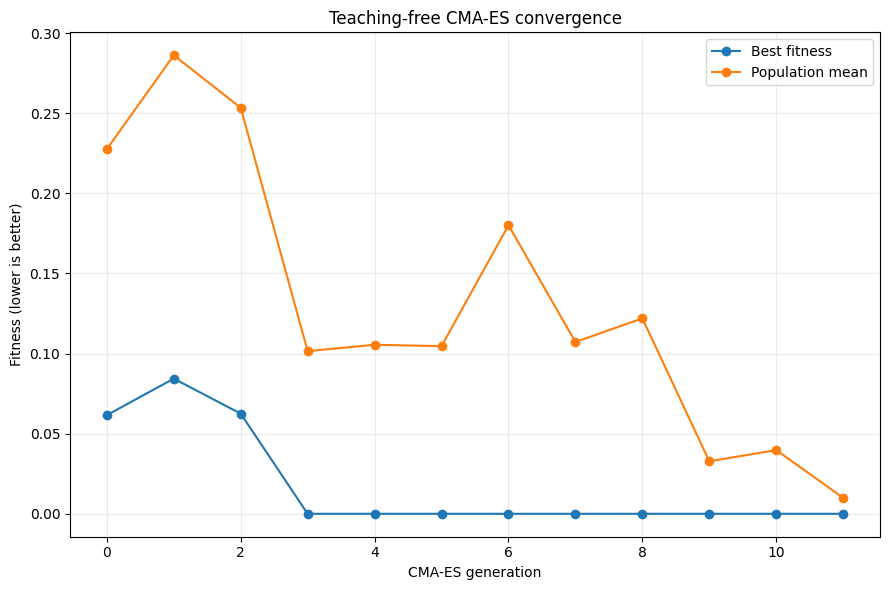

In [9]:
ES_PARAMETER_NAMES = tuple(
    ES_SEARCH_BOUNDS.keys()
)

def _normalise_value(
    value,
    low,
    high,
):
    if high <= low:
        raise ValueError(
            "Invalid ES bound."
        )

    return (
        (float(value) - low)
        / (high - low)
    )

def _denormalise_value(
    unit_value,
    low,
    high,
):
    return (
        low
        + float(unit_value)
        * (high - low)
    )

def default_es_vector():
    values = {
        "l1_l2_weight": (
            DEFAULT_TRANSPORT_PARAMS
            .l1_l2_weight
        ),
        "l2_l3_initial_weight": (
            DEFAULT_TRANSPORT_PARAMS
            .l2_l3_initial_weight
        ),
        "l2_l3_wmax_margin": (
            DEFAULT_TRANSPORT_PARAMS
            .l2_l3_wmax
            - DEFAULT_TRANSPORT_PARAMS
            .l2_l3_initial_weight
        ),
        "input_current_active_pa": (
            DEFAULT_TRANSPORT_PARAMS
            .input_current_active_pa
        ),
        "l3_pair_inhibition_magnitude": (
            abs(
                DEFAULT_TRANSPORT_PARAMS
                .l3_pair_inhibition_weight
            )
        ),
    }

    vector = []

    for name in ES_PARAMETER_NAMES:
        low, high = (
            ES_SEARCH_BOUNDS[name]
        )

        vector.append(
            np.clip(
                _normalise_value(
                    values[name],
                    low,
                    high,
                ),
                0.0,
                1.0,
            )
        )

    return np.asarray(
        vector,
        dtype=float,
    )

def es_vector_to_transport_params(
    vector,
):
    vector = np.asarray(
        vector,
        dtype=float,
    )

    if len(vector) != len(
        ES_PARAMETER_NAMES
    ):
        raise ValueError(
            "Incorrect ES vector length."
        )

    actual = {}

    for i, name in enumerate(
        ES_PARAMETER_NAMES
    ):
        low, high = (
            ES_SEARCH_BOUNDS[name]
        )

        actual[name] = (
            _denormalise_value(
                np.clip(
                    vector[i],
                    0.0,
                    1.0,
                ),
                low,
                high,
            )
        )

    initial = (
        actual[
            "l2_l3_initial_weight"
        ]
    )

    wmax = (
        initial
        + actual[
            "l2_l3_wmax_margin"
        ]
    )

    return TransportParameters(
        l1_l2_weight=(
            actual[
                "l1_l2_weight"
            ]
        ),
        l2_l3_initial_weight=(
            initial
        ),
        l2_l3_wmax=wmax,
        input_current_active_pa=(
            actual[
                "input_current_active_pa"
            ]
        ),
        l3_pair_inhibition_weight=(
            -abs(
                actual[
                    "l3_pair_inhibition_magnitude"
                ]
            )
        ),
    )

def calibration_transport_metrics(
    reference_bytes,
    recovered_bytes,
    tie_fraction,
):
    ref_bits = (
        bytes_to_bits(
            reference_bytes
        )
    )

    rec_bits = (
        bytes_to_bits(
            recovered_bytes
        )
    )

    if len(ref_bits) != len(
        rec_bits
    ):
        raise ValueError(
            "Calibration output length mismatch."
        )

    bit_errors = int(
        np.sum(
            ref_bits != rec_bits
        )
    )

    ber = (
        bit_errors
        / len(ref_bits)
        if len(ref_bits)
        else 0.0
    )

    byte_errors = sum(
        a != b
        for a, b in zip(
            reference_bytes,
            recovered_bytes,
        )
    )

    byte_accuracy = (
        1.0
        - byte_errors
        / len(reference_bytes)
        if reference_bytes
        else 1.0
    )

    return {
        "ber": float(ber),
        "tie_fraction": float(
            tie_fraction
        ),
        "byte_accuracy": float(
            byte_accuracy
        ),
        "exact_recovery": bool(
            recovered_bytes
            == reference_bytes
        ),
    }

def evaluate_es_candidate(
    transport_params,
    *,
    candidate_id,
):
    # CMA-ES calibrates the static initial operating point only.
    # The Teaching Layer is never created here.
    frozen_weights = (
        make_structured_initial_weight_matrix(
            transport_params
        )
    )

    condition_rows = []

    for replicate in range(
        ES_EVALUATION_REPLICATES
    ):
        for (
            noise_type,
            noise_rate,
            condition_weight,
        ) in (
            ES_CALIBRATION_CONDITIONS
        ):
            network_seed = (
                stable_seed(
                    "CMA-ES-network",
                    replicate,
                )
            )

            duration = (
                total_presentation_duration_ms(
                    len(
                        ES_CALIBRATION_BYTES
                    ),
                    1,
                )
            )

            noise_seed = (
                stable_seed(
                    "CMA-ES-noise",
                    replicate,
                    noise_type,
                    noise_rate,
                )
            )

            schedule = (
                make_noise_schedule(
                    n_neurons=(
                        NUM_LAYER2
                    ),
                    noise_type=(
                        noise_type
                    ),
                    rate_hz=(
                        noise_rate
                    ),
                    duration_ms=(
                        duration
                    ),
                    seed=noise_seed,
                )
            )

            network = build_network(
                seed=network_seed,
                plastic_l2_l3=False,
                frozen_l2_l3_weights=(
                    frozen_weights
                ),
                teacher_enabled=False,
                teacher_weight=0.0,
                main_path_enabled=True,
                noise_schedule=(
                    schedule
                ),
                transport_params=(
                    transport_params
                ),
            )

            windows = present_ciphertext(
                network,
                ES_CALIBRATION_BYTES,
                epochs=1,
                teacher_active=False,
                collect_windows=True,
                transport_params=(
                    transport_params
                ),
            )

            senders, times = (
                get_events(
                    network[
                        "recorders"
                    ],
                    "layer3",
                )
            )

            recovered, tie_fraction = (
                decode_layer3_bytes(
                    network[
                        "layers"
                    ][
                        "layer3"
                    ],
                    senders,
                    times,
                    windows,
                )
            )

            metrics = (
                calibration_transport_metrics(
                    ES_CALIBRATION_BYTES,
                    recovered,
                    tie_fraction,
                )
            )

            condition_rows.append({
                "candidate_id": (
                    candidate_id
                ),
                "replicate": (
                    replicate
                ),
                "noise_type": (
                    noise_type
                ),
                "noise_rate_hz": (
                    float(
                        noise_rate
                    )
                ),
                "condition_weight": (
                    float(
                        condition_weight
                    )
                ),
                **metrics,
            })

    frame = pd.DataFrame(
        condition_rows
    )

    weighted_rows = []

    for replicate, group in (
        frame.groupby(
            "replicate"
        )
    ):
        weights = (
            group[
                "condition_weight"
            ].to_numpy(
                dtype=float
            )
        )

        weights = (
            weights
            / weights.sum()
        )

        weighted_rows.append({
            "replicate": replicate,
            "ber": float(
                np.average(
                    group["ber"],
                    weights=weights,
                )
            ),
            "tie_fraction": float(
                np.average(
                    group[
                        "tie_fraction"
                    ],
                    weights=weights,
                )
            ),
            "byte_accuracy": float(
                np.average(
                    group[
                        "byte_accuracy"
                    ],
                    weights=weights,
                )
            ),
            "exact_recovery": float(
                np.average(
                    group[
                        "exact_recovery"
                    ].astype(float),
                    weights=weights,
                )
            ),
        })

    aggregate = pd.DataFrame(
        weighted_rows
    )

    mean_ber = float(
        aggregate["ber"].mean()
    )

    mean_tie = float(
        aggregate[
            "tie_fraction"
        ].mean()
    )

    mean_byte_accuracy = float(
        aggregate[
            "byte_accuracy"
        ].mean()
    )

    exact_rate = float(
        aggregate[
            "exact_recovery"
        ].mean()
    )

    fitness = (
        ES_FITNESS_WEIGHTS[
            "ber"
        ] * mean_ber
        + ES_FITNESS_WEIGHTS[
            "tie"
        ] * mean_tie
        + ES_FITNESS_WEIGHTS[
            "byte_error"
        ] * (
            1.0
            - mean_byte_accuracy
        )
        + ES_FITNESS_WEIGHTS[
            "exact_failure"
        ] * (
            1.0
            - exact_rate
        )
    )

    return {
        "fitness": float(
            fitness
        ),
        "mean_ber": mean_ber,
        "mean_tie_fraction": (
            mean_tie
        ),
        "mean_byte_accuracy": (
            mean_byte_accuracy
        ),
        "exact_recovery_rate": (
            exact_rate
        ),
    }, frame

def run_evolution_strategy(
    show_progress=True
):
    if not RUN_EVOLUTION_STRATEGY:
        return (
            DEFAULT_TRANSPORT_PARAMS,
            pd.DataFrame(),
            pd.DataFrame(),
        )

    initial_mean = (
        default_es_vector()
    )

    cma_options = {
        "bounds": [0.0, 1.0],
        "popsize": (
            ES_POPULATION_SIZE
        ),
        "seed": int(
            stable_seed(
                "CMA-ES"
            )
        ),
        "verbose": -9,
        "verb_disp": 0,
        "verb_log": 0,
    }

    strategy = (
        cma.CMAEvolutionStrategy(
            initial_mean.tolist(),
            float(
                ES_INITIAL_SIGMA
            ),
            cma_options,
        )
    )

    history_rows = []
    detail_frames = []

    progress = tqdm(
        total=(
            ES_GENERATIONS
            * ES_POPULATION_SIZE
        ),
        desc=(
            "CMA-ES "
            "(Teaching-free)"
        ),
        unit="candidate",
        dynamic_ncols=True,
        disable=not show_progress,
    )

    try:
        for generation in range(
            ES_GENERATIONS
        ):
            candidate_vectors = [
                np.clip(
                    np.asarray(
                        vector,
                        dtype=float,
                    ),
                    0.0,
                    1.0,
                )
                for vector in strategy.ask()
            ]

            fitness_values = []

            for (
                candidate_index,
                vector,
            ) in enumerate(
                candidate_vectors
            ):

                params = (
                    es_vector_to_transport_params(
                        vector
                    )
                )

                candidate_id = (
                    f"g{generation:02d}_"
                    f"c{candidate_index:02d}"
                )

                if show_progress:
                    progress.set_postfix(
                        generation=(
                            f"{generation+1}/"
                            f"{ES_GENERATIONS}"
                        ),
                        candidate=(
                            f"{candidate_index+1}/"
                            f"{ES_POPULATION_SIZE}"
                        ),
                        sigma=(
                            f"{strategy.sigma:.4f}"
                        ),
                        refresh=True,
                    )

                metrics, detail = (
                    evaluate_es_candidate(
                        params,
                        candidate_id=(
                            candidate_id
                        ),
                    )
                )

                detail[
                    "generation"
                ] = generation

                detail[
                    "candidate_index"
                ] = candidate_index

                detail_frames.append(
                    detail
                )

                fitness_values.append(
                    metrics[
                        "fitness"
                    ]
                )

                history_rows.append({
                    "generation": (
                        generation
                    ),
                    "candidate_index": (
                        candidate_index
                    ),
                    "candidate_id": (
                        candidate_id
                    ),
                    "sigma": float(
                        strategy.sigma
                    ),
                    **metrics,
                    **params.as_dict(),
                })

                if show_progress:
                    progress.update(1)

            # CMA-ES covariance and step-size adaptation.
            strategy.tell(
                [
                    vector.tolist()
                    for vector in candidate_vectors
                ],
                fitness_values,
            )

        best_vector = np.clip(
            np.asarray(
                strategy.result.xbest,
                dtype=float,
            ),
            0.0,
            1.0,
        )

        best_params = (
            es_vector_to_transport_params(
                best_vector
            )
        )

        history = pd.DataFrame(
            history_rows
        )

        detail = (
            pd.concat(
                detail_frames,
                ignore_index=True,
            )
            if detail_frames
            else pd.DataFrame()
        )

        return (
            best_params,
            history,
            detail,
        )

    finally:
        progress.close()

(
    ES_BEST_PARAMS,
    es_history,
    es_condition_details,
) = run_evolution_strategy(
    show_progress=True
)

print()
print("=" * 72)
print("CMA-ES COMPLETE")
print("=" * 72)

print(
    "Default transport parameters:"
)

print(
    json.dumps(
        DEFAULT_TRANSPORT_PARAMS
        .as_dict(),
        indent=2,
    )
)

print(
    "\nCMA-ES-selected transport parameters:"
)

print(
    json.dumps(
        ES_BEST_PARAMS
        .as_dict(),
        indent=2,
    )
)

if not es_history.empty:
    es_history.to_csv(
        RESULTS_DIR
        / "es_history.csv",
        index=False,
    )

    es_condition_details.to_csv(
        RESULTS_DIR
        / "es_condition_details.csv",
        index=False,
    )

    (
        RESULTS_DIR
        / "es_best_parameters.json"
    ).write_text(
        json.dumps(
            ES_BEST_PARAMS
            .as_dict(),
            indent=2,
        )
    )

    generation_summary = (
        es_history
        .groupby(
            "generation",
            as_index=False,
        )
        .agg(
            best_fitness=(
                "fitness",
                "min",
            ),
            mean_fitness=(
                "fitness",
                "mean",
            ),
            mean_ber=(
                "mean_ber",
                "mean",
            ),
            best_ber=(
                "mean_ber",
                "min",
            ),
            mean_tie=(
                "mean_tie_fraction",
                "mean",
            ),
            sigma=(
                "sigma",
                "first",
            ),
        )
    )

    generation_summary.to_csv(
        RESULTS_DIR
        / "es_generation_summary.csv",
        index=False,
    )

    display(
        generation_summary
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        generation_summary[
            "generation"
        ],
        generation_summary[
            "best_fitness"
        ],
        marker="o",
        label="Best fitness",
    )

    plt.plot(
        generation_summary[
            "generation"
        ],
        generation_summary[
            "mean_fitness"
        ],
        marker="o",
        label="Population mean",
    )

    plt.xlabel(
        "CMA-ES generation"
    )
    plt.ylabel(
        "Fitness (lower is better)"
    )
    plt.title(
        "Teaching-free CMA-ES convergence"
    )
    plt.grid(
        alpha=0.25
    )
    plt.legend()
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            RESULTS_DIR
            / "es_fitness_history.png",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


## Recovery and spike-distance metrics


In [10]:
def victor_purpura_distance(t1, t2, q):
    a = np.asarray(t1, dtype=float)
    b = np.asarray(t2, dtype=float)

    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=float)
    dp[:, 0] = np.arange(n + 1)
    dp[0, :] = np.arange(m + 1)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            dp[i, j] = min(
                dp[i-1, j] + 1.0,
                dp[i, j-1] + 1.0,
                dp[i-1, j-1]
                + q * abs(a[i-1] - b[j-1]),
            )

    return float(dp[n, m])

def van_rossum_distance(t1, t2, tau):
    a = np.asarray(t1, dtype=float)
    b = np.asarray(t2, dtype=float)

    def kernel_sum(x, y):
        if len(x) == 0 or len(y) == 0:
            return 0.0

        return float(
            np.exp(
                -np.abs(
                    x[:, None]
                    - y[None, :]
                ) / tau
            ).sum()
        )

    d2 = (
        0.5 * kernel_sum(a, a)
        + 0.5 * kernel_sum(b, b)
        - kernel_sum(a, b)
    )

    return float(
        math.sqrt(
            max(d2, 0.0)
        )
    )

def spike_distance_per_rail(
    network
):
    l1_senders, l1_times = (
        get_events(
            network["recorders"],
            "layer1",
        )
    )

    l3_senders, l3_times = (
        get_events(
            network["recorders"],
            "layer3",
        )
    )

    l1_ids = np.asarray(
        network["layers"][
            "layer1"
        ].get("global_id"),
        dtype=int,
    )

    l3_ids = np.asarray(
        network["layers"][
            "layer3"
        ].get("global_id"),
        dtype=int,
    )

    rows = []

    for rail in range(
        NUM_RAILS
    ):
        a = l1_times[
            l1_senders
            == l1_ids[rail]
        ]

        b = l3_times[
            l3_senders
            == l3_ids[rail]
        ]

        rows.append({
            "rail": rail,
            "bit_index": rail // 2,
            "bit_value": rail % 2,
            "victor_purpura": (
                victor_purpura_distance(
                    a,
                    b,
                    VICTOR_PURPURA_Q_PER_MS,
                )
            ),
            "van_rossum": (
                van_rossum_distance(
                    a,
                    b,
                    VAN_ROSSUM_TAU_MS,
                )
            ),
            "l1_spike_count": len(a),
            "l3_spike_count": len(b),
        })

    return pd.DataFrame(
        rows
    )

def calculate_recovery_metrics(
    reference_ciphertext,
    recovered_ciphertext,
    plaintext,
    decryptor,
):
    ref_bits = bytes_to_bits(
        reference_ciphertext
    )
    rec_bits = bytes_to_bits(
        recovered_ciphertext
    )

    if len(ref_bits) != len(rec_bits):
        raise ValueError(
            "Ciphertext lengths differ; "
            "BER is undefined."
        )

    bit_errors = int(
        np.sum(
            ref_bits != rec_bits
        )
    )

    ber = (
        bit_errors / len(ref_bits)
        if len(ref_bits)
        else 0.0
    )

    byte_errors = sum(
        a != b
        for a, b in zip(
            reference_ciphertext,
            recovered_ciphertext,
        )
    )

    cipher_byte_accuracy = (
        1.0
        - byte_errors
        / len(reference_ciphertext)
        if reference_ciphertext
        else 1.0
    )

    try:
        recovered_plaintext = (
            decryptor(
                recovered_ciphertext
            )
        )
        decryption_success = True
    except Exception:
        recovered_plaintext = None
        decryption_success = False

    exact_plaintext = (
        recovered_plaintext
        == plaintext
        if recovered_plaintext
        is not None
        else False
    )

    if (
        recovered_plaintext
        is not None
        and len(recovered_plaintext)
        == len(plaintext)
    ):
        plaintext_byte_accuracy = (
            1.0
            - sum(
                a != b
                for a, b in zip(
                    recovered_plaintext,
                    plaintext,
                )
            ) / len(plaintext)
        )
    else:
        plaintext_byte_accuracy = np.nan

    return {
        "bit_errors": bit_errors,
        "ber": float(ber),
        "ciphertext_byte_accuracy": float(
            cipher_byte_accuracy
        ),
        "exact_ciphertext_recovery": bool(
            recovered_ciphertext
            == reference_ciphertext
        ),
        "decryption_success": bool(
            decryption_success
        ),
        "exact_plaintext_recovery": bool(
            exact_plaintext
        ),
        "plaintext_byte_accuracy": (
            plaintext_byte_accuracy
        ),
    }

def evaluate_condition(
    *,
    algorithm,
    experiment,
    condition,
    trial,
    ciphertext,
    plaintext,
    decryptor,
    trained_weights,
    teacher_weight,
    network_seed,
    noise_schedule,
    noise_type,
    noise_rate_hz,
    transport_params: TransportParameters,
    parameter_source: str,
):
    # The primary condition has no Teaching Layer in the network at all.
    if condition in {
        "es_stdp_teacher_off",
        "es_static_teacher_off",
        "default_stdp_teacher_off",
        "teacher_assisted_then_off",
    }:
        teacher_enabled = False
        teacher_active = False
        main_path_enabled = True

    elif condition == "teacher_only":
        teacher_enabled = True
        teacher_active = True
        main_path_enabled = False

    elif condition == "full_network":
        teacher_enabled = True
        teacher_active = True
        main_path_enabled = True

    else:
        raise ValueError(
            f"Unknown condition: {condition}"
        )

    network = build_network(
        seed=network_seed,
        plastic_l2_l3=False,
        frozen_l2_l3_weights=(
            trained_weights
            if main_path_enabled
            else None
        ),
        teacher_enabled=teacher_enabled,
        teacher_weight=teacher_weight,
        main_path_enabled=main_path_enabled,
        noise_schedule=noise_schedule,
        transport_params=transport_params,
    )

    t0 = time.perf_counter()

    windows = present_ciphertext(
        network,
        ciphertext,
        epochs=1,
        teacher_active=teacher_active,
        collect_windows=True,
        transport_params=transport_params,
    )

    simulation_wall_s = (
        time.perf_counter()
        - t0
    )

    senders, times = get_events(
        network["recorders"],
        "layer3",
    )

    recovered_ciphertext, tie_fraction = (
        decode_layer3_bytes(
            network["layers"]["layer3"],
            senders,
            times,
            windows,
        )
    )

    metrics = (
        calculate_recovery_metrics(
            reference_ciphertext=(
                ciphertext
            ),
            recovered_ciphertext=(
                recovered_ciphertext
            ),
            plaintext=plaintext,
            decryptor=decryptor,
        )
    )

    distances = (
        spike_distance_per_rail(
            network
        )
    )

    distances.insert(
        0,
        "trial",
        trial,
    )
    distances.insert(
        0,
        "condition",
        condition,
    )
    distances.insert(
        0,
        "experiment",
        experiment,
    )
    distances.insert(
        0,
        "algorithm",
        algorithm,
    )

    row = {
        "algorithm": algorithm,
        "experiment": experiment,
        "condition": condition,
        "trial": int(trial),
        "network_seed": int(
            network_seed
        ),
        "parameter_source": (
            parameter_source
        ),
        "noise_type": noise_type,
        "noise_rate_hz": float(
            noise_rate_hz
        ),
        "teacher_weight": float(
            teacher_weight
        ),
        "ciphertext_bytes": len(
            ciphertext
        ),
        "simulation_wall_s": float(
            simulation_wall_s
        ),
        "decoder_tie_fraction": float(
            tie_fraction
        ),
        "victor_purpura_mean": float(
            distances[
                "victor_purpura"
            ].mean()
        ),
        "van_rossum_mean": float(
            distances[
                "van_rossum"
            ].mean()
        ),
        **metrics,
    }

    return row, distances


## Repeated-trial statistics

Boolean exact-recovery outcomes are converted to 0/1, so their means are recovery proportions. Bootstrap 95% confidence intervals are reported. Teaching-Layer comparisons use paired Wilcoxon tests with Holm correction; Teaching-weight sensitivity uses a Friedman repeated-measures test; noise-rate association uses Spearman's rho.


In [11]:
def bootstrap_mean_ci(values, *, seed, n_bootstrap=N_BOOTSTRAP, confidence=0.95):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if len(arr) == 0:
        return np.nan, np.nan
    if len(arr) == 1:
        return float(arr[0]), float(arr[0])

    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(arr), size=(n_bootstrap, len(arr)))
    means = arr[indices].mean(axis=1)

    alpha = (1.0 - confidence) / 2.0
    return (
        float(np.quantile(means, alpha)),
        float(np.quantile(means, 1.0 - alpha)),
    )

def wilson_interval(successes, n, z=1.959963984540054):
    if n == 0:
        return np.nan, np.nan

    p = successes / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2*n)) / denom
    half = z * math.sqrt(
        p * (1-p) / n + z*z / (4*n*n)
    ) / denom
    return max(0.0, centre-half), min(1.0, centre+half)

def summarise_results(df, group_columns):
    metrics = [
        "ber",
        "bit_errors",
        "ciphertext_byte_accuracy",
        "exact_ciphertext_recovery",
        "decryption_success",
        "exact_plaintext_recovery",
        "plaintext_byte_accuracy",
        "decoder_tie_fraction",
        "victor_purpura_mean",
        "van_rossum_mean",
        "simulation_wall_s",
    ]

    rows = []

    for key, group in df.groupby(list(group_columns), dropna=False):
        if not isinstance(key, tuple):
            key = (key,)

        row = dict(zip(group_columns, key))
        row["n_trials"] = len(group)

        for metric in metrics:
            if metric not in group.columns:
                continue

            values = pd.to_numeric(
                group[metric], errors="coerce"
            ).astype(float).dropna()

            if len(values) == 0:
                continue

            row[f"{metric}_mean"] = float(values.mean())
            row[f"{metric}_std"] = (
                float(values.std(ddof=1)) if len(values) > 1 else 0.0
            )
            row[f"{metric}_median"] = float(values.median())
            row[f"{metric}_q25"] = float(values.quantile(0.25))
            row[f"{metric}_q75"] = float(values.quantile(0.75))

            low, high = bootstrap_mean_ci(
                values.to_numpy(),
                seed=stable_seed("bootstrap", metric, *key),
            )
            row[f"{metric}_ci95_low"] = low
            row[f"{metric}_ci95_high"] = high

            if metric in {
                "exact_ciphertext_recovery",
                "decryption_success",
                "exact_plaintext_recovery",
            }:
                successes = int(values.sum())
                w_low, w_high = wilson_interval(successes, len(values))
                row[f"{metric}_wilson95_low"] = w_low
                row[f"{metric}_wilson95_high"] = w_high

        rows.append(row)

    return pd.DataFrame(rows)

def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running_max = 0.0
    m = len(p)

    for rank, idx in enumerate(order):
        candidate = min(1.0, (m-rank) * p[idx])
        running_max = max(running_max, candidate)
        adjusted[idx] = running_max

    return adjusted

def paired_ablation_tests(results):
    subset = results[
        results["experiment"] == "teaching_ablation"
    ].copy()

    comparisons = [
        ("es_stdp_teacher_off", "es_static_teacher_off"),
        ("es_stdp_teacher_off", "default_stdp_teacher_off"),
        ("es_stdp_teacher_off", "teacher_assisted_then_off"),
        ("es_stdp_teacher_off", "teacher_only"),
        ("es_stdp_teacher_off", "full_network"),
    ]

    rows = []

    for algorithm in CRYPTO_ALGORITHMS:
        alg = subset[subset["algorithm"] == algorithm]
        pivot = alg.pivot_table(
            index="trial",
            columns="condition",
            values="ber",
            aggfunc="first",
        )

        for a, b in comparisons:
            if a not in pivot.columns or b not in pivot.columns:
                continue

            pair = pivot[[a, b]].dropna()
            if len(pair) == 0:
                continue

            diff = pair[a] - pair[b]

            if np.allclose(diff.to_numpy(), 0):
                statistic, p_value = 0.0, 1.0
            else:
                test = wilcoxon(pair[a], pair[b], zero_method="wilcox")
                statistic = float(test.statistic)
                p_value = float(test.pvalue)

            rows.append({
                "algorithm": algorithm,
                "comparison": f"{a} vs {b}",
                "n_pairs": len(pair),
                "mean_delta_ber": float(diff.mean()),
                "median_delta_ber": float(diff.median()),
                "wilcoxon_statistic": statistic,
                "p_value": p_value,
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["p_holm"] = np.nan

        for _, idx in out.groupby("algorithm").groups.items():
            out.loc[idx, "p_holm"] = holm_adjust(
                out.loc[idx, "p_value"].to_numpy()
            )

    return out

def noise_trend_tests(results):
    subset = results[
        results["experiment"] == "noise_sweep"
    ].copy()

    rows = []

    for (algorithm, noise_type), group in subset.groupby(
        ["algorithm", "noise_type"]
    ):
        if noise_type == "none" or group["noise_rate_hz"].nunique() < 2:
            continue

        rho, p = spearmanr(
            group["noise_rate_hz"],
            group["ber"],
        )

        rows.append({
            "algorithm": algorithm,
            "noise_type": noise_type,
            "n": len(group),
            "spearman_rho": float(rho),
            "p_value": float(p),
        })

    return pd.DataFrame(rows)

def teaching_weight_friedman_tests(weight_results):
    rows = []

    for algorithm in CRYPTO_ALGORITHMS:
        subset = weight_results[
            weight_results["algorithm"] == algorithm
        ]

        pivot = subset.pivot_table(
            index="trial",
            columns="teacher_weight",
            values="ber",
            aggfunc="first",
        ).dropna()

        if pivot.shape[0] < 2 or pivot.shape[1] < 3:
            continue

        arrays = [
            pivot[col].to_numpy()
            for col in pivot.columns
        ]

        if all(
            np.allclose(arrays[0], a)
            for a in arrays[1:]
        ):
            statistic, p_value = 0.0, 1.0
        else:
            test = friedmanchisquare(*arrays)
            statistic = float(test.statistic)
            p_value = float(test.pvalue)

        rows.append({
            "algorithm": algorithm,
            "n_matched_trials": len(pivot),
            "n_teacher_weights": len(pivot.columns),
            "friedman_statistic": statistic,
            "p_value": p_value,
        })

    return pd.DataFrame(rows)


## Core experimental runner with Jupyter progress


In [12]:
def iter_noise_settings():
    yield "none", 0.0

    for noise_type in NOISE_TYPES:
        if noise_type == "none":
            continue

        for rate in NOISE_RATES_HZ:
            if rate > 0:
                yield (
                    noise_type,
                    float(rate),
                )

def save_configuration():
    config = {
        "dataset": str(DATASET_PATH),
        "dataset_rows": int(
            len(dataset)
        ),
        "dataset_columns": int(
            dataset.shape[1]
        ),
        "train_indices": [
            int(i)
            for i in train_records.index
        ],
        "test_indices": [
            int(i)
            for i in test_records.index
        ],
        "train_payload_bytes": len(
            TRAINING_PLAINTEXT
        ),
        "test_payload_bytes": len(
            TEST_PLAINTEXT
        ),
        "payload_numeric_columns": list(
            PAYLOAD_NUMERIC_COLUMNS
        ),
        "classifier_feature_columns": list(
            CLASSIFIER_FEATURE_COLUMNS
        ),
        "label_column": LABEL_COLUMN,
        "seed": SEED,
        "n_trials": N_TRIALS,
        "crypto_algorithms": list(
            CRYPTO_ALGORITHMS
        ),
        "reference_noise_type": (
            NOISE_TYPE
        ),
        "reference_noise_rate_hz": (
            NOISE_RATE_HZ
        ),
        "noise_types": list(
            NOISE_TYPES
        ),
        "noise_rates_hz": list(
            NOISE_RATES_HZ
        ),
        "teacher_weight": (
            TEACHING_L3_WEIGHT
        ),
        "teaching_weight_sweep": list(
            TEACHING_WEIGHT_SWEEP
        ),
        "train_epochs": (
            TRAIN_EPOCHS
        ),
        "symbol_duration_ms": (
            SYMBOL_DURATION_MS
        ),
        "inter_symbol_gap_ms": (
            INTER_SYMBOL_GAP_MS
        ),
        "neuron_parameters": (
            NEURON_PARAMS
        ),
        "default_transport_parameters": (
            DEFAULT_TRANSPORT_PARAMS
            .as_dict()
        ),
        "es_transport_parameters": (
            ES_BEST_PARAMS
            .as_dict()
        ),
        "es_method": ES_METHOD,
        "es_generations": (
            ES_GENERATIONS
        ),
        "es_population_size": (
            ES_POPULATION_SIZE
        ),
        "es_initial_sigma": (
            ES_INITIAL_SIGMA
        ),
        "es_evaluation_replicates": (
            ES_EVALUATION_REPLICATES
        ),
        "es_calibration_bytes": [
            int(v)
            for v in ES_CALIBRATION_BYTES
        ],
        "es_calibration_conditions": [
            list(x)
            for x in (
                ES_CALIBRATION_CONDITIONS
            )
        ],
        "primary_transport_variant": (
            PRIMARY_TRANSPORT_VARIANT
        ),
        "teaching_layer_used_in_es": False,
        "teaching_layer_used_in_primary_training": False,
        "teaching_layer_used_in_primary_inference": False,
        "matched_ablation_seeds": True,
        "external_matched_noise_schedules": True,
        "full_noise_campaign": {
            "enabled": RUN_FULL_NOISE_CAMPAIGN,
            "model_trials": FULL_NOISE_MODEL_TRIALS,
            "payload_count": FULL_NOISE_PAYLOAD_COUNT,
            "rows_per_class_per_payload": FULL_NOISE_ROWS_PER_CLASS,
            "noise_replicates": FULL_NOISE_REPLICATES,
            "rates_hz": list(FULL_NOISE_RATES_HZ),
            "types": list(FULL_NOISE_TYPES),
            "noise_synaptic_weight_fraction": (
                NOISE_SYNAPTIC_WEIGHT_FRACTION
            ),
            "statistical_unit": (
                "trained-model x held-out-payload x noise-replicate"
            ),
            "paired_design": True,
        },
    }

    (
        RESULTS_DIR
        / "configuration.json"
    ).write_text(
        json.dumps(
            json_safe(config),
            indent=2,
        )
    )

def calculate_core_experiment_steps():
    total = 0

    noise_count = len(
        list(
            iter_noise_settings()
        )
    )

    for _algorithm in (
        CRYPTO_ALGORITHMS
    ):
        for _trial in range(
            N_TRIALS
        ):
            # Default no-teacher STDP
            total += 1

            # ES-initialised no-teacher STDP
            total += 1

            # ES-initialised teacher-assisted
            # historical comparison only
            total += 1

            if RUN_ABLATION_EXPERIMENT:
                total += 6

            if RUN_NOISE_SWEEP:
                total += noise_count

        if RUN_TEACHING_WEIGHT_SWEEP:
            sweep_trials = min(
                TEACHING_WEIGHT_SWEEP_TRIALS,
                N_TRIALS,
            )

            total += (
                sweep_trials
                * len(
                    TEACHING_WEIGHT_SWEEP
                )
                * 2
            )

    return total

def run_core_experiments(
    show_progress=True
):
    require_dependencies()
    save_configuration()

    all_rows = []
    distance_frames = []
    weight_rows = []
    weight_sweep_rows = []
    weight_cache = {}

    progress = tqdm(
        total=(
            calculate_core_experiment_steps()
        ),
        desc="BioSpikeEncryption",
        unit="step",
        dynamic_ncols=True,
        disable=not show_progress,
        leave=True,
    )

    default_initial_weights = (
        make_structured_initial_weight_matrix(
            DEFAULT_TRANSPORT_PARAMS
        )
    )

    es_initial_weights = (
        make_structured_initial_weight_matrix(
            ES_BEST_PARAMS
        )
    )

    try:
        for algorithm in (
            CRYPTO_ALGORITHMS
        ):
            if show_progress:
                progress.set_description(
                    f"BioSpikeEncryption [{algorithm}]"
                )

            train_ct = (
                TRAIN_CIPHERTEXT[
                    algorithm
                ]
            )
            test_ct = (
                TEST_CIPHERTEXT[
                    algorithm
                ]
            )
            context = (
                CRYPTO_CONTEXTS[
                    algorithm
                ]
            )

            for trial in range(
                N_TRIALS
            ):
                train_seed = (
                    stable_seed(
                        "train-network",
                        algorithm,
                        trial,
                    )
                )

                train_duration = (
                    total_presentation_duration_ms(
                        len(train_ct),
                        TRAIN_EPOCHS,
                    )
                )

                train_noise_seed = (
                    stable_seed(
                        "train-noise",
                        algorithm,
                        trial,
                    )
                )

                train_noise_schedule = (
                    make_noise_schedule(
                        n_neurons=(
                            NUM_LAYER2
                        ),
                        noise_type=(
                            TRAIN_NOISE_TYPE
                        ),
                        rate_hz=(
                            TRAIN_NOISE_RATE_HZ
                        ),
                        duration_ms=(
                            train_duration
                        ),
                        seed=(
                            train_noise_seed
                        ),
                    )
                )

                # =====================================================
                # 1. DEFAULT INITIALISATION + STDP, NO TEACHING LAYER
                # =====================================================
                if show_progress:
                    progress.set_postfix(
                        trial=(
                            f"{trial+1}/"
                            f"{N_TRIALS}"
                        ),
                        stage=(
                            "default STDP "
                            "no teacher"
                        ),
                        refresh=True,
                    )

                (
                    default_no_teacher_weights,
                    default_no_teacher_trace,
                ) = train_l2_l3_weights(
                    algorithm=algorithm,
                    trial=trial,
                    ciphertext=train_ct,
                    seed=train_seed,
                    teacher_enabled=False,
                    teacher_weight=0.0,
                    training_condition=(
                        "default_no_teacher_stdp"
                    ),
                    noise_schedule=(
                        train_noise_schedule
                    ),
                    transport_params=(
                        DEFAULT_TRANSPORT_PARAMS
                    ),
                    parameter_source="default",
                )

                weight_rows.extend(
                    default_no_teacher_trace
                    .to_dict(
                        orient="records"
                    )
                )

                weight_cache[
                    (
                        algorithm,
                        trial,
                        "default_no_teacher",
                    )
                ] = (
                    default_no_teacher_weights
                )

                if show_progress:
                    progress.update(1)

                # =====================================================
                # 2. ES INITIALISATION + STDP, NO TEACHING LAYER
                #    THIS IS THE PRIMARY MODEL
                # =====================================================
                if show_progress:
                    progress.set_postfix(
                        trial=(
                            f"{trial+1}/"
                            f"{N_TRIALS}"
                        ),
                        stage=(
                            "ES+STDP "
                            "no teacher"
                        ),
                        refresh=True,
                    )

                (
                    es_no_teacher_weights,
                    es_no_teacher_trace,
                ) = train_l2_l3_weights(
                    algorithm=algorithm,
                    trial=trial,
                    ciphertext=train_ct,
                    seed=train_seed,
                    teacher_enabled=False,
                    teacher_weight=0.0,
                    training_condition=(
                        "es_no_teacher_stdp"
                    ),
                    noise_schedule=(
                        train_noise_schedule
                    ),
                    transport_params=(
                        ES_BEST_PARAMS
                    ),
                    parameter_source="ES",
                )

                weight_rows.extend(
                    es_no_teacher_trace
                    .to_dict(
                        orient="records"
                    )
                )

                weight_cache[
                    (
                        algorithm,
                        trial,
                        "es_primary",
                    )
                ] = (
                    es_no_teacher_weights
                )

                weight_cache[
                    (
                        algorithm,
                        trial,
                        "primary",
                    )
                ] = (
                    es_no_teacher_weights
                )

                if show_progress:
                    progress.update(1)

                # =====================================================
                # 3. ES + TEACHING LAYER DURING TRAINING
                #    HISTORICAL SHORTCUT CONTROL ONLY
                # =====================================================
                if show_progress:
                    progress.set_postfix(
                        trial=(
                            f"{trial+1}/"
                            f"{N_TRIALS}"
                        ),
                        stage=(
                            "ES teacher-assisted "
                            "control"
                        ),
                        refresh=True,
                    )

                (
                    es_teacher_weights,
                    es_teacher_trace,
                ) = train_l2_l3_weights(
                    algorithm=algorithm,
                    trial=trial,
                    ciphertext=train_ct,
                    seed=train_seed,
                    teacher_enabled=True,
                    teacher_weight=(
                        TEACHING_L3_WEIGHT
                    ),
                    training_condition=(
                        "teacher_assisted_es"
                    ),
                    noise_schedule=(
                        train_noise_schedule
                    ),
                    transport_params=(
                        ES_BEST_PARAMS
                    ),
                    parameter_source="ES",
                )

                weight_rows.extend(
                    es_teacher_trace
                    .to_dict(
                        orient="records"
                    )
                )

                weight_cache[
                    (
                        algorithm,
                        trial,
                        "es_teacher",
                    )
                ] = (
                    es_teacher_weights
                )

                if show_progress:
                    progress.update(1)

                if SAVE_WEIGHT_MATRICES:
                    weight_dir = (
                        RESULTS_DIR
                        / "weights"
                    )
                    weight_dir.mkdir(
                        parents=True,
                        exist_ok=True,
                    )

                    np.save(
                        weight_dir
                        / (
                            f"{algorithm}_"
                            f"trial{trial:02d}_"
                            "default_no_teacher.npy"
                        ),
                        default_no_teacher_weights,
                    )

                    np.save(
                        weight_dir
                        / (
                            f"{algorithm}_"
                            f"trial{trial:02d}_"
                            "es_no_teacher.npy"
                        ),
                        es_no_teacher_weights,
                    )

                    np.save(
                        weight_dir
                        / (
                            f"{algorithm}_"
                            f"trial{trial:02d}_"
                            "es_teacher.npy"
                        ),
                        es_teacher_weights,
                    )

                # =====================================================
                # 4. TEACHING-LAYER / INITIALISATION ABLATION
                # =====================================================
                if RUN_ABLATION_EXPERIMENT:
                    eval_seed = (
                        stable_seed(
                            "eval-network",
                            algorithm,
                            trial,
                        )
                    )

                    eval_duration = (
                        total_presentation_duration_ms(
                            len(test_ct),
                            1,
                        )
                    )

                    noise_seed = (
                        stable_seed(
                            "ablation-noise",
                            algorithm,
                            trial,
                            NOISE_TYPE,
                            NOISE_RATE_HZ,
                        )
                    )

                    matched_schedule = (
                        make_noise_schedule(
                            n_neurons=(
                                NUM_LAYER2
                            ),
                            noise_type=(
                                NOISE_TYPE
                            ),
                            rate_hz=(
                                NOISE_RATE_HZ
                            ),
                            duration_ms=(
                                eval_duration
                            ),
                            seed=noise_seed,
                        )
                    )

                    ablation_specs = {
                        "es_stdp_teacher_off": {
                            "weights": (
                                es_no_teacher_weights
                            ),
                            "params": (
                                ES_BEST_PARAMS
                            ),
                            "source": (
                                "ES+STDP no teacher"
                            ),
                        },
                        "es_static_teacher_off": {
                            "weights": (
                                es_initial_weights
                            ),
                            "params": (
                                ES_BEST_PARAMS
                            ),
                            "source": (
                                "ES static"
                            ),
                        },
                        "default_stdp_teacher_off": {
                            "weights": (
                                default_no_teacher_weights
                            ),
                            "params": (
                                DEFAULT_TRANSPORT_PARAMS
                            ),
                            "source": (
                                "default+STDP no teacher"
                            ),
                        },
                        "teacher_assisted_then_off": {
                            "weights": (
                                es_teacher_weights
                            ),
                            "params": (
                                ES_BEST_PARAMS
                            ),
                            "source": (
                                "ES+teacher training"
                            ),
                        },
                        "teacher_only": {
                            "weights": (
                                es_teacher_weights
                            ),
                            "params": (
                                ES_BEST_PARAMS
                            ),
                            "source": (
                                "Teaching-only shortcut"
                            ),
                        },
                        "full_network": {
                            "weights": (
                                es_teacher_weights
                            ),
                            "params": (
                                ES_BEST_PARAMS
                            ),
                            "source": (
                                "ES+teacher full network"
                            ),
                        },
                    }

                    for (
                        condition,
                        spec,
                    ) in (
                        ablation_specs
                        .items()
                    ):
                        if show_progress:
                            progress.set_postfix(
                                trial=(
                                    f"{trial+1}/"
                                    f"{N_TRIALS}"
                                ),
                                stage="ablation",
                                condition=(
                                    condition
                                ),
                                refresh=True,
                            )

                        row, distances = (
                            evaluate_condition(
                                algorithm=algorithm,
                                experiment=(
                                    "teaching_ablation"
                                ),
                                condition=(
                                    condition
                                ),
                                trial=trial,
                                ciphertext=test_ct,
                                plaintext=(
                                    TEST_PLAINTEXT
                                ),
                                decryptor=(
                                    context.decrypt
                                ),
                                trained_weights=(
                                    spec["weights"]
                                ),
                                teacher_weight=(
                                    TEACHING_L3_WEIGHT
                                ),
                                network_seed=(
                                    eval_seed
                                ),
                                noise_schedule=(
                                    matched_schedule
                                ),
                                noise_type=(
                                    NOISE_TYPE
                                ),
                                noise_rate_hz=(
                                    NOISE_RATE_HZ
                                ),
                                transport_params=(
                                    spec["params"]
                                ),
                                parameter_source=(
                                    spec["source"]
                                ),
                            )
                        )

                        row[
                            "noise_seed"
                        ] = noise_seed
                        all_rows.append(
                            row
                        )

                        distances[
                            "noise_seed"
                        ] = noise_seed
                        distances[
                            "noise_type"
                        ] = NOISE_TYPE
                        distances[
                            "noise_rate_hz"
                        ] = NOISE_RATE_HZ
                        distance_frames.append(
                            distances
                        )

                        if show_progress:
                            progress.update(1)

                # =====================================================
                # 5. NOISE SWEEP ON PRIMARY MODEL
                #    Teaching Layer absent during training + inference
                # =====================================================
                if RUN_NOISE_SWEEP:
                    eval_seed = (
                        stable_seed(
                            "eval-network",
                            algorithm,
                            trial,
                        )
                    )

                    eval_duration = (
                        total_presentation_duration_ms(
                            len(test_ct),
                            1,
                        )
                    )

                    for (
                        noise_type,
                        noise_rate,
                    ) in (
                        iter_noise_settings()
                    ):
                        if show_progress:
                            progress.set_postfix(
                                trial=(
                                    f"{trial+1}/"
                                    f"{N_TRIALS}"
                                ),
                                stage=(
                                    "primary noise sweep"
                                ),
                                noise=(
                                    f"{noise_type}"
                                    f"@{noise_rate:g}Hz"
                                ),
                                refresh=True,
                            )

                        noise_seed = (
                            stable_seed(
                                "noise-sweep",
                                algorithm,
                                trial,
                                noise_type,
                                noise_rate,
                            )
                        )

                        schedule = (
                            make_noise_schedule(
                                n_neurons=(
                                    NUM_LAYER2
                                ),
                                noise_type=(
                                    noise_type
                                ),
                                rate_hz=(
                                    noise_rate
                                ),
                                duration_ms=(
                                    eval_duration
                                ),
                                seed=noise_seed,
                            )
                        )

                        row, distances = (
                            evaluate_condition(
                                algorithm=algorithm,
                                experiment=(
                                    "noise_sweep"
                                ),
                                condition=(
                                    "es_stdp_teacher_off"
                                ),
                                trial=trial,
                                ciphertext=test_ct,
                                plaintext=(
                                    TEST_PLAINTEXT
                                ),
                                decryptor=(
                                    context.decrypt
                                ),
                                trained_weights=(
                                    es_no_teacher_weights
                                ),
                                teacher_weight=0.0,
                                network_seed=(
                                    eval_seed
                                ),
                                noise_schedule=(
                                    schedule
                                ),
                                noise_type=(
                                    noise_type
                                ),
                                noise_rate_hz=(
                                    noise_rate
                                ),
                                transport_params=(
                                    ES_BEST_PARAMS
                                ),
                                parameter_source=(
                                    "ES+STDP no teacher"
                                ),
                            )
                        )

                        row[
                            "noise_seed"
                        ] = noise_seed
                        all_rows.append(
                            row
                        )

                        distances[
                            "noise_seed"
                        ] = noise_seed
                        distances[
                            "noise_type"
                        ] = noise_type
                        distances[
                            "noise_rate_hz"
                        ] = noise_rate
                        distance_frames.append(
                            distances
                        )

                        if show_progress:
                            progress.update(1)

            # =========================================================
            # 6. TEACHING-WEIGHT SENSITIVITY
            #    Diagnostic only; primary model remains teacher-free.
            # =========================================================
            if RUN_TEACHING_WEIGHT_SWEEP:
                sweep_trials = min(
                    TEACHING_WEIGHT_SWEEP_TRIALS,
                    N_TRIALS,
                )

                for trial in range(
                    sweep_trials
                ):
                    train_seed = (
                        stable_seed(
                            "teacher-weight-train",
                            algorithm,
                            trial,
                        )
                    )

                    train_duration = (
                        total_presentation_duration_ms(
                            len(train_ct),
                            TRAIN_EPOCHS,
                        )
                    )

                    train_noise_seed = (
                        stable_seed(
                            "teacher-weight-train-noise",
                            algorithm,
                            trial,
                        )
                    )

                    train_schedule = (
                        make_noise_schedule(
                            n_neurons=(
                                NUM_LAYER2
                            ),
                            noise_type=(
                                TRAIN_NOISE_TYPE
                            ),
                            rate_hz=(
                                TRAIN_NOISE_RATE_HZ
                            ),
                            duration_ms=(
                                train_duration
                            ),
                            seed=(
                                train_noise_seed
                            ),
                        )
                    )

                    eval_seed = (
                        stable_seed(
                            "teacher-weight-eval",
                            algorithm,
                            trial,
                        )
                    )

                    eval_duration = (
                        total_presentation_duration_ms(
                            len(test_ct),
                            1,
                        )
                    )

                    eval_noise_seed = (
                        stable_seed(
                            "teacher-weight-eval-noise",
                            algorithm,
                            trial,
                            NOISE_TYPE,
                            NOISE_RATE_HZ,
                        )
                    )

                    eval_schedule = (
                        make_noise_schedule(
                            n_neurons=(
                                NUM_LAYER2
                            ),
                            noise_type=(
                                NOISE_TYPE
                            ),
                            rate_hz=(
                                NOISE_RATE_HZ
                            ),
                            duration_ms=(
                                eval_duration
                            ),
                            seed=(
                                eval_noise_seed
                            ),
                        )
                    )

                    for teacher_weight in (
                        TEACHING_WEIGHT_SWEEP
                    ):
                        if show_progress:
                            progress.set_postfix(
                                trial=(
                                    f"{trial+1}/"
                                    f"{sweep_trials}"
                                ),
                                stage=(
                                    "teacher-weight "
                                    "training"
                                ),
                                weight=(
                                    f"{teacher_weight:g}"
                                ),
                                refresh=True,
                            )

                        learned, trace = (
                            train_l2_l3_weights(
                                algorithm=algorithm,
                                trial=trial,
                                ciphertext=train_ct,
                                seed=train_seed,
                                teacher_enabled=(
                                    teacher_weight
                                    > 0
                                ),
                                teacher_weight=(
                                    teacher_weight
                                ),
                                training_condition=(
                                    "teacher_weight_sweep"
                                ),
                                noise_schedule=(
                                    train_schedule
                                ),
                                transport_params=(
                                    ES_BEST_PARAMS
                                ),
                                parameter_source="ES",
                            )
                        )

                        weight_rows.extend(
                            trace.to_dict(
                                orient="records"
                            )
                        )

                        if show_progress:
                            progress.update(1)
                            progress.set_postfix(
                                trial=(
                                    f"{trial+1}/"
                                    f"{sweep_trials}"
                                ),
                                stage=(
                                    "teacher-weight "
                                    "evaluation"
                                ),
                                weight=(
                                    f"{teacher_weight:g}"
                                ),
                                refresh=True,
                            )

                        row, distances = (
                            evaluate_condition(
                                algorithm=algorithm,
                                experiment=(
                                    "teaching_weight_sweep"
                                ),
                                condition=(
                                    "teacher_assisted_then_off"
                                ),
                                trial=trial,
                                ciphertext=test_ct,
                                plaintext=(
                                    TEST_PLAINTEXT
                                ),
                                decryptor=(
                                    context.decrypt
                                ),
                                trained_weights=(
                                    learned
                                ),
                                teacher_weight=(
                                    teacher_weight
                                ),
                                network_seed=(
                                    eval_seed
                                ),
                                noise_schedule=(
                                    eval_schedule
                                ),
                                noise_type=(
                                    NOISE_TYPE
                                ),
                                noise_rate_hz=(
                                    NOISE_RATE_HZ
                                ),
                                transport_params=(
                                    ES_BEST_PARAMS
                                ),
                                parameter_source=(
                                    "ES+teacher training"
                                ),
                            )
                        )

                        row[
                            "noise_seed"
                        ] = eval_noise_seed
                        all_rows.append(
                            row
                        )
                        weight_sweep_rows.append(
                            row
                        )

                        distances[
                            "noise_seed"
                        ] = eval_noise_seed
                        distances[
                            "noise_type"
                        ] = NOISE_TYPE
                        distances[
                            "noise_rate_hz"
                        ] = NOISE_RATE_HZ
                        distance_frames.append(
                            distances
                        )

                        if show_progress:
                            progress.update(1)

        results = pd.DataFrame(
            all_rows
        )

        weight_trace = pd.DataFrame(
            weight_rows
        )

        teaching_weight_results = (
            pd.DataFrame(
                weight_sweep_rows
            )
        )

        spike_distances = (
            pd.concat(
                distance_frames,
                ignore_index=True,
            )
            if distance_frames
            else pd.DataFrame()
        )

        results.to_csv(
            RESULTS_DIR
            / "trial_metrics.csv",
            index=False,
        )

        weight_trace.to_csv(
            RESULTS_DIR
            / "stdp_weight_trace.csv",
            index=False,
        )

        teaching_weight_results.to_csv(
            RESULTS_DIR
            / "teaching_weight_sweep_trials.csv",
            index=False,
        )

        spike_distances.to_csv(
            RESULTS_DIR
            / "spike_distance_channels.csv",
            index=False,
        )

        return (
            results,
            weight_trace,
            teaching_weight_results,
            spike_distances,
            weight_cache,
        )

    finally:
        progress.close()


In [13]:
# =============================================================================
# RUN CORE EXPERIMENTS
# =============================================================================
print(
    "Expected core progress steps:",
    calculate_core_experiment_steps(),
)

experiment_start = time.perf_counter()

(
    results,
    weight_trace,
    teaching_weight_results,
    spike_distances,
    weight_cache,
) = run_core_experiments(
    show_progress=True
)

elapsed = (
    time.perf_counter()
    - experiment_start
)

print()
print("=" * 72)
print("CORE EXPERIMENTS COMPLETED")
print("=" * 72)
print(
    f"Wall-clock time: "
    f"{elapsed / 60:.2f} minutes"
)
print(
    f"Evaluation rows: "
    f"{len(results):,}"
)
print(
    f"STDP weight observations: "
    f"{len(weight_trace):,}"
)
print(
    f"Spike-distance observations: "
    f"{len(spike_distances):,}"
)
print("=" * 72)

display(
    results.head()
)


Expected core progress steps: 1140


BioSpikeEncryption:   0%|          | 0/1140 [00:00<?, ?step/s]


CORE EXPERIMENTS COMPLETED
Wall-clock time: 66.90 minutes
Evaluation rows: 660
STDP weight observations: 92,160
Spike-distance observations: 10,560


,algorithm,experiment,condition,trial,network_seed,parameter_source,noise_type,noise_rate_hz,teacher_weight,ciphertext_bytes,...,victor_purpura_mean,van_rossum_mean,bit_errors,ber,ciphertext_byte_accuracy,exact_ciphertext_recovery,decryption_success,exact_plaintext_recovery,plaintext_byte_accuracy,noise_seed
0,S-DES,teaching_ablation,es_stdp_teacher_off,0,183685252,ES+STDP no teacher,poisson_excitatory,10.0,1200.0,105,...,72.776875,6.271748,5,0.005952,0.952381,False,True,False,0.952381,1148395644
1,S-DES,teaching_ablation,es_static_teacher_off,0,183685252,ES static,poisson_excitatory,10.0,1200.0,105,...,66.395625,5.922614,4,0.004762,0.961905,False,True,False,0.961905,1148395644
2,S-DES,teaching_ablation,default_stdp_teacher_off,0,183685252,default+STDP no teacher,poisson_excitatory,10.0,1200.0,105,...,75.501875,6.643075,51,0.060714,0.609524,False,True,False,0.609524,1148395644
3,S-DES,teaching_ablation,teacher_assisted_then_off,0,183685252,ES+teacher training,poisson_excitatory,10.0,1200.0,105,...,82.610000,6.860551,21,0.025000,0.800000,False,True,False,0.800000,1148395644
4,S-DES,teaching_ablation,teacher_only,0,183685252,Teaching-only shortcut,poisson_excitatory,10.0,1200.0,105,...,51.364375,5.542984,0,0.000000,1.000000,True,True,True,1.000000,1148395644


## Aggregate results, confidence intervals and inferential tests


In [14]:
summary = summarise_results(
    results,
    [
        "algorithm",
        "experiment",
        "condition",
        "noise_type",
        "noise_rate_hz",
        "teacher_weight",
    ],
)

ablation_tests = paired_ablation_tests(results)
noise_tests = noise_trend_tests(results)
weight_tests = teaching_weight_friedman_tests(
    teaching_weight_results
)

summary.to_csv(
    RESULTS_DIR / "summary_metrics.csv",
    index=False,
)
ablation_tests.to_csv(
    RESULTS_DIR / "teaching_ablation_paired_tests.csv",
    index=False,
)
noise_tests.to_csv(
    RESULTS_DIR / "noise_spearman_tests.csv",
    index=False,
)
weight_tests.to_csv(
    RESULTS_DIR / "teaching_weight_friedman_tests.csv",
    index=False,
)

display(summary)
display(ablation_tests)
display(noise_tests)
display(weight_tests)

if not classification_results.empty:
    pivot = classification_results.pivot_table(
        index="fold",
        columns="control",
        values="f1",
        aggfunc="first",
    ).dropna()

    if len(pivot):
        delta = pivot["true_labels"] - pivot["shuffled_labels"]

        if np.allclose(delta.to_numpy(), 0):
            statistic, p_value = 0.0, 1.0
        else:
            test = wilcoxon(
                pivot["true_labels"],
                pivot["shuffled_labels"],
            )
            statistic = float(test.statistic)
            p_value = float(test.pvalue)

        classification_test = pd.DataFrame([{
            "comparison": "true_labels vs shuffled_labels",
            "metric": "F1",
            "n_paired_folds": len(pivot),
            "mean_delta_f1": float(delta.mean()),
            "wilcoxon_statistic": statistic,
            "p_value": p_value,
        }])

        classification_test.to_csv(
            RESULTS_DIR / "classification_label_shuffle_test.csv",
            index=False,
        )
        display(classification_test)


,algorithm,experiment,condition,noise_type,noise_rate_hz,teacher_weight,n_trials,ber_mean,ber_std,ber_median,...,simulation_wall_s_q75,simulation_wall_s_ci95_low,simulation_wall_s_ci95_high,plaintext_byte_accuracy_mean,plaintext_byte_accuracy_std,plaintext_byte_accuracy_median,plaintext_byte_accuracy_q25,plaintext_byte_accuracy_q75,plaintext_byte_accuracy_ci95_low,plaintext_byte_accuracy_ci95_high
0,AES,teaching_ablation,default_stdp_teacher_off,poisson_excitatory,10.0,1200.0,10,0.064551,0.001867,0.064453,...,0.653179,0.648304,0.653422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AES,teaching_ablation,es_static_teacher_off,poisson_excitatory,10.0,1200.0,10,0.003027,0.002276,0.001953,...,0.655548,0.650723,0.656588,0.789116,0.080518,0.838095,0.752381,0.838095,0.738776,0.836735
2,AES,teaching_ablation,es_stdp_teacher_off,poisson_excitatory,10.0,1200.0,10,0.017285,0.002565,0.017090,...,0.653824,0.647927,0.654332,0.066667,0.000000,0.066667,0.066667,0.066667,0.066667,0.066667
3,AES,teaching_ablation,full_network,poisson_excitatory,10.0,1200.0,10,0.000000,0.000000,0.000000,...,1.254265,1.247713,1.255807,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,AES,teaching_ablation,teacher_assisted_then_off,poisson_excitatory,10.0,1200.0,10,0.041797,0.002383,0.041504,...,0.651625,0.648775,0.652290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,S-DES,teaching_weight_sweep,teacher_assisted_then_off,poisson_excitatory,10.0,0.0,10,0.006310,0.002317,0.006548,...,0.544181,0.535079,0.542223,0.949524,0.018538,0.947619,0.942857,0.959524,0.939048,0.960000
62,S-DES,teaching_weight_sweep,teacher_assisted_then_off,poisson_excitatory,10.0,300.0,10,0.028452,0.003341,0.027976,...,0.536021,0.532468,0.536880,0.802857,0.025017,0.800000,0.790476,0.823810,0.787619,0.817143
63,S-DES,teaching_weight_sweep,teacher_assisted_then_off,poisson_excitatory,10.0,600.0,10,0.012024,0.004254,0.011905,...,0.541854,0.534141,0.540378,0.908571,0.031491,0.914286,0.880952,0.930952,0.889524,0.926667
64,S-DES,teaching_weight_sweep,teacher_assisted_then_off,poisson_excitatory,10.0,900.0,10,0.015000,0.002761,0.014286,...,0.536519,0.532582,0.537143,0.891429,0.017504,0.895238,0.878571,0.904762,0.880952,0.900952


,algorithm,comparison,n_pairs,mean_delta_ber,median_delta_ber,wilcoxon_statistic,p_value,p_holm
0,S-DES,es_stdp_teacher_off vs es_static_teacher_off,10,0.003333,0.002976,0.0,0.001953,0.009766
1,S-DES,es_stdp_teacher_off vs default_stdp_teacher_off,10,-0.055476,-0.054762,0.0,0.001953,0.009766
2,S-DES,es_stdp_teacher_off vs teacher_assisted_then_off,10,-0.016667,-0.017857,0.0,0.001953,0.009766
3,S-DES,es_stdp_teacher_off vs teacher_only,10,0.005952,0.006548,0.0,0.001953,0.009766
4,S-DES,es_stdp_teacher_off vs full_network,10,0.005952,0.006548,0.0,0.001953,0.009766
5,DES,es_stdp_teacher_off vs es_static_teacher_off,10,0.011562,0.010938,0.0,0.001953,0.009766
6,DES,es_stdp_teacher_off vs default_stdp_teacher_off,10,-0.052396,-0.052604,0.0,0.001953,0.009766
7,DES,es_stdp_teacher_off vs teacher_assisted_then_off,10,-0.027604,-0.027604,0.0,0.001953,0.009766
8,DES,es_stdp_teacher_off vs teacher_only,10,0.014896,0.014583,0.0,0.001953,0.009766
9,DES,es_stdp_teacher_off vs full_network,10,0.014896,0.014583,0.0,0.001953,0.009766


""


,algorithm,n_matched_trials,n_teacher_weights,friedman_statistic,p_value
0,S-DES,10,5,37.680000,1.304469e-07
1,DES,10,5,35.474747,3.710780e-07
2,AES,10,5,39.676768,5.048512e-08
3,ChaCha20,10,5,40.000000,4.328423e-08
4,RSA,10,5,38.000000,1.120559e-07
5,ECIES,10,5,39.819095,4.717783e-08


,comparison,metric,n_paired_folds,mean_delta_f1,wilcoxon_statistic,p_value
0,true_labels vs shuffled_labels,F1,15,0.612694,0.0,0.000061


Teaching-Layer shortcut and ES initialisation ablation

The **primary** condition is `es_stdp_teacher_off`: bounded ES calibrates the transport parameters without any Teaching Layer; triplet-STDP training then also runs without a Teaching Layer; inference contains no Teaching Layer.

Controls distinguish:

- ES + STDP, no teacher (`es_stdp_teacher_off`);
- ES initialisation without STDP (`es_static_teacher_off`);
- default initialisation + STDP, no teacher (`default_stdp_teacher_off`);
- ES + Teaching Layer during training, removed for inference (`teacher_assisted_then_off`);
- Teaching Layer only (`teacher_only`);
- full ES + Teaching network (`full_network`).

This design determines whether ES, STDP, or the historical Teaching route is responsible for recovery.


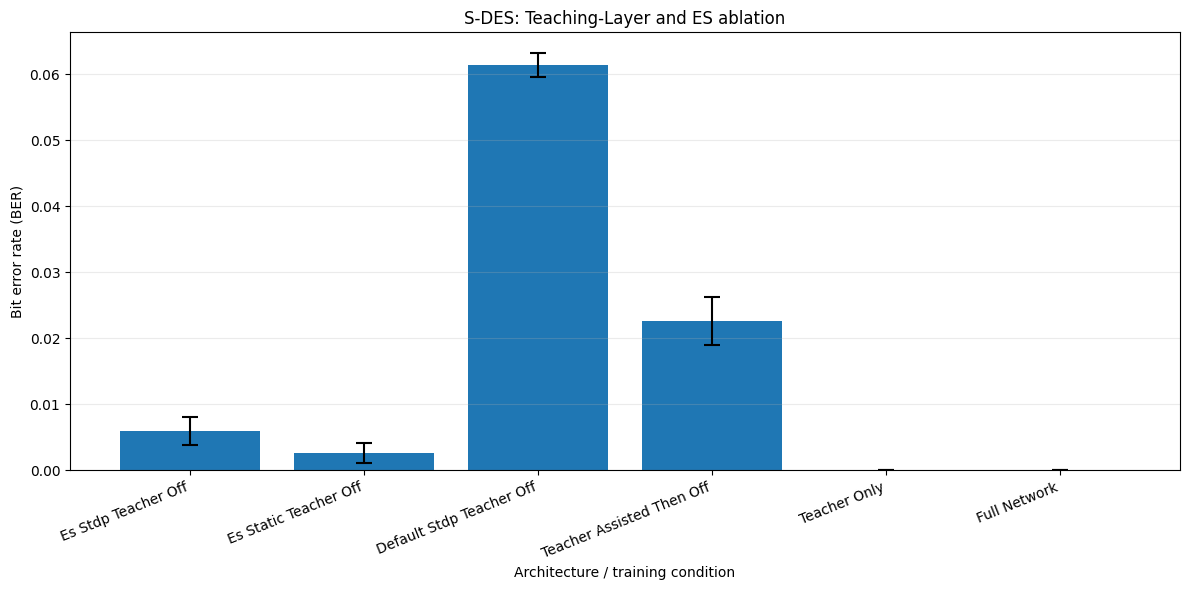

,condition,mean,std,n
2,es_stdp_teacher_off,0.005952,0.002100,10
1,es_static_teacher_off,0.002619,0.001463,10
0,default_stdp_teacher_off,0.061429,0.001792,10
4,teacher_assisted_then_off,0.022619,0.003637,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000000,0.000000,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.0
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,1.0


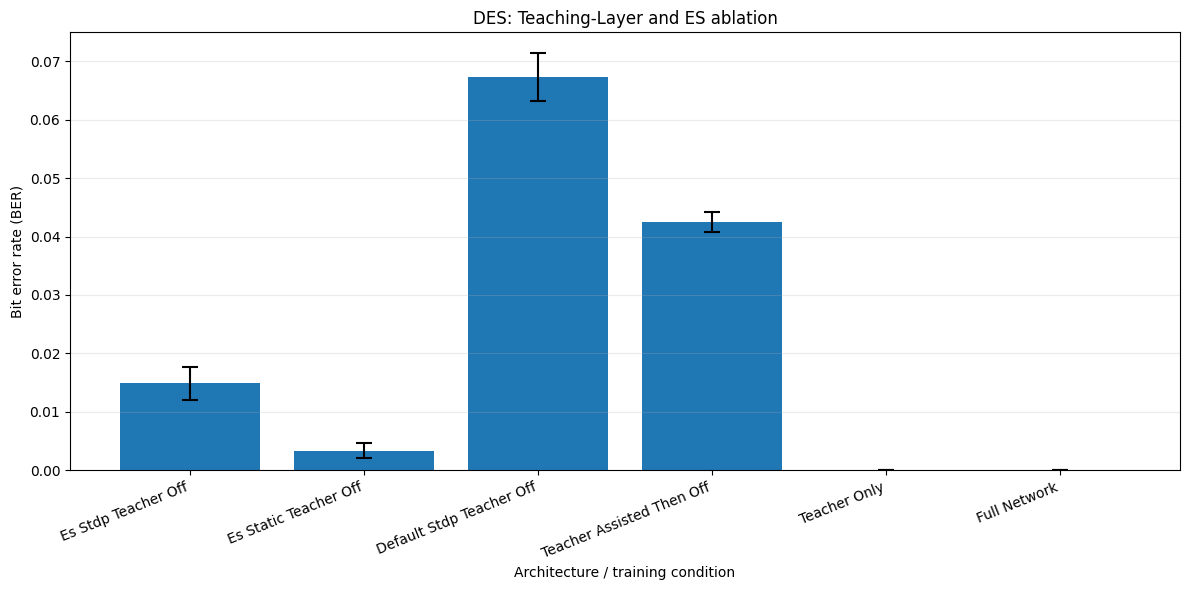

,condition,mean,std,n
2,es_stdp_teacher_off,0.014896,0.002823,10
1,es_static_teacher_off,0.003333,0.001280,10
0,default_stdp_teacher_off,0.067292,0.004085,10
4,teacher_assisted_then_off,0.042500,0.001757,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000000,0.000000,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.0
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,1.0


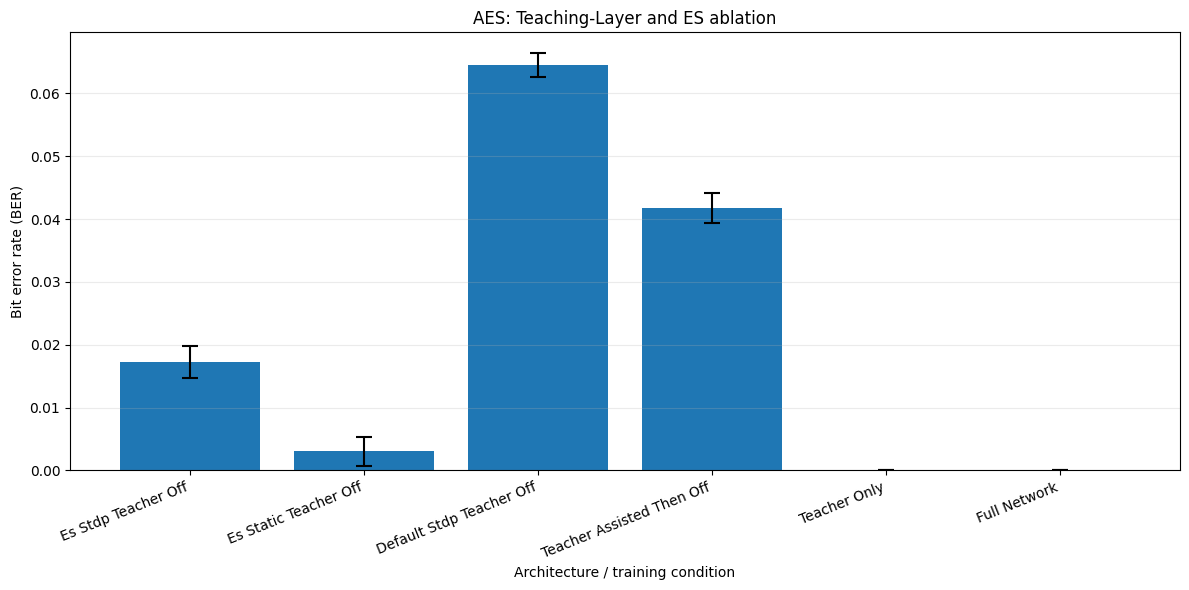

,condition,mean,std,n
2,es_stdp_teacher_off,0.017285,0.002565,10
1,es_static_teacher_off,0.003027,0.002276,10
0,default_stdp_teacher_off,0.064551,0.001867,10
4,teacher_assisted_then_off,0.041797,0.002383,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000000,0.000000,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.0
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,1.0


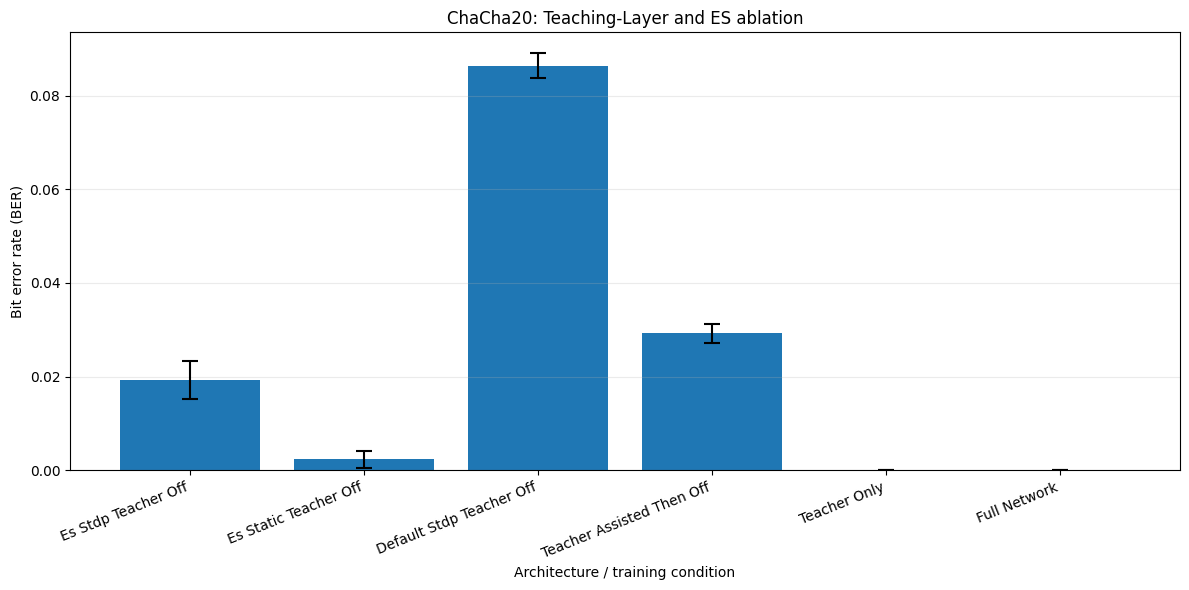

,condition,mean,std,n
2,es_stdp_teacher_off,0.019338,0.004074,10
1,es_static_teacher_off,0.002350,0.001871,10
0,default_stdp_teacher_off,0.086432,0.002639,10
4,teacher_assisted_then_off,0.029274,0.002027,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000000,0.000000,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.2
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,1.0


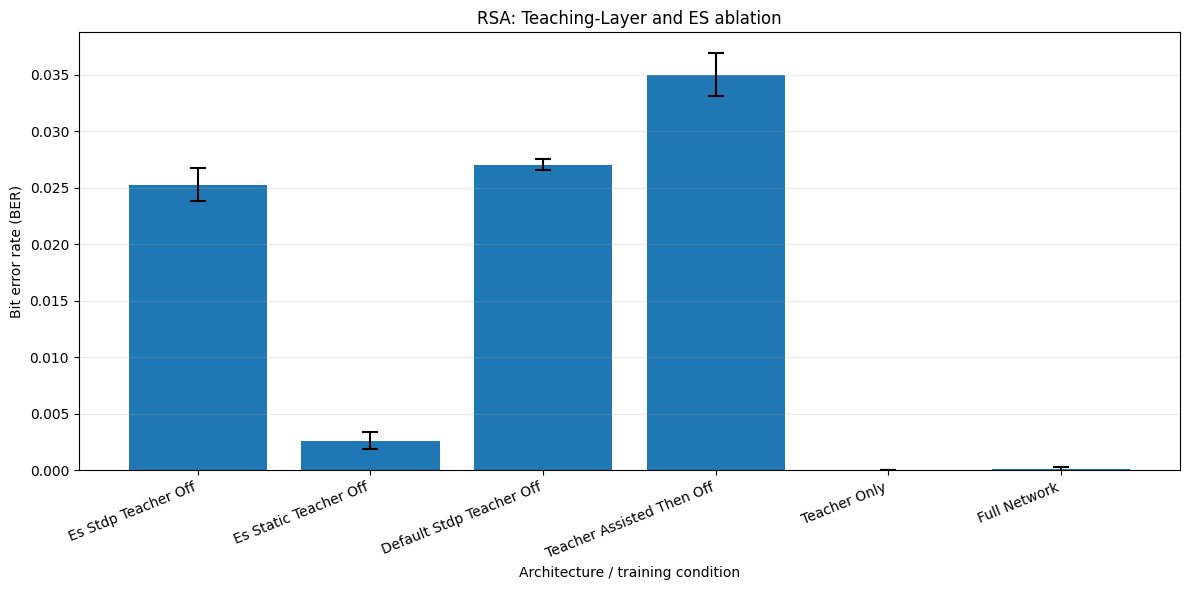

,condition,mean,std,n
2,es_stdp_teacher_off,0.025293,0.001488,10
1,es_static_teacher_off,0.002637,0.000770,10
0,default_stdp_teacher_off,0.027051,0.000472,10
4,teacher_assisted_then_off,0.035010,0.001913,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000098,0.000206,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.0
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,0.8


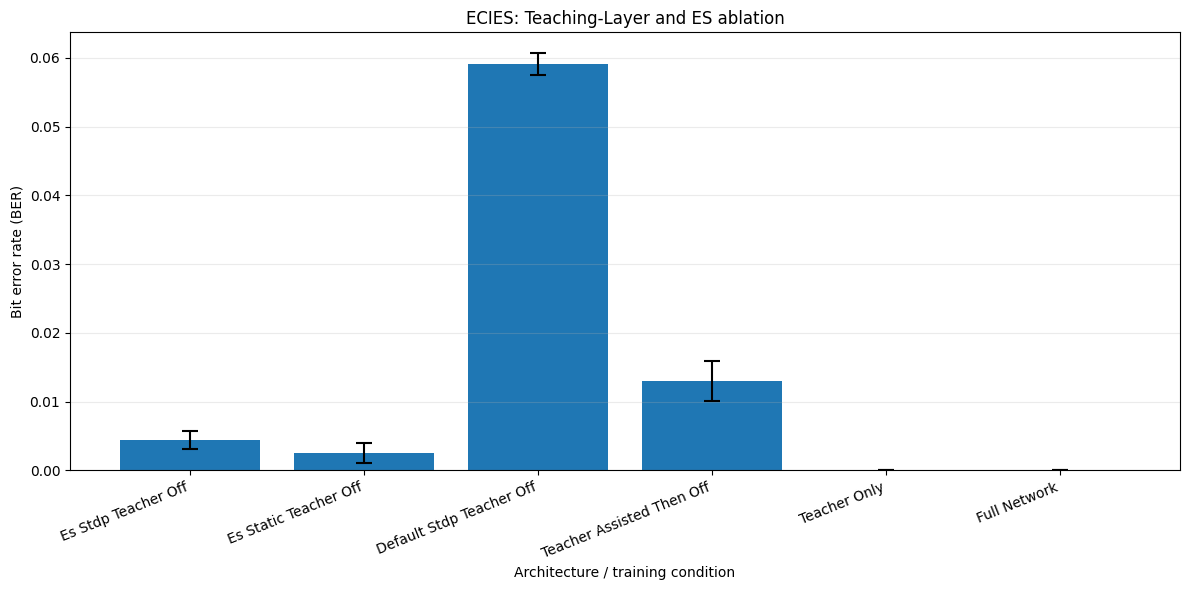

,condition,mean,std,n
2,es_stdp_teacher_off,0.004419,0.001364,10
1,es_static_teacher_off,0.002525,0.001396,10
0,default_stdp_teacher_off,0.059091,0.001608,10
4,teacher_assisted_then_off,0.013005,0.002964,10
5,teacher_only,0.000000,0.000000,10
3,full_network,0.000000,0.000000,10


,exact_ciphertext_recovery_rate
condition,
es_stdp_teacher_off,0.0
es_static_teacher_off,0.0
default_stdp_teacher_off,0.0
teacher_assisted_then_off,0.0
teacher_only,1.0
full_network,1.0


In [15]:
ablation = results[
    results["experiment"]
    == "teaching_ablation"
].copy()

condition_order = [
    "es_stdp_teacher_off",
    "es_static_teacher_off",
    "default_stdp_teacher_off",
    "teacher_assisted_then_off",
    "teacher_only",
    "full_network",
]

for algorithm in CRYPTO_ALGORITHMS:
    subset = ablation[
        ablation["algorithm"]
        == algorithm
    ].copy()

    stats = (
        subset
        .groupby(
            "condition",
            as_index=False,
        )["ber"]
        .agg(
            mean="mean",
            std="std",
            n="count",
        )
    )

    stats["std"] = (
        stats["std"]
        .fillna(0.0)
    )

    stats["condition"] = (
        pd.Categorical(
            stats["condition"],
            categories=(
                condition_order
            ),
            ordered=True,
        )
    )

    stats = (
        stats.sort_values(
            "condition"
        )
    )

    x = np.arange(
        len(stats)
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        x,
        stats["mean"],
        yerr=stats["std"],
        capsize=6,
        error_kw={
            "elinewidth": 1.5,
            "capthick": 1.5,
        },
    )

    plt.xticks(
        x,
        [
            str(v)
            .replace("_", " ")
            .title()
            for v in (
                stats["condition"]
            )
        ],
        rotation=22,
        ha="right",
    )

    plt.xlabel(
        "Architecture / training condition"
    )
    plt.ylabel(
        "Bit error rate (BER)"
    )
    plt.title(
        f"{algorithm}: Teaching-Layer and ES ablation"
    )
    plt.ylim(
        bottom=0
    )
    plt.grid(
        axis="y",
        alpha=0.25,
    )
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "teaching_es_ablation.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()
    display(stats)

    exact = (
        subset
        .groupby(
            "condition"
        )[
            "exact_ciphertext_recovery"
        ]
        .mean()
        .reindex(
            condition_order
        )
        .rename(
            "exact_ciphertext_recovery_rate"
        )
        .to_frame()
    )

    display(exact)


## Actual triplet-STDP trace without a Teaching Layer

The principal STDP figure now uses `es_no_teacher_stdp`: the ES-derived initial operating point is followed by triplet-STDP while the Teaching Layer is absent. This provides a direct experimental trace for the same pathway used in primary teacher-off inference.

If the measured weight evolution is negligible or degrades held-out recovery, the manuscript should not claim that STDP is the mechanism responsible for successful transport.


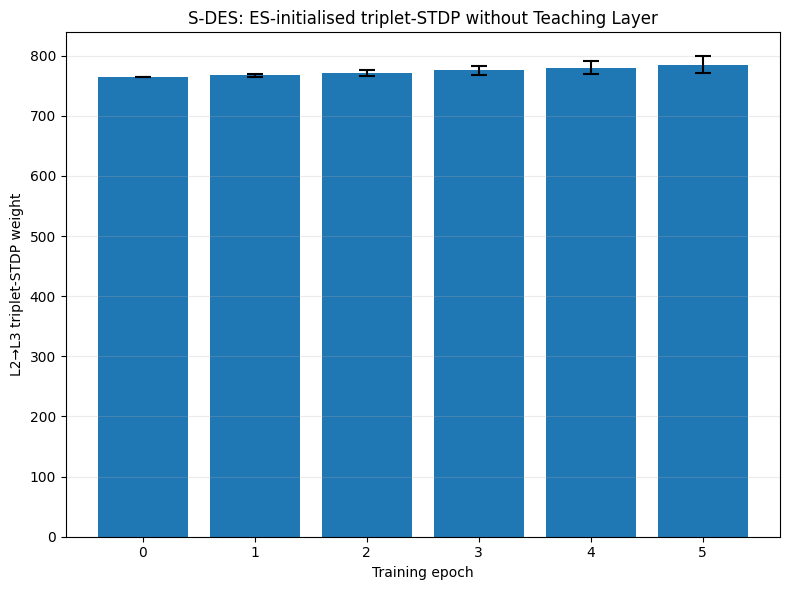

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,767.401174,2.436026,320
2,2,771.511583,5.129648,320
3,3,775.749191,7.935205,320
4,4,780.261547,10.950988,320
5,5,784.859690,14.041980,320


S-DES: mean no-teacher STDP weight change = 21.113060


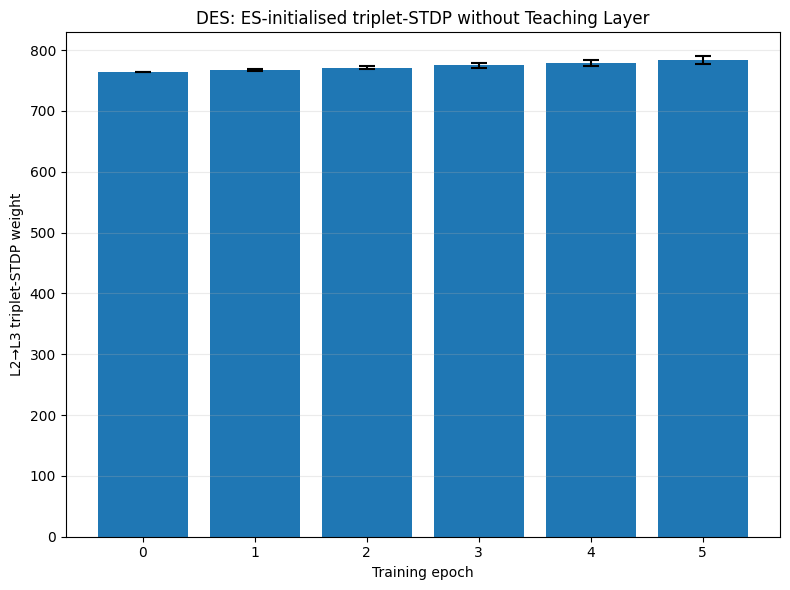

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,767.158398,1.112360,320
2,2,770.953362,2.419152,320
3,3,774.851000,3.764941,320
4,4,778.825114,5.201878,320
5,5,782.903517,6.681615,320


DES: mean no-teacher STDP weight change = 19.156887


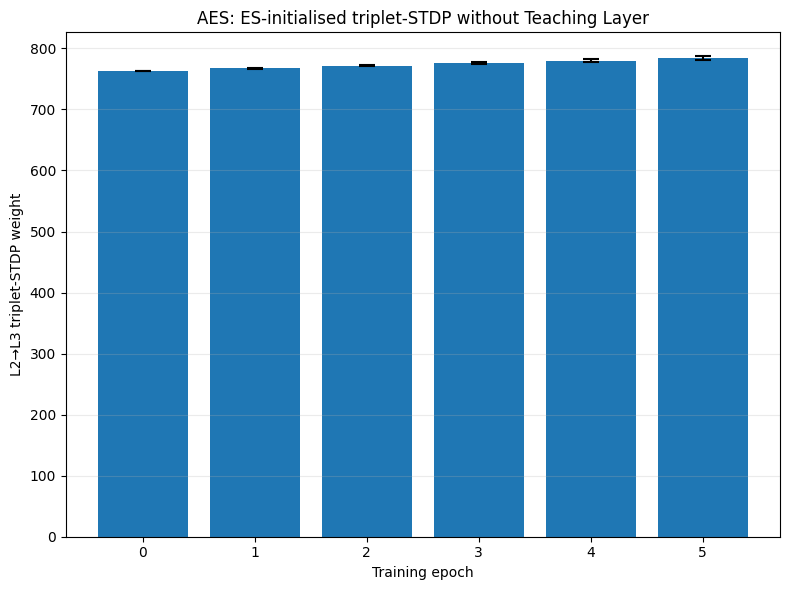

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,767.349030,0.431232,320
2,2,771.398109,0.958760,320
3,3,775.523248,1.494578,320
4,4,779.747440,2.143399,320
5,5,784.129853,2.808788,320


AES: mean no-teacher STDP weight change = 20.383224


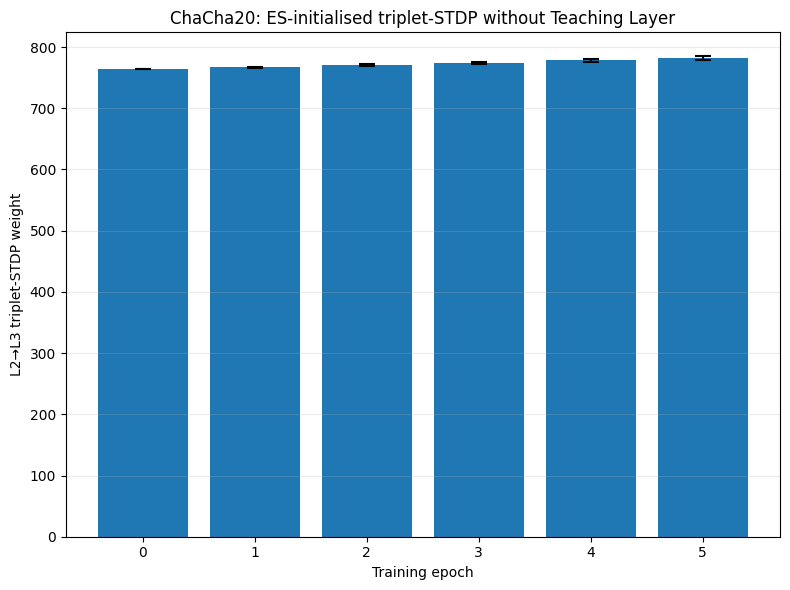

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,767.038350,0.443090,320
2,2,770.715123,0.972937,320
3,3,774.447512,1.499244,320
4,4,778.218040,2.062098,320
5,5,782.128889,2.712492,320


ChaCha20: mean no-teacher STDP weight change = 18.382259


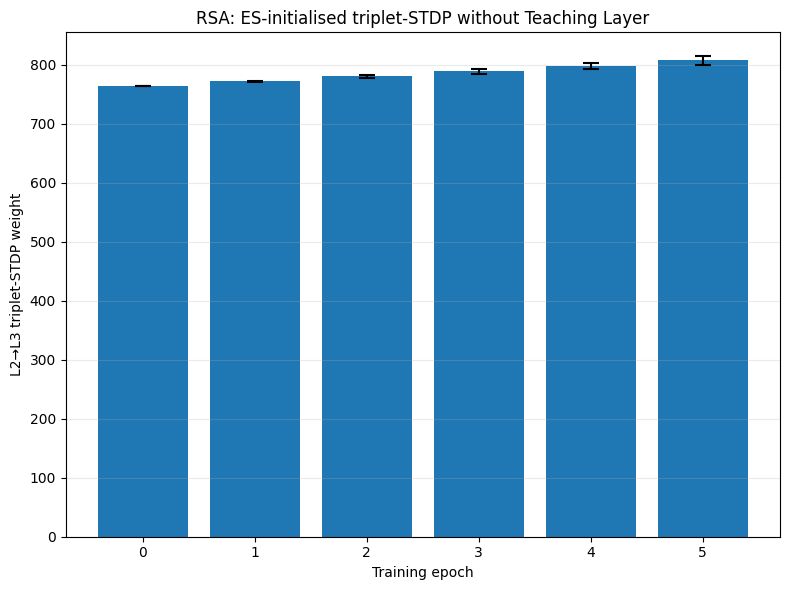

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,771.445835,1.173601,320
2,2,779.737103,2.435014,320
3,3,788.501782,3.848273,320
4,4,797.510525,5.259870,320
5,5,806.874468,6.997199,320


RSA: mean no-teacher STDP weight change = 43.127838


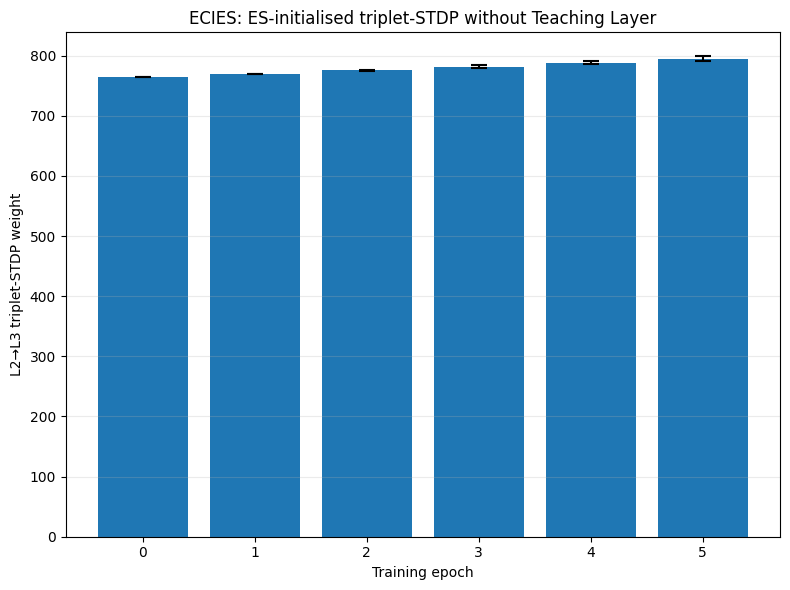

,epoch,mean,std,n
0,0,763.746630,0.000000,320
1,1,769.385450,0.603584,320
2,2,775.514308,1.295292,320
3,3,781.819311,2.077647,320
4,4,788.456869,2.844599,320
5,5,795.215206,3.598281,320


ECIES: mean no-teacher STDP weight change = 31.468576


In [16]:
primary_trace = weight_trace[
    weight_trace[
        "training_condition"
    ] == "es_no_teacher_stdp"
].copy()

for algorithm in CRYPTO_ALGORITHMS:
    subset = primary_trace[
        primary_trace[
            "algorithm"
        ] == algorithm
    ]

    stats = (
        subset
        .groupby(
            "epoch",
            as_index=False,
        )["weight"]
        .agg(
            mean="mean",
            std="std",
            n="count",
        )
    )

    stats["std"] = (
        stats["std"]
        .fillna(0.0)
    )

    x = np.arange(
        len(stats)
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.bar(
        x,
        stats["mean"],
        yerr=stats["std"],
        capsize=6,
        error_kw={
            "elinewidth": 1.5,
            "capthick": 1.5,
        },
    )

    plt.xticks(
        x,
        [
            str(int(v))
            for v in (
                stats["epoch"]
            )
        ],
    )

    plt.xlabel(
        "Training epoch"
    )
    plt.ylabel(
        "L2→L3 triplet-STDP weight"
    )
    plt.title(
        f"{algorithm}: ES-initialised triplet-STDP without Teaching Layer"
    )
    plt.grid(
        axis="y",
        alpha=0.25,
    )
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "es_no_teacher_"
                "stdp_trace.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()
    display(stats)

    if not stats.empty:
        initial_mean = float(
            stats.loc[
                stats["epoch"] == 0,
                "mean",
            ].iloc[0]
        )

        final_mean = float(
            stats.loc[
                stats["epoch"]
                == stats["epoch"].max(),
                "mean",
            ].iloc[0]
        )

        print(
            f"{algorithm}: "
            "mean no-teacher STDP "
            "weight change = "
            f"{final_mean - initial_mean:.6f}"
        )


Full quantitative noise campaign

The earlier one-payload sweep is replaced with a dedicated hierarchical,
paired repeated-measures experiment using the primary **CMA-ES + triplet-STDP,
teacher-free** architecture.

The design uses three trained model instances, four mutually disjoint held-out
dataset payloads and two independent external noise realisations. This gives
24 paired observations for every algorithm/noise condition. Each experimental
unit is evaluated at zero noise and then at 5, 10, 25, 50 and 100 Hz.

Three perturbations are reported: excitatory Poisson background, inhibitory
Poisson background, and a balanced E/I Poisson condition in which the requested
total rate is split equally between independent excitatory and inhibitory
streams. Noise is injected into Layer 2, the principal hidden processing layer.

The synaptic noise amplitude is set to 10% of the L1→L2 signal synaptic weight,
so the perturbation is expressed relative to the signal rather than as an
arbitrary absolute current. BER, ciphertext byte accuracy, exact ciphertext
recovery, decryption success, exact plaintext recovery, Victor–Purpura distance,
van Rossum distance and decoder ties are recorded.

The analysis uses bootstrap confidence intervals, Wilson intervals for exact
recovery proportions, unit-matched Wilcoxon tests against the zero-noise
baseline with Holm correction, and repeated-measures Friedman tests across
noise rates.


In [17]:
# =============================================================================
# FULL NOISE-SENSITIVITY CAMPAIGN
# RUN / RESUME + STATISTICAL ANALYSIS
# =============================================================================

# Set True only when trial-level files from the current six-algorithm
# configuration already exist. The expected evaluation count is computed
# dynamically from CRYPTO_ALGORITHMS and the hierarchical design.
REUSE_SAVED_FULL_NOISE_RESULTS = True


def iter_full_noise_settings():
    """
    Shared zero-noise reference followed by all positive-rate conditions.
    """
    yield "none", 0.0

    for noise_type in FULL_NOISE_TYPES:
        for rate_hz in FULL_NOISE_RATES_HZ:
            if rate_hz > 0:
                yield (
                    noise_type,
                    float(rate_hz),
                )


def full_noise_expected_evaluations():
    """
    Total number of NEST evaluations in the complete noise experiment.
    """
    n_settings = len(
        list(
            iter_full_noise_settings()
        )
    )

    return (
        len(CRYPTO_ALGORITHMS)
        * min(
            FULL_NOISE_MODEL_TRIALS,
            N_TRIALS,
        )
        * len(
            FULL_NOISE_PAYLOADS
        )
        * FULL_NOISE_REPLICATES
        * n_settings
    )


def run_full_noise_campaign(
    weight_cache,
    *,
    show_progress=True,
):
    """
    Run the hierarchical paired noise experiment.

    Statistical unit:
        trained model
        × held-out payload
        × independent noise replicate

    All noise conditions belonging to one statistical unit use exactly the
    same deterministic NEST network seed. Only the externally generated noise
    schedule changes.
    """

    if not RUN_FULL_NOISE_CAMPAIGN:
        return (
            pd.DataFrame(),
            pd.DataFrame(),
        )

    rows = []
    distance_frames = []

    n_model_trials = min(
        FULL_NOISE_MODEL_TRIALS,
        N_TRIALS,
    )

    progress = tqdm(
        total=(
            full_noise_expected_evaluations()
        ),
        desc=(
            "Full noise-sensitivity campaign"
        ),
        unit="eval",
        dynamic_ncols=True,
        disable=(
            not show_progress
        ),
        leave=True,
    )

    try:

        for algorithm in CRYPTO_ALGORITHMS:

            context = (
                CRYPTO_CONTEXTS[
                    algorithm
                ]
            )

            # -------------------------------------------------------------
            # Encrypt each held-out payload once.
            #
            # Every noise condition is therefore applied to exactly the
            # same ciphertext for that payload.
            # -------------------------------------------------------------
            payload_ciphertexts = {}

            for payload in FULL_NOISE_PAYLOADS:

                payload_id = int(
                    payload[
                        "payload_id"
                    ]
                )

                plaintext = (
                    payload[
                        "plaintext"
                    ]
                )

                payload_ciphertexts[
                    payload_id
                ] = context.encrypt(
                    plaintext,
                    token=(
                        f"full-noise-"
                        f"{algorithm}-"
                        f"payload-{payload_id}"
                    ),
                )

            # -------------------------------------------------------------
            # Independent trained-model instances
            # -------------------------------------------------------------
            for model_trial in range(
                n_model_trials
            ):

                trained_weights = (
                    weight_cache[
                        (
                            algorithm,
                            model_trial,
                            "primary",
                        )
                    ]
                )

                # ---------------------------------------------------------
                # Mutually disjoint held-out payloads
                # ---------------------------------------------------------
                for payload in FULL_NOISE_PAYLOADS:

                    payload_id = int(
                        payload[
                            "payload_id"
                        ]
                    )

                    plaintext = (
                        payload[
                            "plaintext"
                        ]
                    )

                    ciphertext = (
                        payload_ciphertexts[
                            payload_id
                        ]
                    )

                    eval_duration = (
                        total_presentation_duration_ms(
                            len(
                                ciphertext
                            ),
                            1,
                        )
                    )

                    # -----------------------------------------------------
                    # Independent noise realisations
                    # -----------------------------------------------------
                    for noise_replicate in range(
                        FULL_NOISE_REPLICATES
                    ):

                        # Same network seed across all noise conditions in
                        # this statistical unit.
                        network_seed = stable_seed(
                            "full-noise-network",
                            algorithm,
                            model_trial,
                            payload_id,
                            noise_replicate,
                        )

                        unit_id = (
                            f"{algorithm}|"
                            f"m{model_trial}|"
                            f"p{payload_id}|"
                            f"r{noise_replicate}"
                        )

                        # -------------------------------------------------
                        # Zero noise + complete positive-rate sweep
                        # -------------------------------------------------
                        for (
                            noise_type,
                            noise_rate_hz,
                        ) in (
                            iter_full_noise_settings()
                        ):

                            if show_progress:

                                progress.set_postfix(
                                    algorithm=(
                                        algorithm
                                    ),
                                    model=(
                                        model_trial
                                    ),
                                    payload=(
                                        payload_id
                                    ),
                                    replicate=(
                                        noise_replicate
                                    ),
                                    noise=(
                                        f"{noise_type}@"
                                        f"{noise_rate_hz:g}Hz"
                                    ),
                                    refresh=False,
                                )

                            noise_seed = stable_seed(
                                "full-noise-schedule",
                                algorithm,
                                model_trial,
                                payload_id,
                                noise_replicate,
                                noise_type,
                                noise_rate_hz,
                            )

                            schedule = (
                                make_noise_schedule(
                                    n_neurons=(
                                        NUM_LAYER2
                                    ),
                                    noise_type=(
                                        noise_type
                                    ),
                                    rate_hz=(
                                        noise_rate_hz
                                    ),
                                    duration_ms=(
                                        eval_duration
                                    ),
                                    seed=(
                                        noise_seed
                                    ),
                                )
                            )

                            (
                                row,
                                distances,
                            ) = evaluate_condition(
                                algorithm=(
                                    algorithm
                                ),
                                experiment=(
                                    "full_noise_campaign"
                                ),
                                condition=(
                                    "es_stdp_teacher_off"
                                ),
                                trial=(
                                    model_trial
                                ),
                                ciphertext=(
                                    ciphertext
                                ),
                                plaintext=(
                                    plaintext
                                ),
                                decryptor=(
                                    context.decrypt
                                ),
                                trained_weights=(
                                    trained_weights
                                ),
                                teacher_weight=0.0,
                                network_seed=(
                                    network_seed
                                ),
                                noise_schedule=(
                                    schedule
                                ),
                                noise_type=(
                                    noise_type
                                ),
                                noise_rate_hz=(
                                    noise_rate_hz
                                ),
                                transport_params=(
                                    ES_BEST_PARAMS
                                ),
                                parameter_source=(
                                    "ES+STDP teacher-free"
                                ),
                            )

                            noise_weights = (
                                noise_synaptic_weights(
                                    ES_BEST_PARAMS
                                )
                            )

                            row.update({
                                "unit_id": (
                                    unit_id
                                ),
                                "model_trial": int(
                                    model_trial
                                ),
                                "payload_id": int(
                                    payload_id
                                ),
                                "noise_replicate": int(
                                    noise_replicate
                                ),
                                "noise_seed": int(
                                    noise_seed
                                ),
                                "plaintext_bytes": len(
                                    plaintext
                                ),
                                "noise_exc_weight": float(
                                    noise_weights[
                                        "exc"
                                    ]
                                ),
                                "noise_inh_weight": float(
                                    noise_weights[
                                        "inh"
                                    ]
                                ),
                                "noise_weight_fraction_of_l1_l2": float(
                                    NOISE_SYNAPTIC_WEIGHT_FRACTION
                                ),
                            })

                            rows.append(
                                row
                            )

                            # -------------------------------------------------
                            # Per-rail spike-distance data
                            # -------------------------------------------------
                            distances = (
                                distances.copy()
                            )

                            distances[
                                "unit_id"
                            ] = unit_id

                            distances[
                                "model_trial"
                            ] = model_trial

                            distances[
                                "payload_id"
                            ] = payload_id

                            distances[
                                "noise_replicate"
                            ] = noise_replicate

                            distances[
                                "noise_seed"
                            ] = noise_seed

                            distances[
                                "noise_type"
                            ] = noise_type

                            distances[
                                "noise_rate_hz"
                            ] = noise_rate_hz

                            distance_frames.append(
                                distances
                            )

                            if show_progress:
                                progress.update(
                                    1
                                )

    finally:

        progress.close()

    trial_df = pd.DataFrame(
        rows
    )

    spike_df = (
        pd.concat(
            distance_frames,
            ignore_index=True,
        )
        if distance_frames
        else pd.DataFrame()
    )

    return (
        trial_df,
        spike_df,
    )


# =============================================================================
# DESCRIPTIVE STATISTICS
# =============================================================================

def summarise_full_noise(
    df,
):
    """
    Create publication-ready summaries and confidence intervals.
    """

    rows = []

    group_columns = [
        "algorithm",
        "noise_type",
        "noise_rate_hz",
    ]

    for key, group in df.groupby(
        group_columns,
        dropna=False,
    ):

        (
            algorithm,
            noise_type,
            noise_rate_hz,
        ) = key

        row = {
            "algorithm": (
                algorithm
            ),
            "noise_type": (
                noise_type
            ),
            "noise_rate_hz": float(
                noise_rate_hz
            ),
            "n_observations": int(
                len(group)
            ),
            "n_payloads": int(
                group[
                    "payload_id"
                ].nunique()
            ),
            "n_models": int(
                group[
                    "model_trial"
                ].nunique()
            ),
            "n_noise_replicates": int(
                group[
                    "noise_replicate"
                ].nunique()
            ),
        }

        # -------------------------------------------------------------
        # Continuous metrics
        # -------------------------------------------------------------
        for metric in (
            "ber",
            "ciphertext_byte_accuracy",
            "decoder_tie_fraction",
            "victor_purpura_mean",
            "van_rossum_mean",
        ):

            values = (
                pd.to_numeric(
                    group[
                        metric
                    ],
                    errors="coerce",
                )
                .dropna()
                .to_numpy(
                    dtype=float
                )
            )

            row[
                f"{metric}_mean"
            ] = (
                float(
                    np.mean(
                        values
                    )
                )
                if len(values)
                else np.nan
            )

            row[
                f"{metric}_std"
            ] = (
                float(
                    np.std(
                        values,
                        ddof=1,
                    )
                )
                if len(values) > 1
                else 0.0
            )

            (
                ci_low,
                ci_high,
            ) = bootstrap_mean_ci(
                values,
                seed=stable_seed(
                    "full-noise-bootstrap",
                    algorithm,
                    noise_type,
                    noise_rate_hz,
                    metric,
                ),
                n_bootstrap=(
                    FULL_NOISE_BOOTSTRAP
                ),
            )

            row[
                f"{metric}_ci95_low"
            ] = ci_low

            row[
                f"{metric}_ci95_high"
            ] = ci_high

        # -------------------------------------------------------------
        # Binary recovery outcomes
        # -------------------------------------------------------------
        for metric in (
            "exact_ciphertext_recovery",
            "decryption_success",
            "exact_plaintext_recovery",
        ):

            values = (
                group[
                    metric
                ]
                .astype(bool)
                .astype(int)
            )

            successes = int(
                values.sum()
            )

            n = int(
                len(values)
            )

            row[
                f"{metric}_rate"
            ] = (
                successes / n
                if n
                else np.nan
            )

            (
                ci_low,
                ci_high,
            ) = wilson_interval(
                successes,
                n,
            )

            row[
                f"{metric}_wilson95_low"
            ] = ci_low

            row[
                f"{metric}_wilson95_high"
            ] = ci_high

        rows.append(
            row
        )

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            group_columns
        )
        .reset_index(
            drop=True
        )
    )


# =============================================================================
# PAIRED WILCOXON TESTS
# =============================================================================

def full_noise_paired_wilcoxon(
    df,
):
    """
    Compare each noisy BER observation to the zero-noise BER belonging to the
    same trained model × payload × noise-replicate statistical unit.
    """

    baseline = (
        df[
            (
                df[
                    "noise_type"
                ] == "none"
            )
            & (
                df[
                    "noise_rate_hz"
                ] == 0.0
            )
        ][
            [
                "algorithm",
                "unit_id",
                "ber",
            ]
        ]
        .rename(
            columns={
                "ber": (
                    "baseline_ber"
                )
            }
        )
    )

    rows = []

    noisy = df[
        df[
            "noise_type"
        ] != "none"
    ].copy()

    for key, group in noisy.groupby(
        [
            "algorithm",
            "noise_type",
            "noise_rate_hz",
        ]
    ):

        (
            algorithm,
            noise_type,
            noise_rate_hz,
        ) = key

        paired = (
            group[
                [
                    "unit_id",
                    "ber",
                ]
            ]
            .merge(
                baseline[
                    baseline[
                        "algorithm"
                    ] == algorithm
                ][
                    [
                        "unit_id",
                        "baseline_ber",
                    ]
                ],
                on="unit_id",
                how="inner",
                validate=(
                    "one_to_one"
                ),
            )
        )

        if paired.empty:
            continue

        delta = (
            paired[
                "ber"
            ]
            - paired[
                "baseline_ber"
            ]
        )

        if np.allclose(
            delta.to_numpy(
                dtype=float
            ),
            0.0,
        ):

            statistic = 0.0
            p_value = 1.0

        else:

            test = wilcoxon(
                paired[
                    "ber"
                ],
                paired[
                    "baseline_ber"
                ],
                zero_method=(
                    "wilcox"
                ),
                alternative=(
                    "two-sided"
                ),
            )

            statistic = float(
                test.statistic
            )

            p_value = float(
                test.pvalue
            )

        rows.append({
            "algorithm": (
                algorithm
            ),
            "noise_type": (
                noise_type
            ),
            "noise_rate_hz": float(
                noise_rate_hz
            ),
            "n_paired_units": int(
                len(paired)
            ),
            "baseline_ber_mean": float(
                paired[
                    "baseline_ber"
                ].mean()
            ),
            "noise_ber_mean": float(
                paired[
                    "ber"
                ].mean()
            ),
            "mean_delta_ber": float(
                delta.mean()
            ),
            "median_delta_ber": float(
                delta.median()
            ),
            "wilcoxon_statistic": (
                statistic
            ),
            "p_value": (
                p_value
            ),
        })

    out = pd.DataFrame(
        rows
    )

    if out.empty:
        return out

    # -----------------------------------------------------------------
    # Holm correction within each cryptographic algorithm
    # -----------------------------------------------------------------
    out[
        "p_holm"
    ] = np.nan

    for (
        algorithm,
        indices,
    ) in (
        out.groupby(
            "algorithm"
        ).groups.items()
    ):

        out.loc[
            indices,
            "p_holm",
        ] = holm_adjust(
            out.loc[
                indices,
                "p_value",
            ].to_numpy()
        )

    out[
        "significant_holm_0_05"
    ] = (
        out[
            "p_holm"
        ] < 0.05
    )

    return (
        out.sort_values(
            [
                "algorithm",
                "noise_type",
                "noise_rate_hz",
            ]
        )
        .reset_index(
            drop=True
        )
    )


# =============================================================================
# REPEATED-MEASURES FRIEDMAN TESTS
# =============================================================================

def full_noise_friedman_tests(
    df,
):
    """
    Test whether BER changes systematically across:
        0, 5, 10, 25, 50 and 100 Hz
    for each algorithm/noise-type combination.
    """

    rows = []

    baseline = df[
        (
            df[
                "noise_type"
            ] == "none"
        )
        & (
            df[
                "noise_rate_hz"
            ] == 0.0
        )
    ][
        [
            "algorithm",
            "unit_id",
            "ber",
        ]
    ].copy()

    rates = sorted(
        float(x)
        for x in (
            FULL_NOISE_RATES_HZ
        )
    )

    for algorithm in CRYPTO_ALGORITHMS:

        for noise_type in FULL_NOISE_TYPES:

            noisy = df[
                (
                    df[
                        "algorithm"
                    ] == algorithm
                )
                & (
                    df[
                        "noise_type"
                    ] == noise_type
                )
            ][
                [
                    "unit_id",
                    "noise_rate_hz",
                    "ber",
                ]
            ].copy()

            zero = baseline[
                baseline[
                    "algorithm"
                ] == algorithm
            ][
                [
                    "unit_id",
                    "ber",
                ]
            ].copy()

            zero[
                "noise_rate_hz"
            ] = 0.0

            combined = pd.concat(
                [
                    zero[
                        [
                            "unit_id",
                            "noise_rate_hz",
                            "ber",
                        ]
                    ],
                    noisy,
                ],
                ignore_index=True,
            )

            pivot = (
                combined
                .pivot_table(
                    index=(
                        "unit_id"
                    ),
                    columns=(
                        "noise_rate_hz"
                    ),
                    values="ber",
                    aggfunc="first",
                )
                .dropna()
            )

            if not all(
                rate
                in pivot.columns
                for rate in rates
            ):
                continue

            arrays = [
                pivot[
                    rate
                ].to_numpy(
                    dtype=float
                )
                for rate in rates
            ]

            if all(
                np.allclose(
                    arrays[0],
                    arr,
                )
                for arr in (
                    arrays[1:]
                )
            ):

                statistic = 0.0
                p_value = 1.0

            else:

                test = (
                    friedmanchisquare(
                        *arrays
                    )
                )

                statistic = float(
                    test.statistic
                )

                p_value = float(
                    test.pvalue
                )

            rows.append({
                "algorithm": (
                    algorithm
                ),
                "noise_type": (
                    noise_type
                ),
                "n_complete_units": int(
                    len(pivot)
                ),
                "rates_hz": ",".join(
                    f"{rate:g}"
                    for rate in rates
                ),
                "friedman_statistic": (
                    statistic
                ),
                "p_value": (
                    p_value
                ),
            })

    return pd.DataFrame(
        rows
    )


# =============================================================================
# ROBUSTNESS VALIDITY GATE
# =============================================================================

def full_noise_claim_gate_table(
    summary_df,
):
    """
    Distinguish:
        experiment completed
    from:
        robust lossless transport demonstrated.

    Robustness is considered scientifically interpretable only if the
    teacher-free zero-noise baseline already passes the predeclared BER and
    exact-recovery thresholds.
    """

    rows = []

    for algorithm in CRYPTO_ALGORITHMS:

        baseline = summary_df[
            (
                summary_df[
                    "algorithm"
                ] == algorithm
            )
            & (
                summary_df[
                    "noise_type"
                ] == "none"
            )
            & (
                summary_df[
                    "noise_rate_hz"
                ] == 0.0
            )
        ]

        if baseline.empty:

            rows.append({
                "algorithm": (
                    algorithm
                ),
                "zero_noise_mean_ber": (
                    np.nan
                ),
                "zero_noise_exact_ciphertext_recovery_rate": (
                    np.nan
                ),
                "baseline_meets_exact_recovery_gate": (
                    False
                ),
                "interpretation": (
                    "missing zero-noise baseline"
                ),
            })

            continue

        ber = float(
            baseline[
                "ber_mean"
            ].iloc[0]
        )

        exact = float(
            baseline[
                "exact_ciphertext_recovery_rate"
            ].iloc[0]
        )

        valid = (
            ber
            <= MAX_VALID_ZERO_NOISE_BER
            and exact
            >= MIN_VALID_EXACT_RECOVERY_RATE
        )

        rows.append({
            "algorithm": (
                algorithm
            ),
            "zero_noise_mean_ber": (
                ber
            ),
            "zero_noise_exact_ciphertext_recovery_rate": (
                exact
            ),
            "baseline_meets_exact_recovery_gate": bool(
                valid
            ),
            "interpretation": (
                "zero-noise exact-recovery gate is satisfied"
                if valid
                else (
                    "report noise sensitivity only; "
                    "do not claim robust lossless transport"
                )
            ),
        })

    return pd.DataFrame(
        rows
    )


# =============================================================================
# RUN OR RESUME THE FULL EXPERIMENT
# =============================================================================

trial_file = (
    RESULTS_DIR
    / "full_noise_trials.csv"
)

spike_file = (
    RESULTS_DIR
    / "full_noise_spike_distances.csv"
)


if (
    REUSE_SAVED_FULL_NOISE_RESULTS
    and trial_file.exists()
    and spike_file.exists()
):

    print(
        "Reusing completed full-noise simulations from disk."
    )

    print(
        f"Trial data: {trial_file}"
    )

    print(
        f"Spike-distance data: {spike_file}"
    )

    full_noise_results = pd.read_csv(
        trial_file
    )

    full_noise_spike_distances = pd.read_csv(
        spike_file
    )

else:

    print(
        "Saved full-noise trial files were not found."
    )

    print(
        "Running complete NEST noise campaign..."
    )

    (
        full_noise_results,
        full_noise_spike_distances,
    ) = run_full_noise_campaign(
        weight_cache,
        show_progress=True,
    )

    full_noise_results.to_csv(
        trial_file,
        index=False,
    )

    full_noise_spike_distances.to_csv(
        spike_file,
        index=False,
    )


# =============================================================================
# RECOMPUTE SUMMARY / STATISTICS
#
# These operations are inexpensive and are always recomputed from the raw
# trial-level data.
# =============================================================================

full_noise_summary = (
    summarise_full_noise(
        full_noise_results
    )
)

full_noise_paired = (
    full_noise_paired_wilcoxon(
        full_noise_results
    )
)

full_noise_friedman = (
    full_noise_friedman_tests(
        full_noise_results
    )
)

full_noise_claim_gate = (
    full_noise_claim_gate_table(
        full_noise_summary
    )
)


# =============================================================================
# SAVE ANALYSIS TABLES
# =============================================================================

full_noise_summary.to_csv(
    RESULTS_DIR
    / "full_noise_summary.csv",
    index=False,
)

full_noise_paired.to_csv(
    RESULTS_DIR
    / "full_noise_paired_wilcoxon.csv",
    index=False,
)

full_noise_friedman.to_csv(
    RESULTS_DIR
    / "full_noise_friedman.csv",
    index=False,
)

full_noise_claim_gate.to_csv(
    RESULTS_DIR
    / "full_noise_claim_gate.csv",
    index=False,
)


# =============================================================================
# REPORT
# =============================================================================

print()

print(
    "=" * 72
)

print(
    "FULL NOISE-SENSITIVITY CAMPAIGN"
)

print(
    "=" * 72
)

print(
    "Expected evaluations:",
    full_noise_expected_evaluations(),
)

print(
    "Available evaluations:",
    len(
        full_noise_results
    ),
)

print(
    "Paired observations per noise condition:",
    (
        min(
            FULL_NOISE_MODEL_TRIALS,
            N_TRIALS,
        )
        * len(
            FULL_NOISE_PAYLOADS
        )
        * FULL_NOISE_REPLICATES
    ),
)

print(
    "=" * 72
)


print(
    "\nRobustness validity gate:"
)

display(
    full_noise_claim_gate
)


print(
    "\nNoise summary:"
)

display(
    full_noise_summary
)


print(
    "\nPaired Wilcoxon tests vs zero-noise baseline:"
)

display(
    full_noise_paired
)


print(
    "\nRepeated-measures Friedman tests:"
)

display(
    full_noise_friedman
)


Saved full-noise trial files were not found.
Running complete NEST noise campaign...


Full noise-sensitivity campaign:   0%|          | 0/2304 [00:00<?, ?eval/s]


FULL NOISE-SENSITIVITY CAMPAIGN
Expected evaluations: 2304
Available evaluations: 2304
Paired observations per noise condition: 24

Robustness validity gate:


,algorithm,zero_noise_mean_ber,zero_noise_exact_ciphertext_recovery_rate,baseline_meets_exact_recovery_gate,interpretation
0,S-DES,0.002083,0.0,False,report noise sensitivity only; do not claim ro...
1,DES,0.011719,0.0,False,report noise sensitivity only; do not claim ro...
2,AES,0.023193,0.0,False,report noise sensitivity only; do not claim ro...
3,ChaCha20,0.027511,0.0,False,report noise sensitivity only; do not claim ro...
4,RSA,0.024902,0.0,False,report noise sensitivity only; do not claim ro...
5,ECIES,0.000000,1.0,True,zero-noise exact-recovery gate is satisfied



Noise summary:


,algorithm,noise_type,noise_rate_hz,n_observations,n_payloads,n_models,n_noise_replicates,ber_mean,ber_std,ber_ci95_low,...,van_rossum_mean_ci95_high,exact_ciphertext_recovery_rate,exact_ciphertext_recovery_wilson95_low,exact_ciphertext_recovery_wilson95_high,decryption_success_rate,decryption_success_wilson95_low,decryption_success_wilson95_high,exact_plaintext_recovery_rate,exact_plaintext_recovery_wilson95_low,exact_plaintext_recovery_wilson95_high
0,AES,none,0.0,24,4,3,2,0.023193,0.001296,0.022705,...,6.914939,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976
1,AES,poisson_excitatory,5.0,24,4,3,2,0.020711,0.002701,0.019613,...,6.926815,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976
2,AES,poisson_excitatory,10.0,24,4,3,2,0.018514,0.003289,0.017212,...,6.959049,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976
3,AES,poisson_excitatory,25.0,24,4,3,2,0.024007,0.004423,0.022257,...,7.155445,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976
4,AES,poisson_excitatory,50.0,24,4,3,2,0.057373,0.005711,0.055216,...,7.736481,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976,0.0,1.387779e-17,0.137976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,S-DES,poisson_mixed,5.0,24,4,3,2,0.003621,0.001549,0.003075,...,6.161389,0.0,1.387779e-17,0.137976,1.0,8.620238e-01,1.000000,0.0,1.387779e-17,0.137976
92,S-DES,poisson_mixed,10.0,24,4,3,2,0.004018,0.001949,0.003274,...,6.179294,0.0,1.387779e-17,0.137976,1.0,8.620238e-01,1.000000,0.0,1.387779e-17,0.137976
93,S-DES,poisson_mixed,25.0,24,4,3,2,0.005605,0.002234,0.004762,...,6.235595,0.0,1.387779e-17,0.137976,1.0,8.620238e-01,1.000000,0.0,1.387779e-17,0.137976
94,S-DES,poisson_mixed,50.0,24,4,3,2,0.009821,0.003480,0.008532,...,6.349637,0.0,1.387779e-17,0.137976,1.0,8.620238e-01,1.000000,0.0,1.387779e-17,0.137976



Paired Wilcoxon tests vs zero-noise baseline:


,algorithm,noise_type,noise_rate_hz,n_paired_units,baseline_ber_mean,noise_ber_mean,mean_delta_ber,median_delta_ber,wilcoxon_statistic,p_value,p_holm,significant_holm_0_05
0,AES,poisson_excitatory,5.0,24,0.023193,0.020711,-0.002482,-0.002930,28.5,0.000806,0.005644,True
1,AES,poisson_excitatory,10.0,24,0.023193,0.018514,-0.004679,-0.004395,1.5,0.000032,0.000323,True
2,AES,poisson_excitatory,25.0,24,0.023193,0.024007,0.000814,0.000977,87.5,0.328835,0.657669,False
3,AES,poisson_excitatory,50.0,24,0.023193,0.057373,0.034180,0.032227,0.0,0.000018,0.000266,True
4,AES,poisson_excitatory,100.0,24,0.023193,0.147746,0.124552,0.125000,0.0,0.000018,0.000266,True
...,...,...,...,...,...,...,...,...,...,...,...,...
85,S-DES,poisson_mixed,5.0,24,0.002083,0.003621,0.001538,0.001190,1.5,0.000067,0.000337,True
86,S-DES,poisson_mixed,10.0,24,0.002083,0.004018,0.001935,0.001190,2.0,0.000269,0.000538,True
87,S-DES,poisson_mixed,25.0,24,0.002083,0.005605,0.003522,0.003571,0.0,0.000056,0.000337,True
88,S-DES,poisson_mixed,50.0,24,0.002083,0.009821,0.007738,0.007143,0.0,0.000018,0.000267,True



Repeated-measures Friedman tests:


,algorithm,noise_type,n_complete_units,rates_hz,friedman_statistic,p_value
0,S-DES,poisson_excitatory,24,"0,5,10,25,50,100",116.259036,1.944409e-23
1,S-DES,poisson_inhibitory,24,"0,5,10,25,50,100",103.445122,9.921880e-21
2,S-DES,poisson_mixed,24,"0,5,10,25,50,100",100.452854,4.242351e-20
3,DES,poisson_excitatory,24,"0,5,10,25,50,100",112.081829,1.487419e-22
4,DES,poisson_inhibitory,24,"0,5,10,25,50,100",112.382388,1.284936e-22
5,DES,poisson_mixed,24,"0,5,10,25,50,100",96.280637,3.210059e-19
6,AES,poisson_excitatory,24,"0,5,10,25,50,100",99.675090,6.187745e-20
7,AES,poisson_inhibitory,24,"0,5,10,25,50,100",89.981818,6.778673e-18
8,AES,poisson_mixed,24,"0,5,10,25,50,100",68.808948,1.813036e-13
9,ChaCha20,poisson_excitatory,24,"0,5,10,25,50,100",106.048193,2.800452e-21


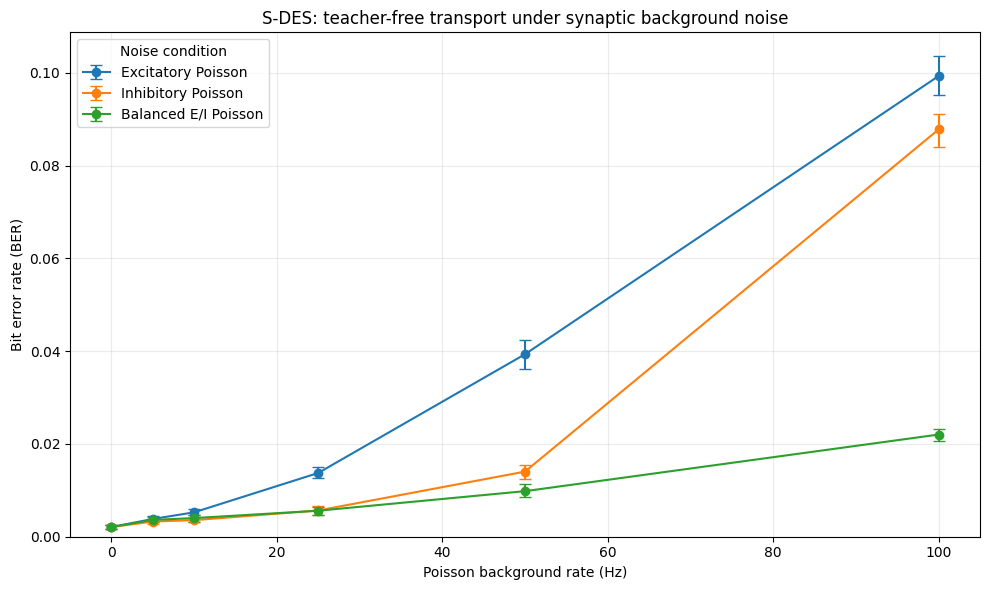

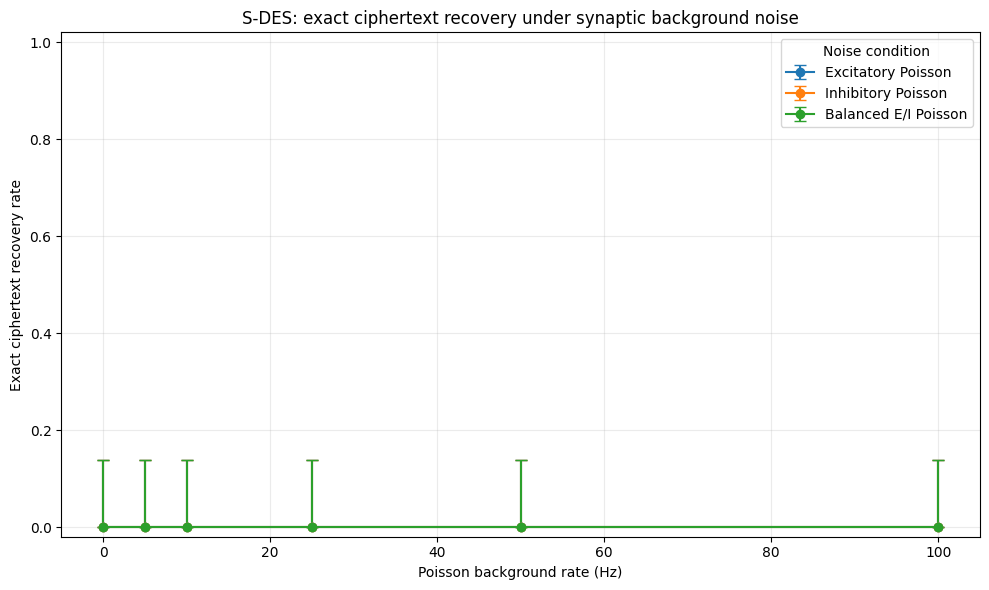

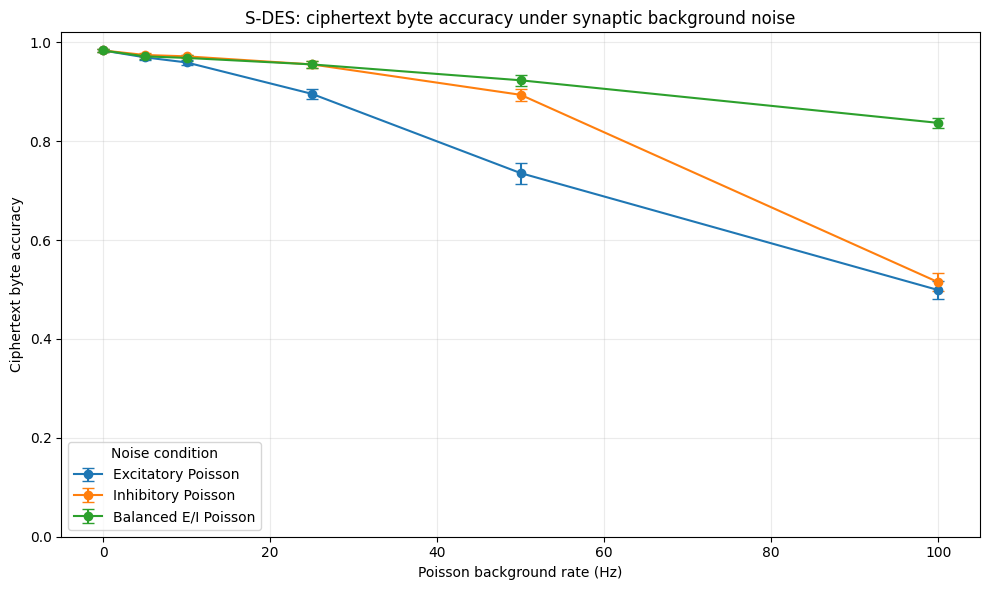

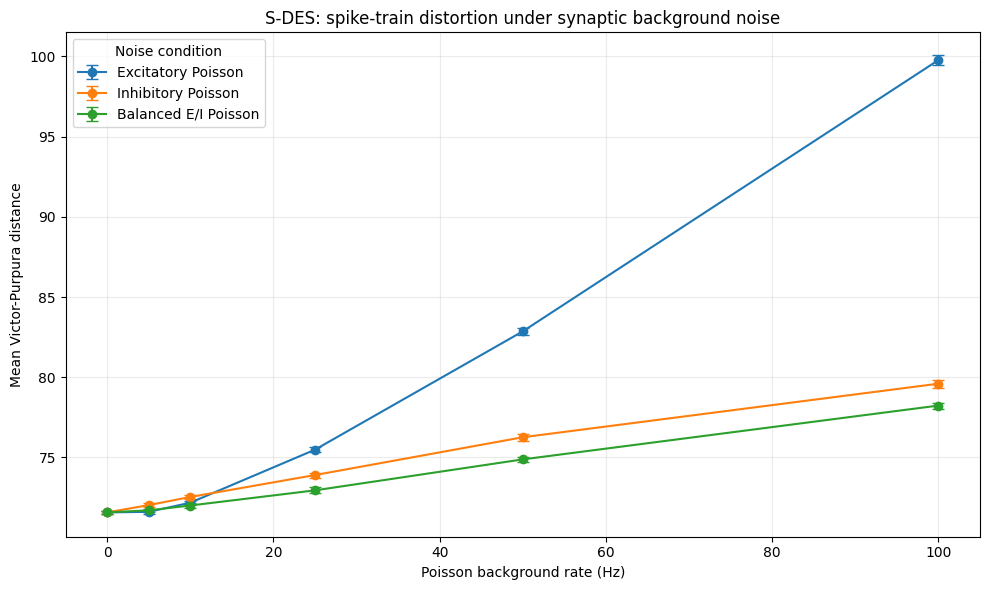

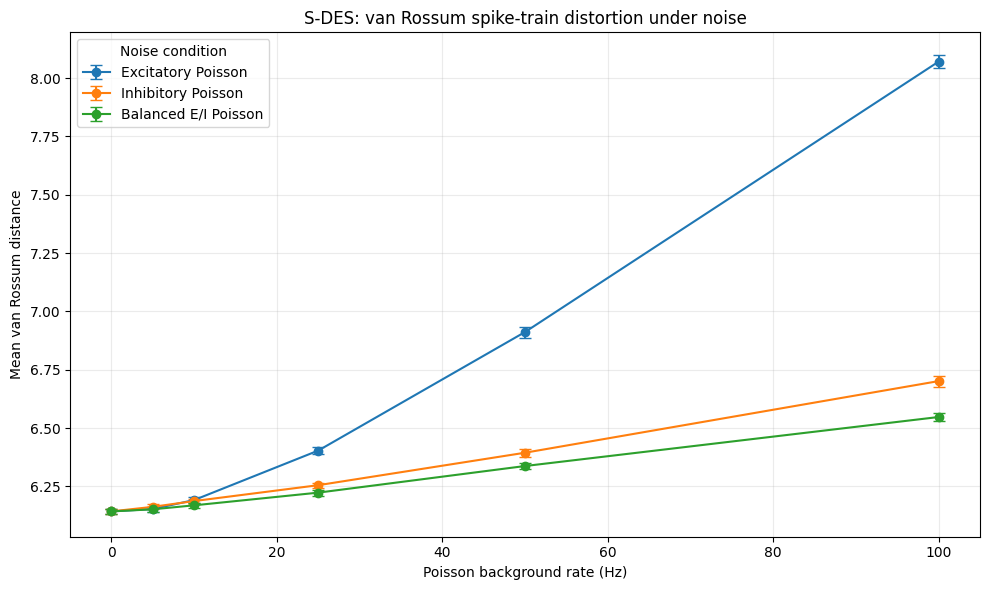

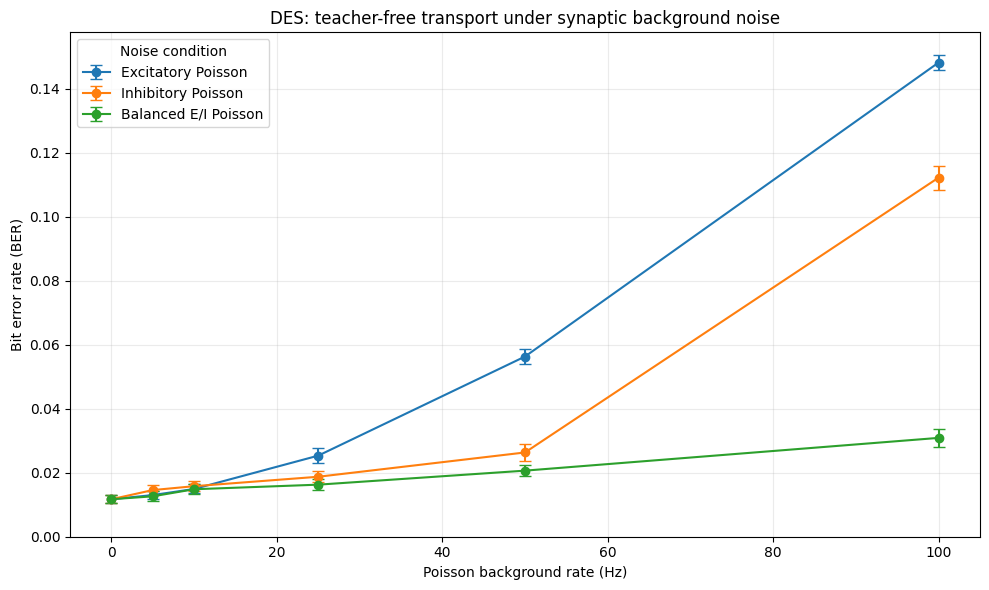

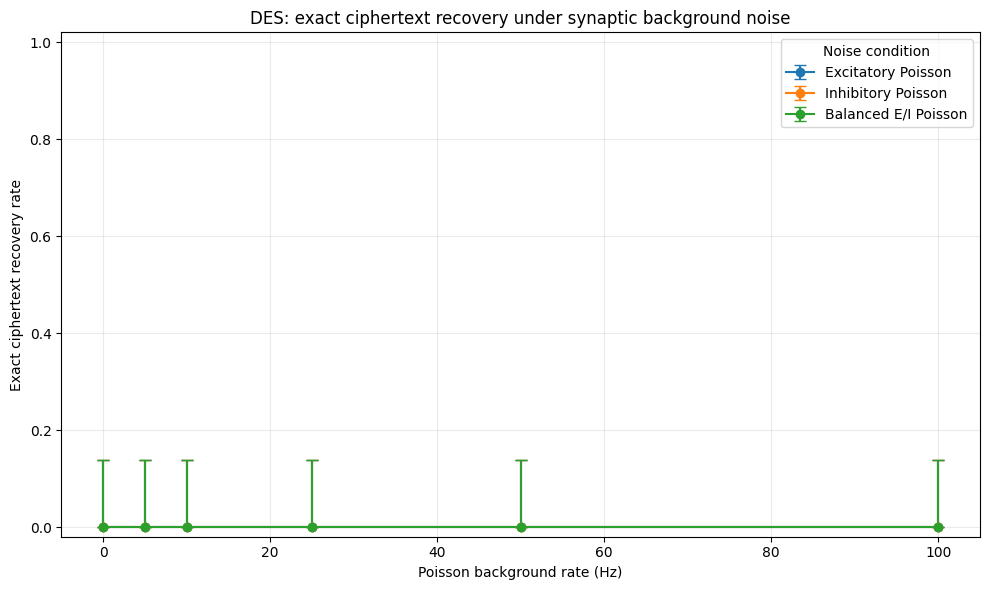

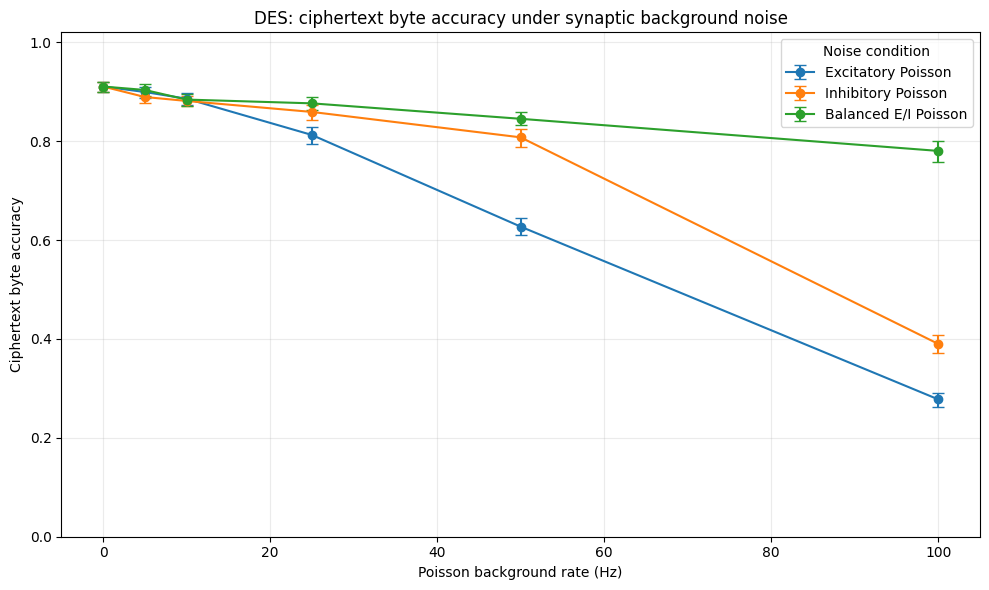

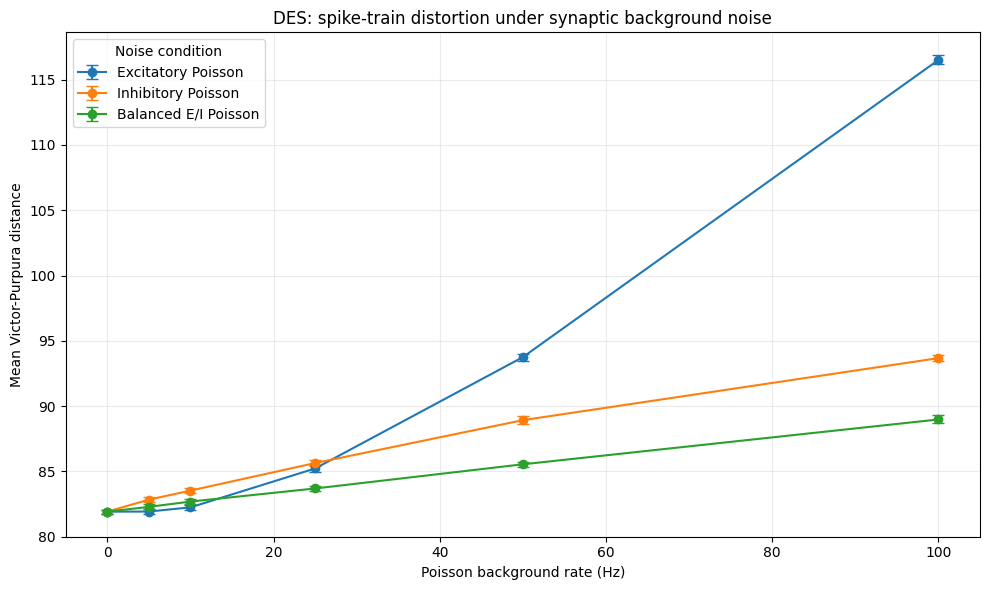

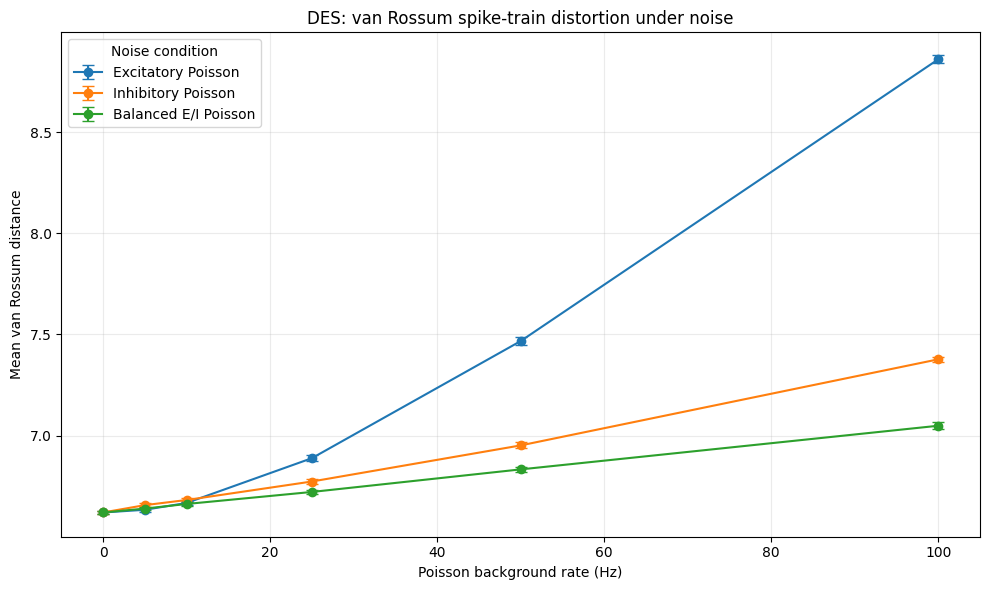

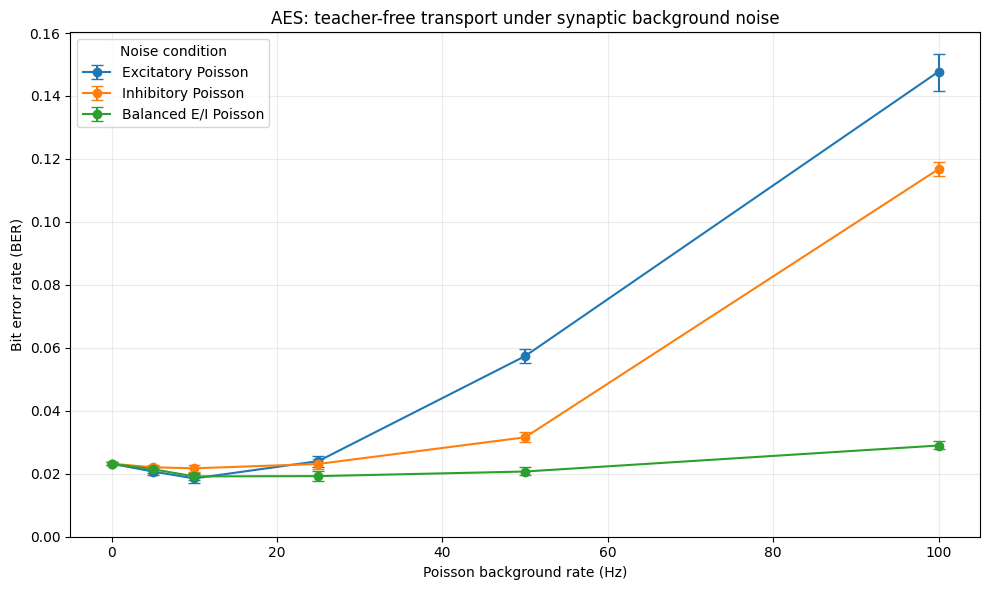

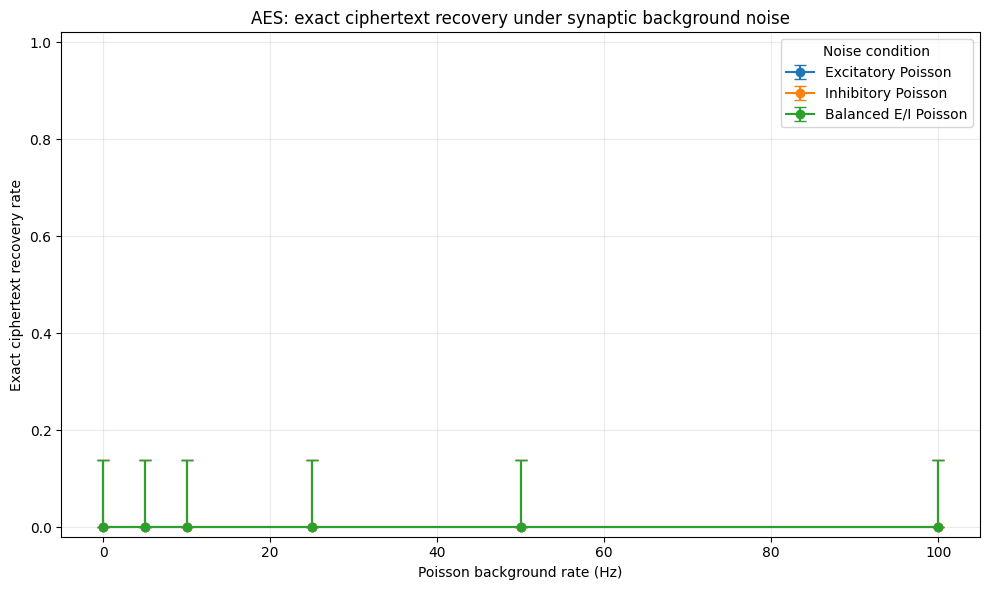

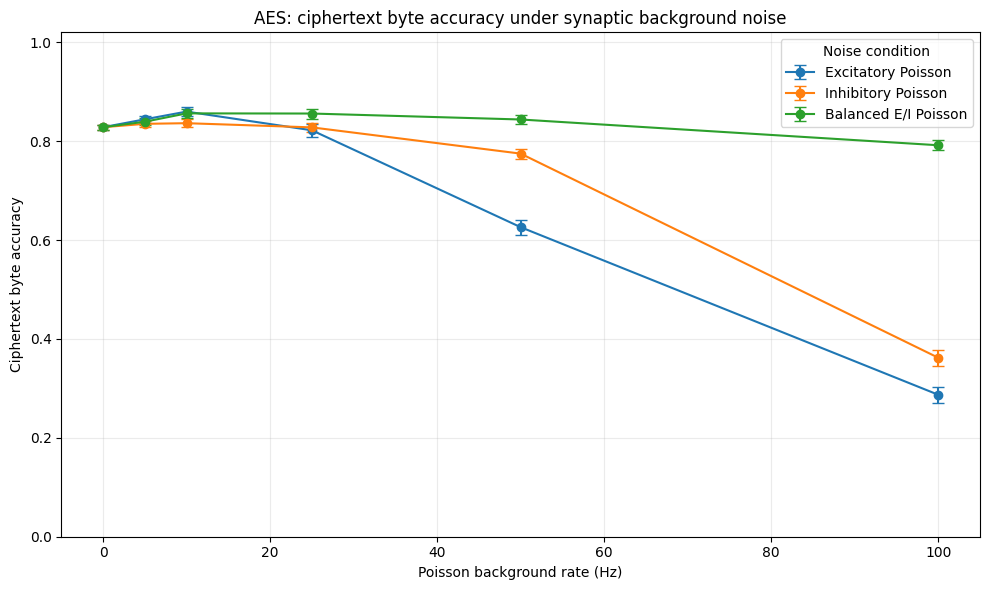

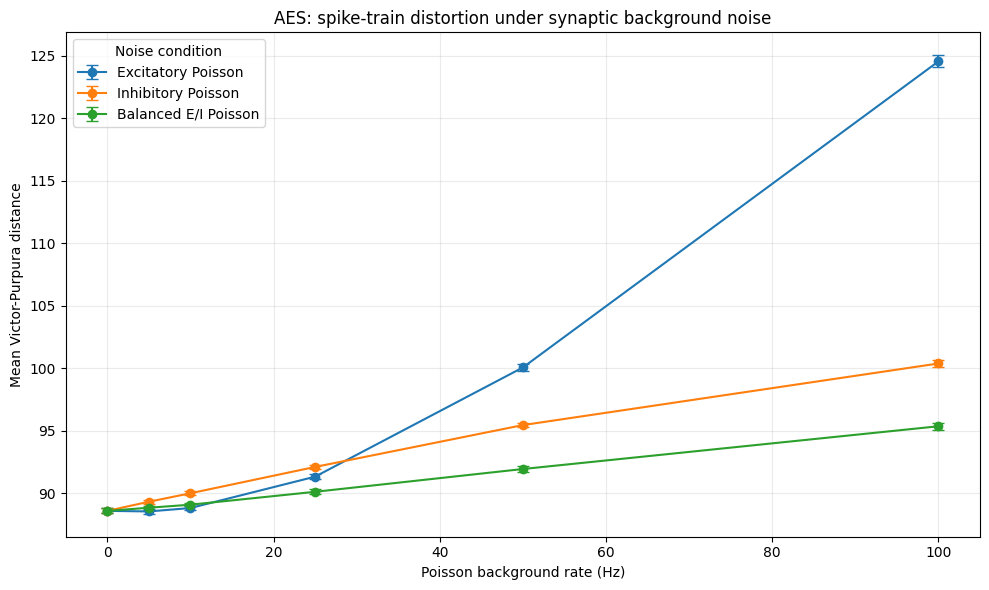

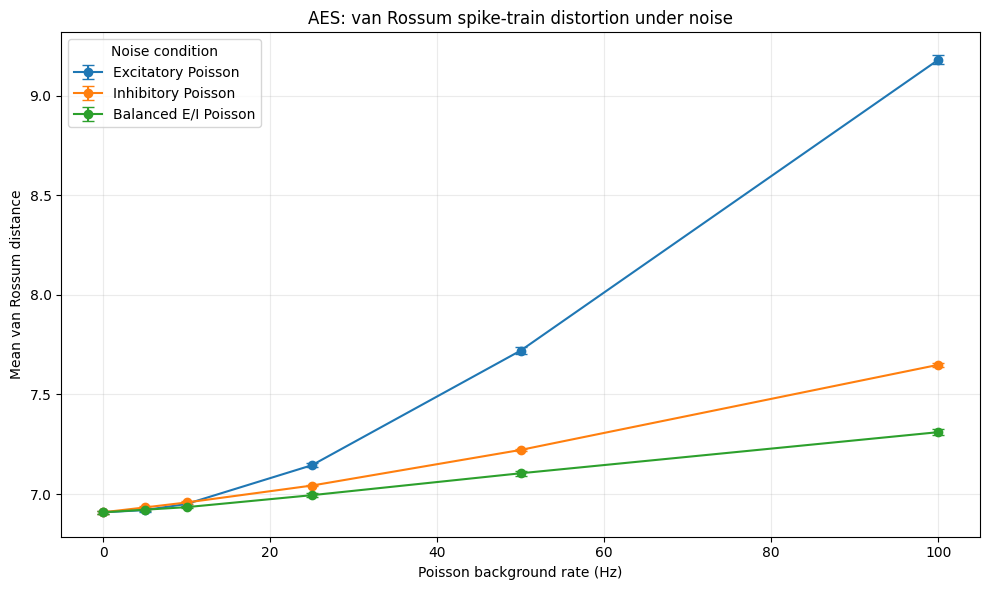

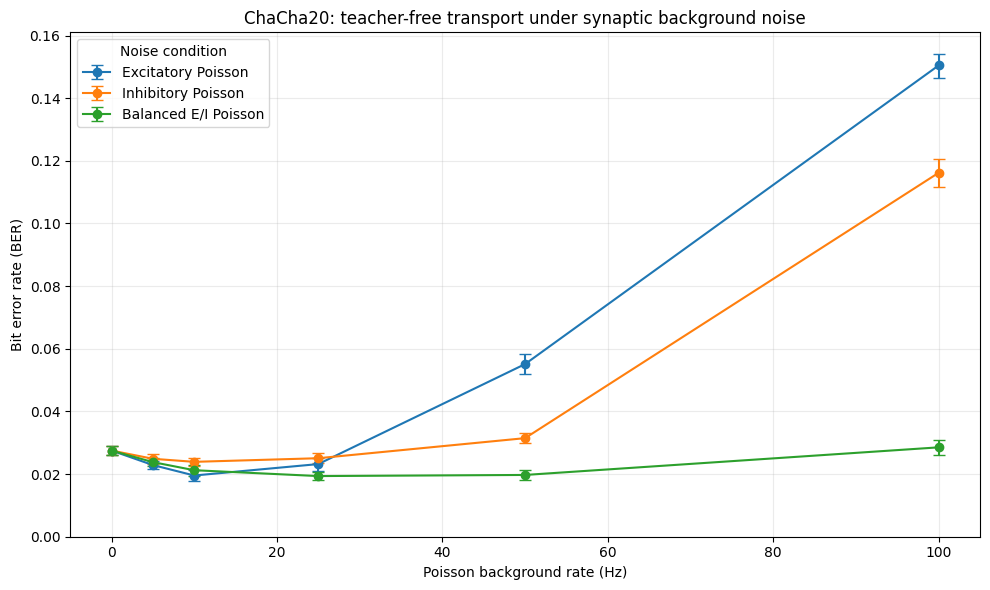

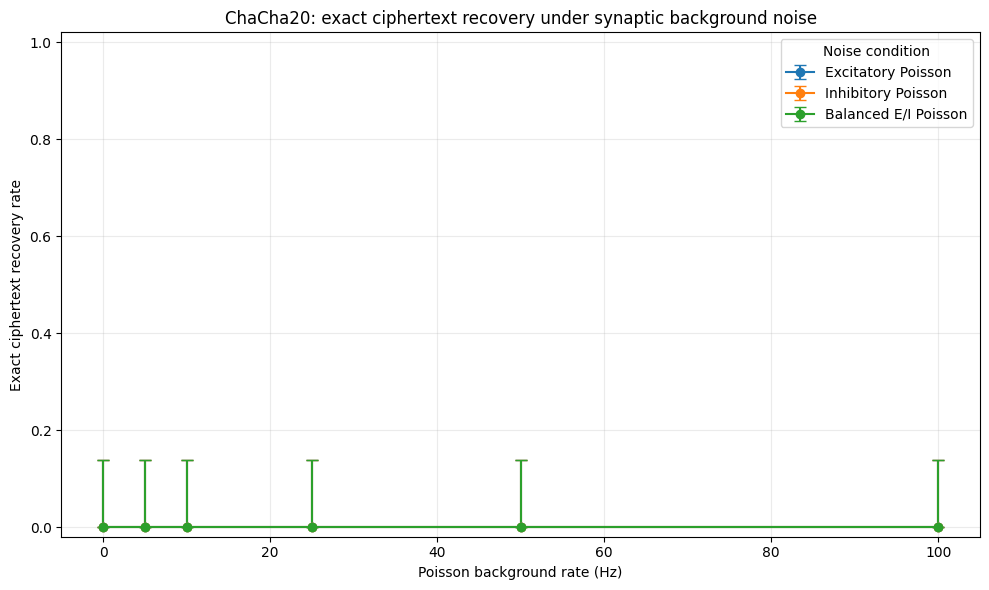

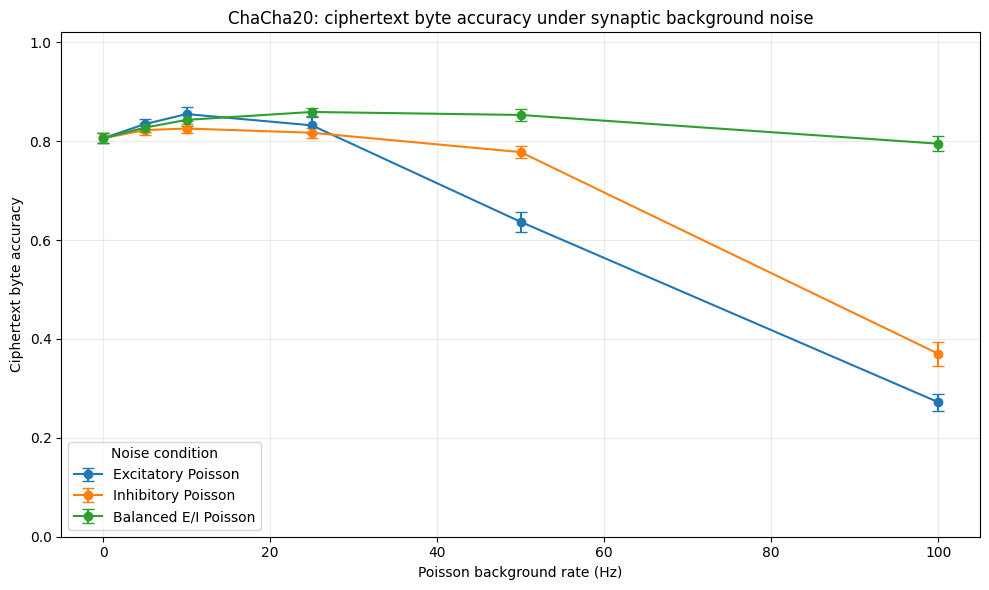

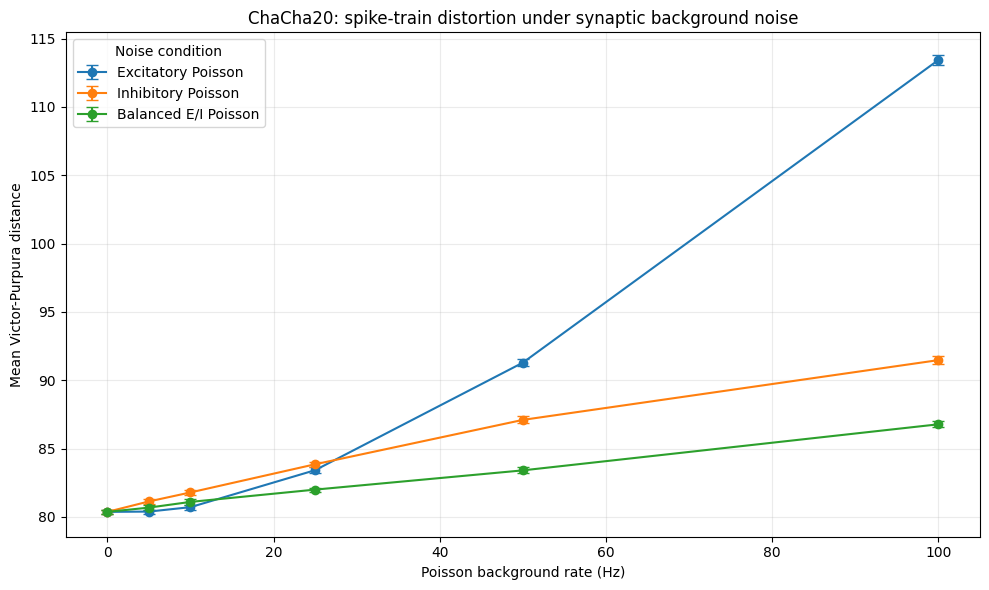

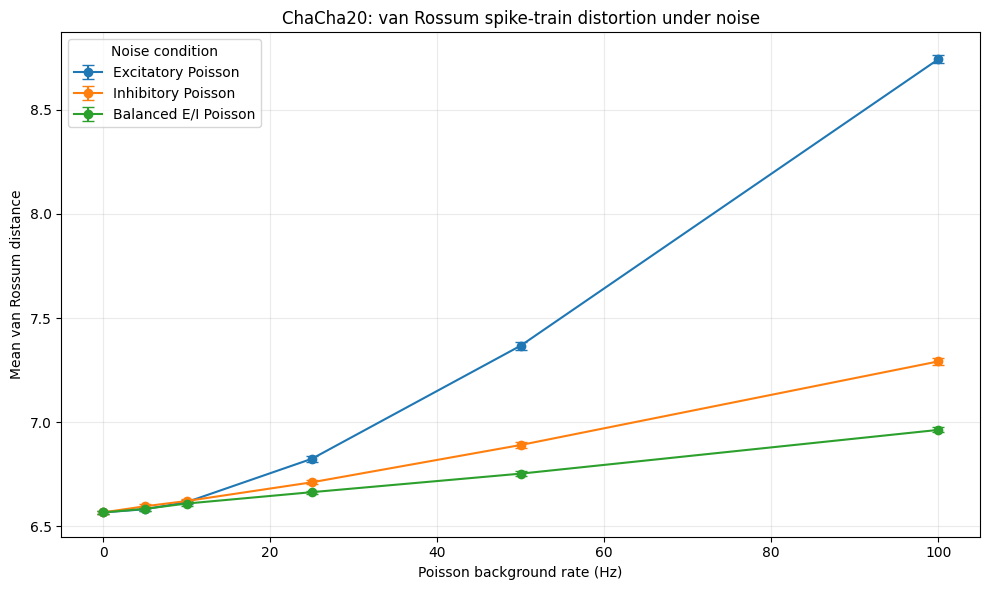

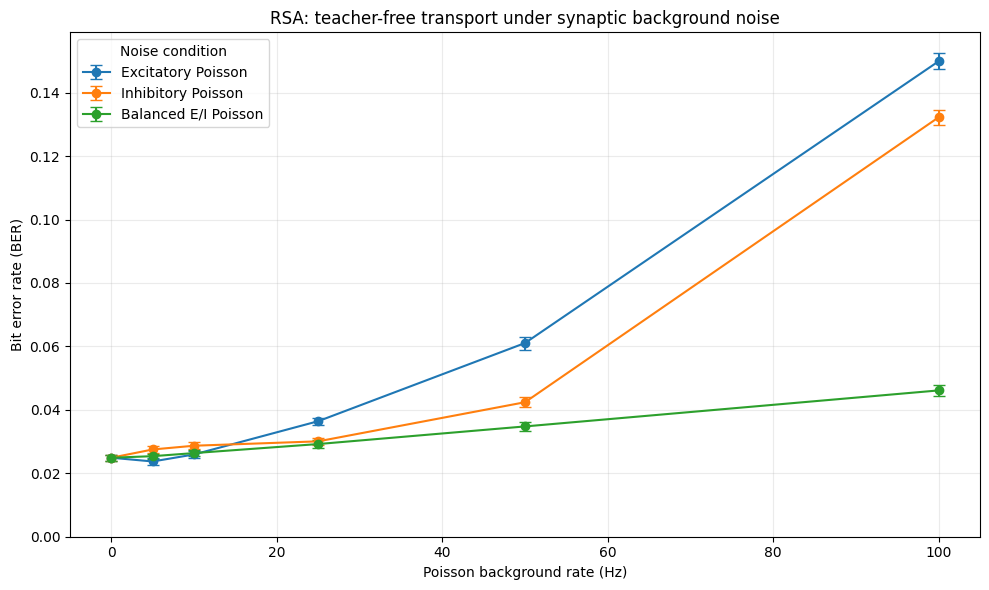

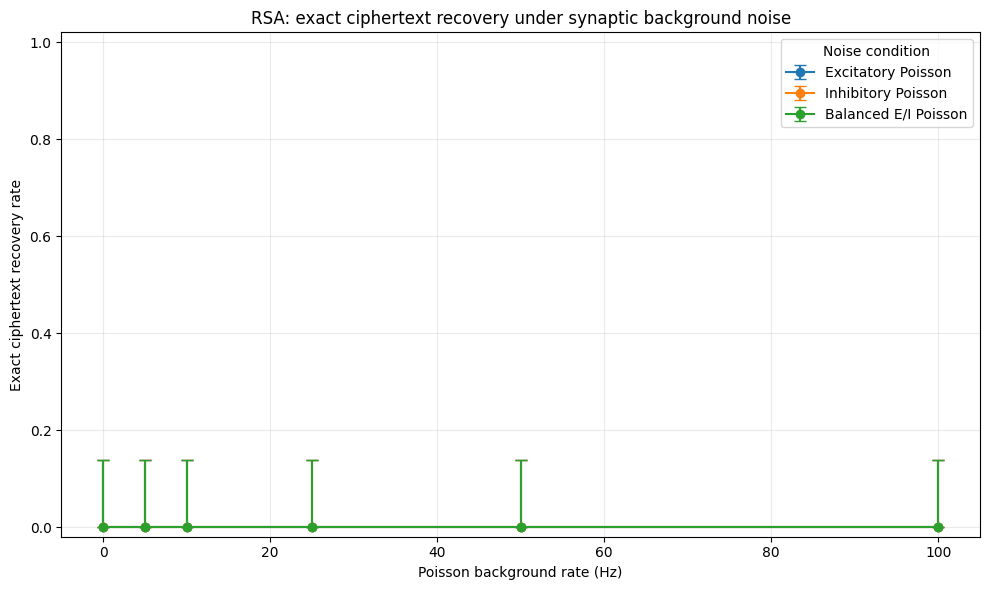

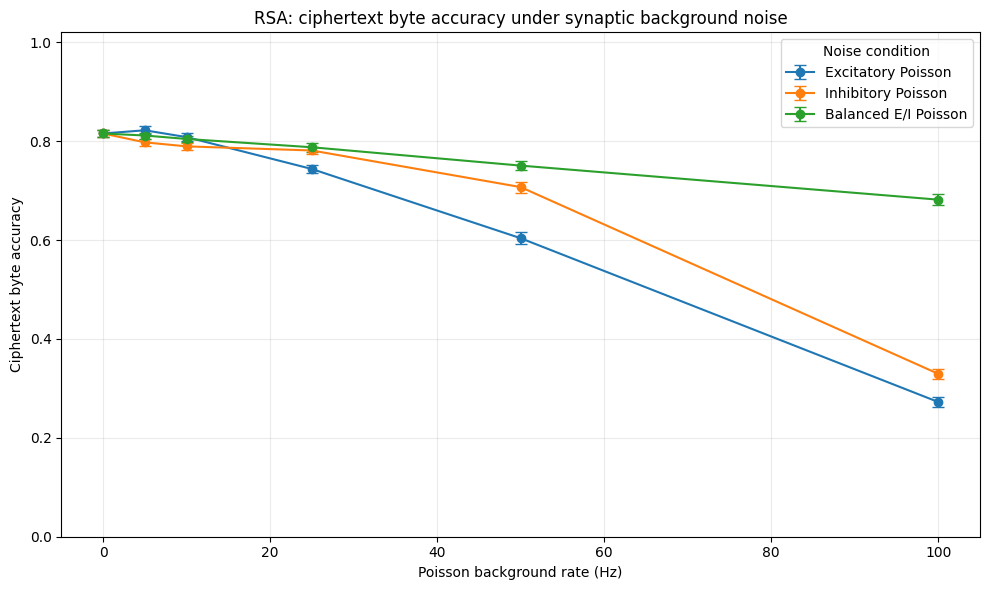

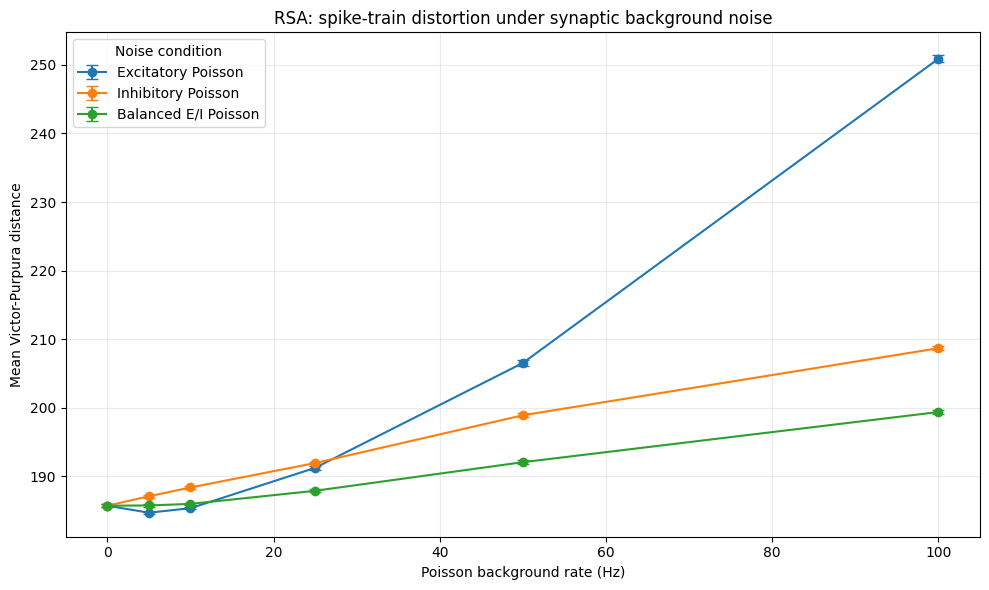

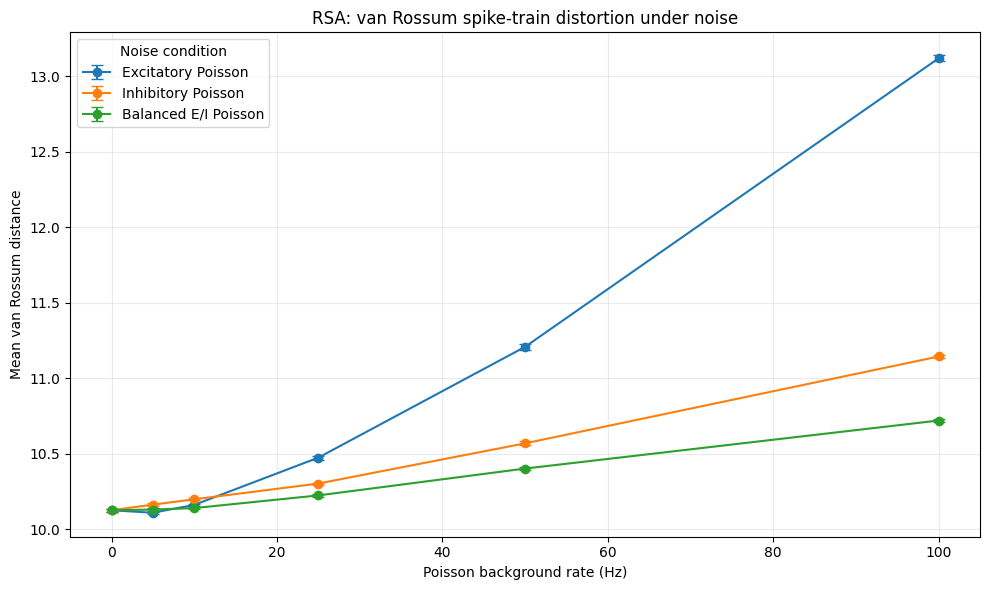

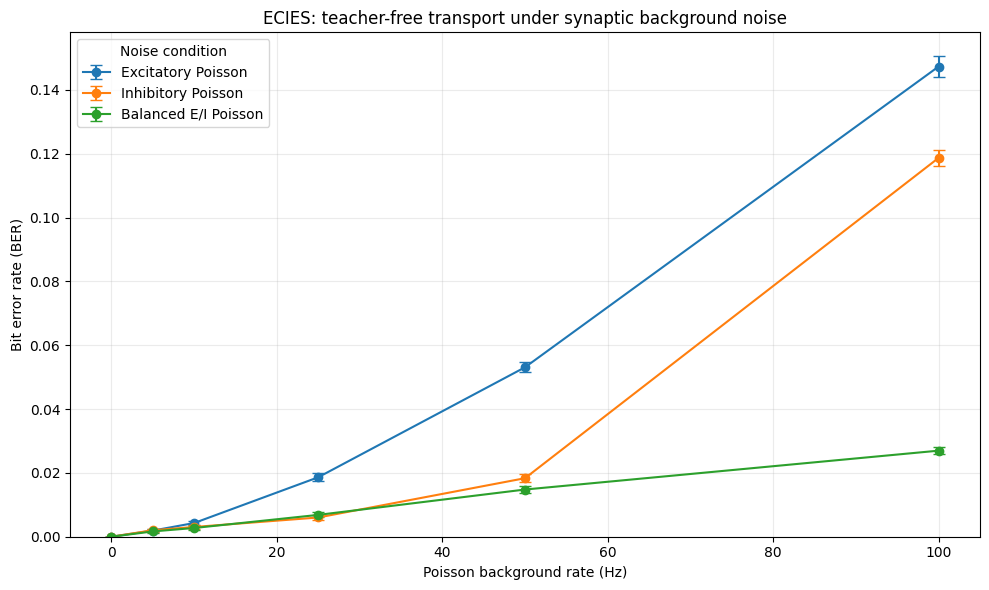

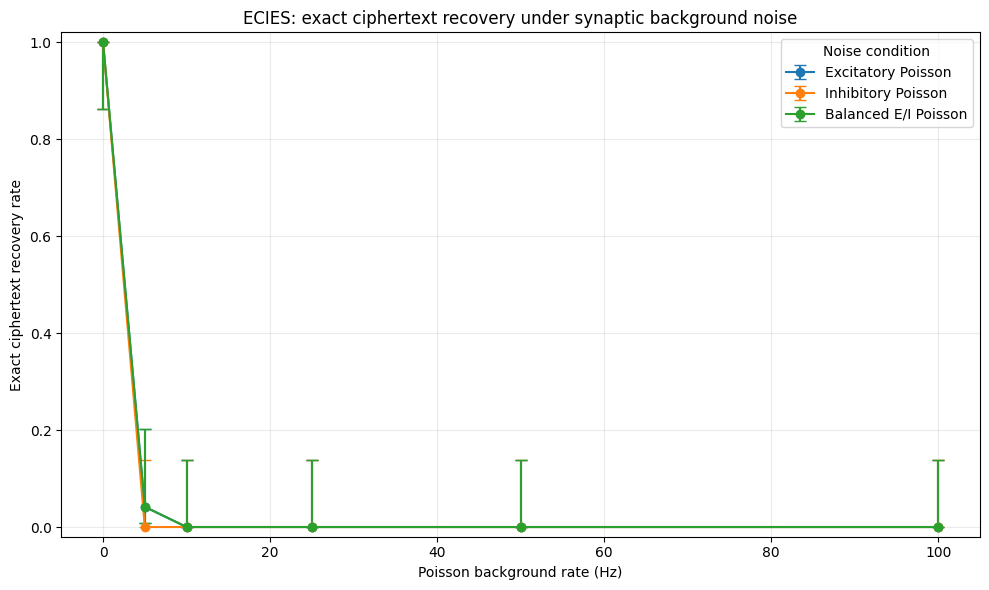

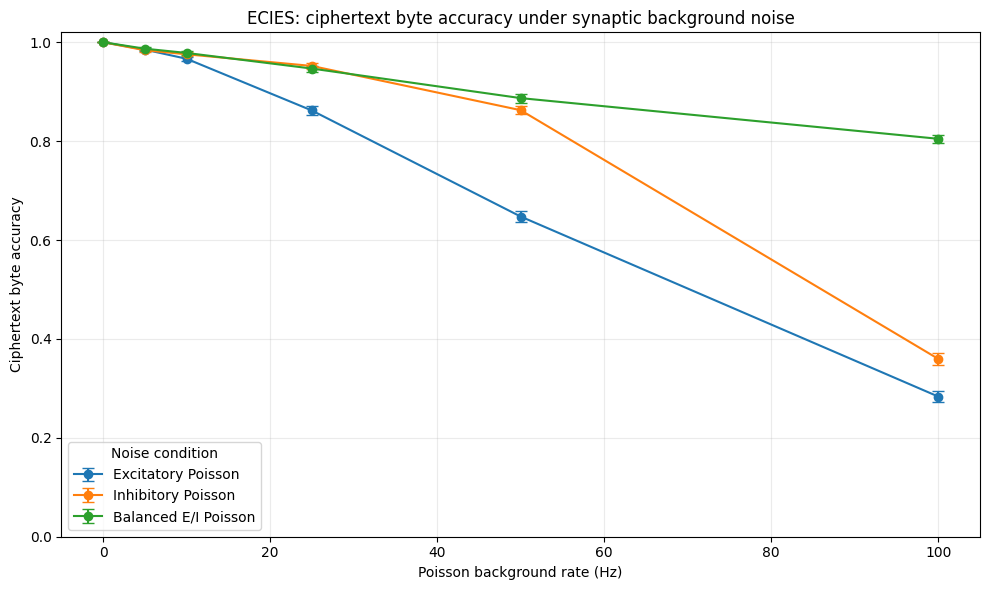

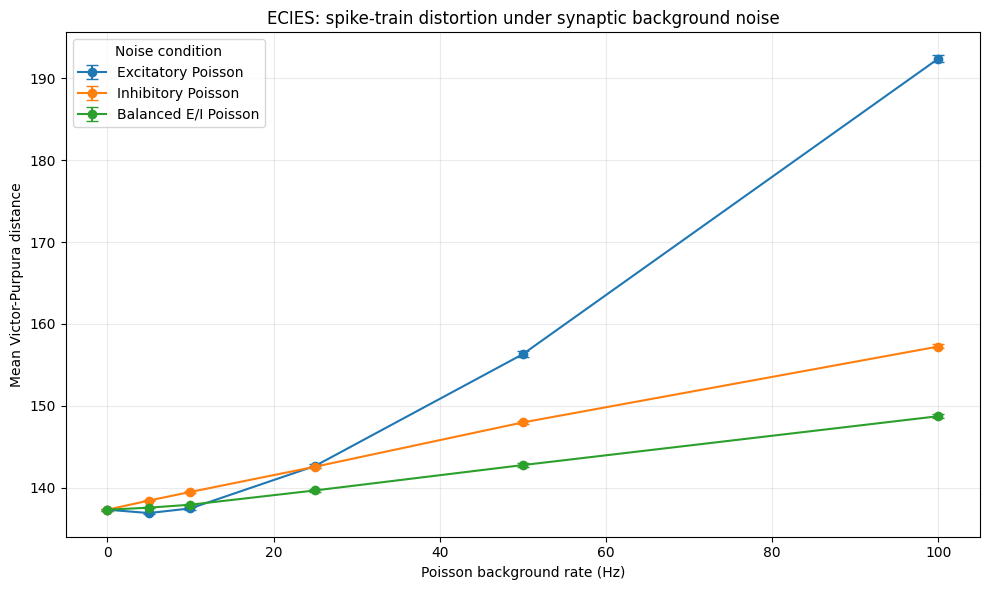

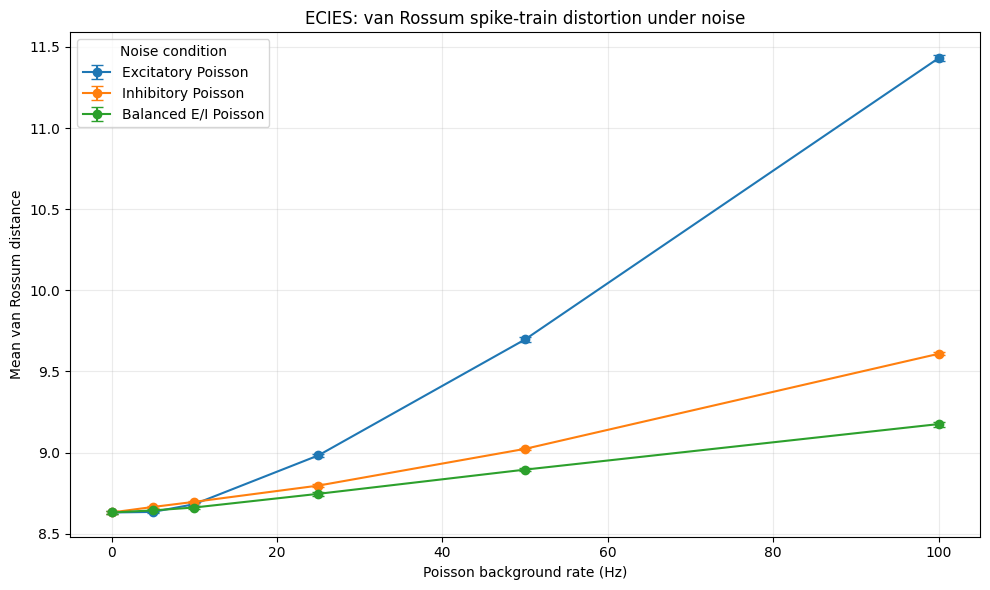

Full-noise figures generated.


In [18]:
# =============================================================================
# FULL REVIEWER 4.8 NOISE CAMPAIGN
# PLOTTING ONLY
# =============================================================================

def safe_asymmetric_yerr(
    y,
    low,
    high,
):
    """
    Convert confidence-interval endpoints to Matplotlib-compatible asymmetric
    error magnitudes.

    Matplotlib requires yerr >= 0. Floating-point rounding can otherwise
    produce tiny negative values such as -1e-17.
    """

    y = np.asarray(
        y,
        dtype=float,
    )

    low = np.asarray(
        low,
        dtype=float,
    )

    high = np.asarray(
        high,
        dtype=float,
    )

    lower_error = np.clip(
        y - low,
        0.0,
        None,
    )

    upper_error = np.clip(
        high - y,
        0.0,
        None,
    )

    return np.vstack(
        [
            lower_error,
            upper_error,
        ]
    )


# Human-readable names used in the figures.
NOISE_DISPLAY_NAMES = {
    "poisson_excitatory": (
        "Excitatory Poisson"
    ),
    "poisson_inhibitory": (
        "Inhibitory Poisson"
    ),
    "poisson_mixed": (
        "Balanced E/I Poisson"
    ),
}


# Ensure Cell 1 has been run.
required_plot_objects = [
    "full_noise_summary",
    "full_noise_results",
    "full_noise_claim_gate",
]

missing_plot_objects = [
    name
    for name in required_plot_objects
    if name not in globals()
]

if missing_plot_objects:

    raise RuntimeError(
        "Run the full-noise analysis cell first. "
        "Missing objects: "
        + ", ".join(
            missing_plot_objects
        )
    )


# =============================================================================
# GENERATE FIGURES FOR EACH CRYPTOGRAPHIC ALGORITHM
# =============================================================================

for algorithm in CRYPTO_ALGORITHMS:

    baseline = full_noise_summary[
        (
            full_noise_summary[
                "algorithm"
            ] == algorithm
        )
        & (
            full_noise_summary[
                "noise_type"
            ] == "none"
        )
        & (
            full_noise_summary[
                "noise_rate_hz"
            ] == 0.0
        )
    ].copy()

    if baseline.empty:

        print(
            f"Skipping {algorithm}: "
            "zero-noise baseline is missing."
        )

        continue


    # =========================================================================
    # FIGURE 1
    # BER versus noise rate
    # =========================================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    for noise_type in FULL_NOISE_TYPES:

        noisy = full_noise_summary[
            (
                full_noise_summary[
                    "algorithm"
                ] == algorithm
            )
            & (
                full_noise_summary[
                    "noise_type"
                ] == noise_type
            )
        ].copy()

        combined = (
            pd.concat(
                [
                    baseline.assign(
                        noise_type=(
                            noise_type
                        )
                    ),
                    noisy,
                ],
                ignore_index=True,
            )
            .sort_values(
                "noise_rate_hz"
            )
        )

        x = combined[
            "noise_rate_hz"
        ].to_numpy(
            dtype=float
        )

        y = combined[
            "ber_mean"
        ].to_numpy(
            dtype=float
        )

        low = combined[
            "ber_ci95_low"
        ].to_numpy(
            dtype=float
        )

        high = combined[
            "ber_ci95_high"
        ].to_numpy(
            dtype=float
        )

        yerr = (
            safe_asymmetric_yerr(
                y,
                low,
                high,
            )
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=(
                NOISE_DISPLAY_NAMES[
                    noise_type
                ]
            ),
        )

    plt.xlabel(
        "Poisson background rate (Hz)"
    )

    plt.ylabel(
        "Bit error rate (BER)"
    )

    plt.title(
        f"{algorithm}: teacher-free transport "
        "under synaptic background noise"
    )

    plt.ylim(
        bottom=0
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend(
        title=(
            "Noise condition"
        )
    )

    plt.tight_layout()

    if SAVE_FIGURES:

        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "full_noise_ber.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


    # =========================================================================
    # FIGURE 2
    # Exact ciphertext recovery versus noise rate
    # =========================================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    for noise_type in FULL_NOISE_TYPES:

        noisy = full_noise_summary[
            (
                full_noise_summary[
                    "algorithm"
                ] == algorithm
            )
            & (
                full_noise_summary[
                    "noise_type"
                ] == noise_type
            )
        ].copy()

        combined = (
            pd.concat(
                [
                    baseline.assign(
                        noise_type=(
                            noise_type
                        )
                    ),
                    noisy,
                ],
                ignore_index=True,
            )
            .sort_values(
                "noise_rate_hz"
            )
        )

        x = combined[
            "noise_rate_hz"
        ].to_numpy(
            dtype=float
        )

        y = combined[
            "exact_ciphertext_recovery_rate"
        ].to_numpy(
            dtype=float
        )

        low = combined[
            "exact_ciphertext_recovery_wilson95_low"
        ].to_numpy(
            dtype=float
        )

        high = combined[
            "exact_ciphertext_recovery_wilson95_high"
        ].to_numpy(
            dtype=float
        )

        yerr = (
            safe_asymmetric_yerr(
                y,
                low,
                high,
            )
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=(
                NOISE_DISPLAY_NAMES[
                    noise_type
                ]
            ),
        )

    plt.xlabel(
        "Poisson background rate (Hz)"
    )

    plt.ylabel(
        "Exact ciphertext recovery rate"
    )

    plt.title(
        f"{algorithm}: exact ciphertext recovery "
        "under synaptic background noise"
    )

    plt.ylim(
        -0.02,
        1.02,
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend(
        title=(
            "Noise condition"
        )
    )

    plt.tight_layout()

    if SAVE_FIGURES:

        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "full_noise_exact_recovery.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


    # =========================================================================
    # FIGURE 3
    # Ciphertext byte accuracy versus noise
    # =========================================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    for noise_type in FULL_NOISE_TYPES:

        noisy = full_noise_summary[
            (
                full_noise_summary[
                    "algorithm"
                ] == algorithm
            )
            & (
                full_noise_summary[
                    "noise_type"
                ] == noise_type
            )
        ].copy()

        combined = (
            pd.concat(
                [
                    baseline.assign(
                        noise_type=(
                            noise_type
                        )
                    ),
                    noisy,
                ],
                ignore_index=True,
            )
            .sort_values(
                "noise_rate_hz"
            )
        )

        x = combined[
            "noise_rate_hz"
        ].to_numpy(
            dtype=float
        )

        y = combined[
            "ciphertext_byte_accuracy_mean"
        ].to_numpy(
            dtype=float
        )

        low = combined[
            "ciphertext_byte_accuracy_ci95_low"
        ].to_numpy(
            dtype=float
        )

        high = combined[
            "ciphertext_byte_accuracy_ci95_high"
        ].to_numpy(
            dtype=float
        )

        yerr = (
            safe_asymmetric_yerr(
                y,
                low,
                high,
            )
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=(
                NOISE_DISPLAY_NAMES[
                    noise_type
                ]
            ),
        )

    plt.xlabel(
        "Poisson background rate (Hz)"
    )

    plt.ylabel(
        "Ciphertext byte accuracy"
    )

    plt.title(
        f"{algorithm}: ciphertext byte accuracy "
        "under synaptic background noise"
    )

    plt.ylim(
        0.0,
        1.02,
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend(
        title=(
            "Noise condition"
        )
    )

    plt.tight_layout()

    if SAVE_FIGURES:

        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "full_noise_byte_accuracy.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


    # =========================================================================
    # FIGURE 4
    # Victor-Purpura spike-train distance
    # =========================================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    for noise_type in FULL_NOISE_TYPES:

        noisy = full_noise_summary[
            (
                full_noise_summary[
                    "algorithm"
                ] == algorithm
            )
            & (
                full_noise_summary[
                    "noise_type"
                ] == noise_type
            )
        ].copy()

        combined = (
            pd.concat(
                [
                    baseline.assign(
                        noise_type=(
                            noise_type
                        )
                    ),
                    noisy,
                ],
                ignore_index=True,
            )
            .sort_values(
                "noise_rate_hz"
            )
        )

        x = combined[
            "noise_rate_hz"
        ].to_numpy(
            dtype=float
        )

        y = combined[
            "victor_purpura_mean_mean"
        ].to_numpy(
            dtype=float
        )

        low = combined[
            "victor_purpura_mean_ci95_low"
        ].to_numpy(
            dtype=float
        )

        high = combined[
            "victor_purpura_mean_ci95_high"
        ].to_numpy(
            dtype=float
        )

        yerr = (
            safe_asymmetric_yerr(
                y,
                low,
                high,
            )
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=(
                NOISE_DISPLAY_NAMES[
                    noise_type
                ]
            ),
        )

    plt.xlabel(
        "Poisson background rate (Hz)"
    )

    plt.ylabel(
        "Mean Victor-Purpura distance"
    )

    plt.title(
        f"{algorithm}: spike-train distortion "
        "under synaptic background noise"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend(
        title=(
            "Noise condition"
        )
    )

    plt.tight_layout()

    if SAVE_FIGURES:

        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "full_noise_victor_purpura.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


    # =========================================================================
    # FIGURE 5
    # van Rossum spike-train distance
    # =========================================================================

    plt.figure(
        figsize=(
            10,
            6,
        )
    )

    for noise_type in FULL_NOISE_TYPES:

        noisy = full_noise_summary[
            (
                full_noise_summary[
                    "algorithm"
                ] == algorithm
            )
            & (
                full_noise_summary[
                    "noise_type"
                ] == noise_type
            )
        ].copy()

        combined = (
            pd.concat(
                [
                    baseline.assign(
                        noise_type=(
                            noise_type
                        )
                    ),
                    noisy,
                ],
                ignore_index=True,
            )
            .sort_values(
                "noise_rate_hz"
            )
        )

        x = combined[
            "noise_rate_hz"
        ].to_numpy(
            dtype=float
        )

        y = combined[
            "van_rossum_mean_mean"
        ].to_numpy(
            dtype=float
        )

        low = combined[
            "van_rossum_mean_ci95_low"
        ].to_numpy(
            dtype=float
        )

        high = combined[
            "van_rossum_mean_ci95_high"
        ].to_numpy(
            dtype=float
        )

        yerr = (
            safe_asymmetric_yerr(
                y,
                low,
                high,
            )
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=(
                NOISE_DISPLAY_NAMES[
                    noise_type
                ]
            ),
        )

    plt.xlabel(
        "Poisson background rate (Hz)"
    )

    plt.ylabel(
        "Mean van Rossum distance"
    )

    plt.title(
        f"{algorithm}: van Rossum spike-train "
        "distortion under noise"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend(
        title=(
            "Noise condition"
        )
    )

    plt.tight_layout()

    if SAVE_FIGURES:

        plt.savefig(
            RESULTS_DIR
            / (
                f"{algorithm}_"
                "full_noise_van_rossum.png"
            ),
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    plt.show()


print(
    "Full-noise figures generated."
)


## Teaching-weight sensitivity


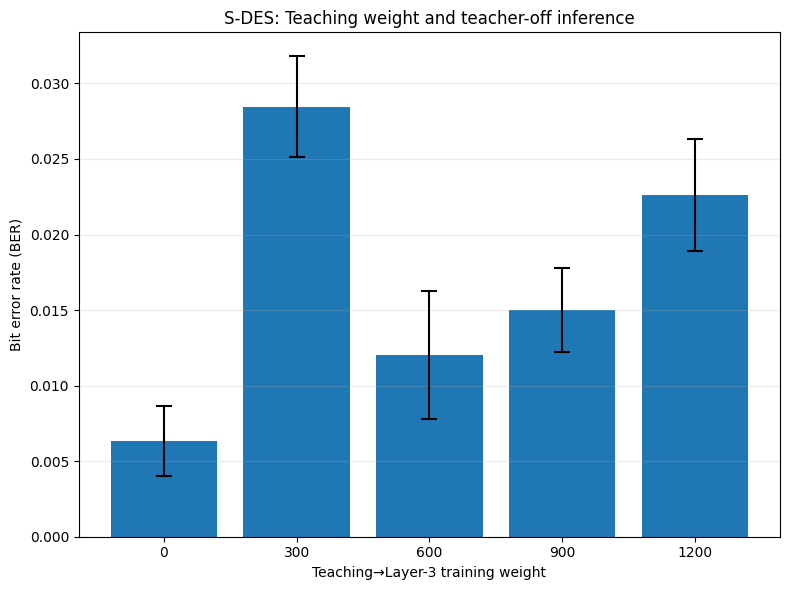

,teacher_weight,mean,std,n
0,0.0,0.006310,0.002317,10
1,300.0,0.028452,0.003341,10
2,600.0,0.012024,0.004254,10
3,900.0,0.015000,0.002761,10
4,1200.0,0.022619,0.003680,10


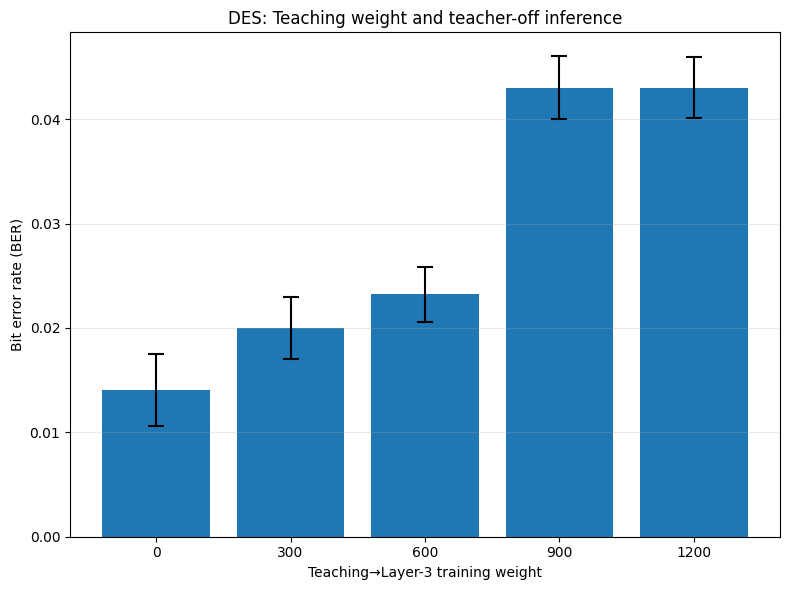

,teacher_weight,mean,std,n
0,0.0,0.014063,0.003446,10
1,300.0,0.020000,0.002938,10
2,600.0,0.023229,0.002647,10
3,900.0,0.043021,0.002989,10
4,1200.0,0.043021,0.002948,10


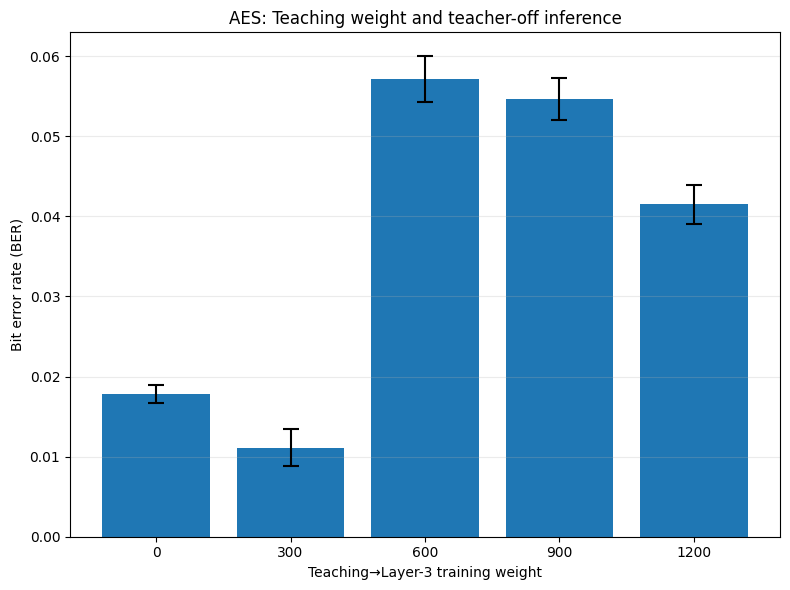

,teacher_weight,mean,std,n
0,0.0,0.017773,0.001109,10
1,300.0,0.011133,0.002265,10
2,600.0,0.057129,0.002847,10
3,900.0,0.054688,0.002645,10
4,1200.0,0.041504,0.002447,10


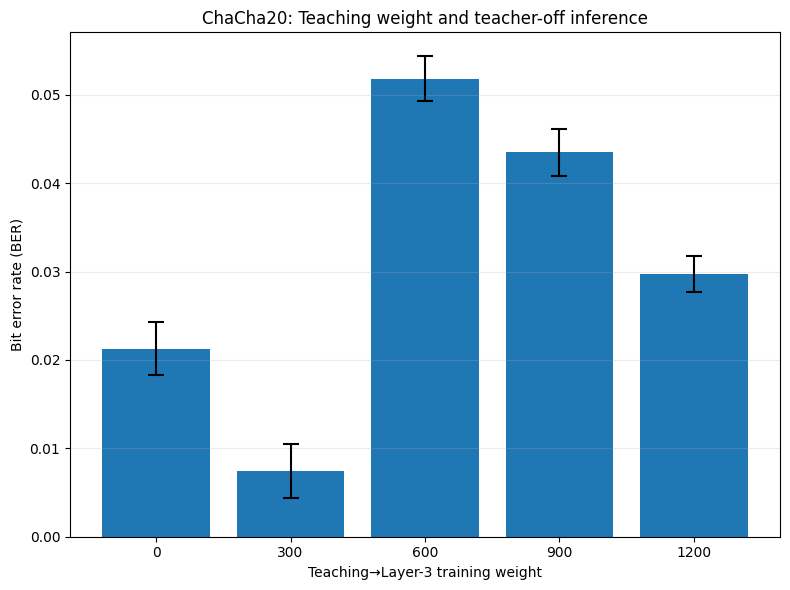

,teacher_weight,mean,std,n
0,0.0,0.021261,0.002999,10
1,300.0,0.007479,0.003064,10
2,600.0,0.051816,0.002531,10
3,900.0,0.043483,0.002667,10
4,1200.0,0.029701,0.002064,10


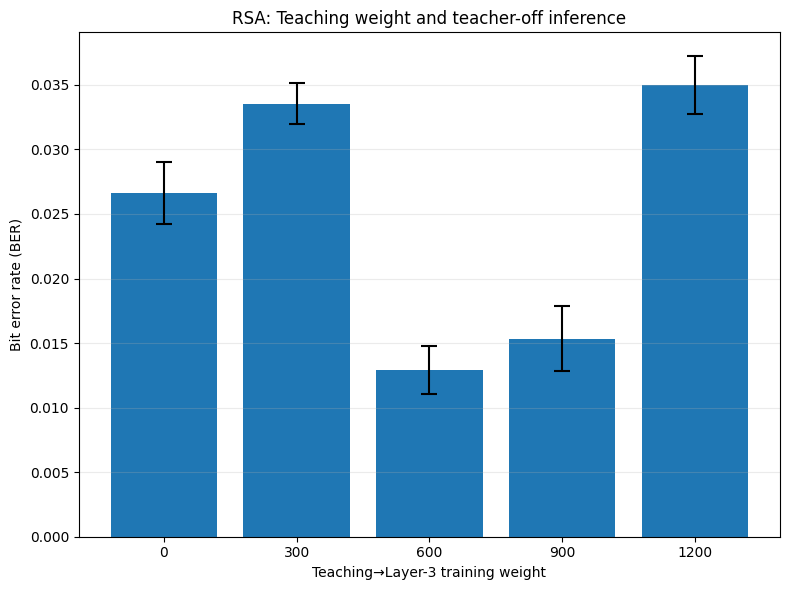

,teacher_weight,mean,std,n
0,0.0,0.026611,0.002417,10
1,300.0,0.033545,0.001562,10
2,600.0,0.012939,0.001859,10
3,900.0,0.015332,0.002524,10
4,1200.0,0.034961,0.002246,10


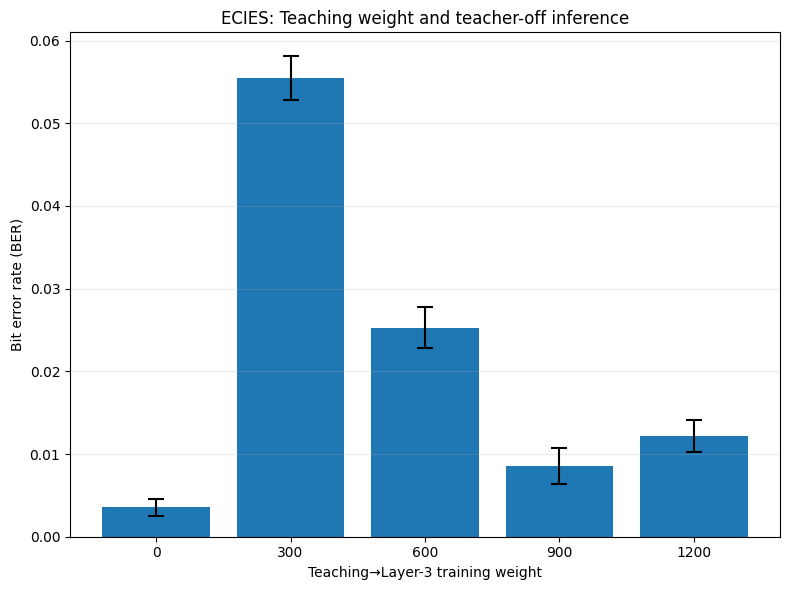

,teacher_weight,mean,std,n
0,0.0,0.003535,0.001081,10
1,300.0,0.055429,0.002659,10
2,600.0,0.025253,0.002490,10
3,900.0,0.008586,0.002191,10
4,1200.0,0.012184,0.001883,10


In [19]:
if not teaching_weight_results.empty:
    weight_summary = summarise_results(
        teaching_weight_results,
        ["algorithm", "teacher_weight"],
    )
    weight_summary.to_csv(
        RESULTS_DIR / "teaching_weight_sweep_summary.csv",
        index=False,
    )

    for algorithm in CRYPTO_ALGORITHMS:
        subset = teaching_weight_results[
            teaching_weight_results["algorithm"] == algorithm
        ].copy()

        stats = (
            subset
            .groupby("teacher_weight", as_index=False)["ber"]
            .agg(mean="mean", std="std", n="count")
        )
        stats["std"] = stats["std"].fillna(0.0)
        stats = stats.sort_values("teacher_weight")

        x = np.arange(len(stats))

        plt.figure(figsize=(8, 6))
        plt.bar(
            x,
            stats["mean"],
            yerr=stats["std"],
            capsize=6,
            error_kw={"elinewidth": 1.5, "capthick": 1.5},
        )
        plt.xticks(
            x,
            [f"{v:g}" for v in stats["teacher_weight"]],
        )
        plt.xlabel("Teaching→Layer-3 training weight")
        plt.ylabel("Bit error rate (BER)")
        plt.title(
            f"{algorithm}: Teaching weight and teacher-off inference"
        )
        plt.ylim(bottom=0)
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()

        if SAVE_FIGURES:
            plt.savefig(
                RESULTS_DIR / f"{algorithm}_teaching_weight_sweep.png",
                dpi=FIGURE_DPI,
                bbox_inches="tight",
            )

        plt.show()
        display(stats)


## Stage-by-stage latency

All stages are timed with `time.perf_counter()` on the same machine and Python process. Network construction is reported separately because a persistent deployed network would normally be built once. Key generation and training are setup costs and are not hidden inside per-message latency.


In [20]:
class PeakRSSMonitor:
    def __init__(self, interval_s=0.01):
        self.interval_s = interval_s
        self.process = psutil.Process(os.getpid())
        self.peak_bytes = 0
        self._stop = threading.Event()
        self._thread = None

    def _sample(self):
        while not self._stop.is_set():
            try:
                self.peak_bytes = max(
                    self.peak_bytes,
                    self.process.memory_info().rss,
                )
            except Exception:
                pass
            time.sleep(self.interval_s)

    def __enter__(self):
        self.peak_bytes = self.process.memory_info().rss
        self._thread = threading.Thread(
            target=self._sample,
            daemon=True,
        )
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        self.peak_bytes = max(
            self.peak_bytes,
            self.process.memory_info().rss,
        )

    @property
    def peak_mb(self):
        return self.peak_bytes / (1024 ** 2)

def run_stage_timing(weight_cache):
    if not RUN_STAGE_TIMING:
        return pd.DataFrame()

    rows = []

    for algorithm in CRYPTO_ALGORITHMS:
        context = CRYPTO_CONTEXTS[algorithm]

        for trial in range(min(TIMING_TRIALS, N_TRIALS)):
            weights = weight_cache[(algorithm, trial, "primary")]

            t0 = time.perf_counter()
            ciphertext = context.encrypt(
                TEST_PLAINTEXT,
                token=f"timing-{trial}",
            )
            encryption_s = time.perf_counter() - t0

            t0 = time.perf_counter()
            _ = [byte_to_bits(v) for v in ciphertext]
            encoding_s = time.perf_counter() - t0

            duration = total_presentation_duration_ms(len(ciphertext), 1)
            schedule = make_noise_schedule(
                n_neurons=NUM_LAYER2,
                noise_type="none",
                rate_hz=0.0,
                duration_ms=duration,
                seed=stable_seed("timing-noise", algorithm, trial),
            )

            with PeakRSSMonitor() as memory:
                t0 = time.perf_counter()
                network = build_network(
                    seed=stable_seed("timing-network", algorithm, trial),
                    plastic_l2_l3=False,
                    frozen_l2_l3_weights=weights,
                    teacher_enabled=False,
                    teacher_weight=TEACHING_L3_WEIGHT,
                    main_path_enabled=True,
                    noise_schedule=schedule,
                    transport_params=ES_BEST_PARAMS,
                )
                network_build_s = time.perf_counter() - t0

                t0 = time.perf_counter()
                windows = present_ciphertext(
                    network,
                    ciphertext,
                    epochs=1,
                    teacher_active=False,
                    collect_windows=True,
                    transport_params=ES_BEST_PARAMS,
                )
                snn_simulation_s = time.perf_counter() - t0

                t0 = time.perf_counter()
                senders, times = get_events(
                    network["recorders"], "layer3"
                )
                readout_s = time.perf_counter() - t0

                t0 = time.perf_counter()
                recovered_ct, tie_fraction = decode_layer3_bytes(
                    network["layers"]["layer3"],
                    senders,
                    times,
                    windows,
                )
                decoding_s = time.perf_counter() - t0

            t0 = time.perf_counter()
            try:
                recovered_plaintext = context.decrypt(recovered_ct)
                decryption_success = True
            except Exception:
                recovered_plaintext = None
                decryption_success = False
            decryption_s = time.perf_counter() - t0

            online_without_build = (
                encryption_s
                + encoding_s
                + snn_simulation_s
                + readout_s
                + decoding_s
                + decryption_s
            )

            rows.append({
                "algorithm": algorithm,
                "trial": trial,
                "plaintext_bytes": len(TEST_PLAINTEXT),
                "ciphertext_bytes": len(ciphertext),
                "encryption_s": encryption_s,
                "encoding_s": encoding_s,
                "network_build_s": network_build_s,
                "snn_simulation_s": snn_simulation_s,
                "spike_readout_s": readout_s,
                "decoding_s": decoding_s,
                "decryption_s": decryption_s,
                "online_total_without_build_s": online_without_build,
                "online_total_with_build_s": online_without_build + network_build_s,
                "peak_process_rss_mb": memory.peak_mb,
                "decoder_tie_fraction": tie_fraction,
                "decryption_success": decryption_success,
                "exact_plaintext_recovery": (
                    recovered_plaintext == TEST_PLAINTEXT
                    if recovered_plaintext is not None else False
                ),
            })

    return pd.DataFrame(rows)

timing_results = run_stage_timing(weight_cache)

if not timing_results.empty:
    timing_results.to_csv(
        RESULTS_DIR / "stage_timing_trials.csv",
        index=False,
    )

    timing_summary = (
        timing_results
        .groupby("algorithm")[[
            "encryption_s",
            "encoding_s",
            "network_build_s",
            "snn_simulation_s",
            "spike_readout_s",
            "decoding_s",
            "decryption_s",
            "online_total_without_build_s",
            "online_total_with_build_s",
            "peak_process_rss_mb",
        ]]
        .agg(["mean", "std"])
    )

    timing_summary.to_csv(
        RESULTS_DIR / "stage_timing_summary.csv"
    )

    display(timing_results)
    display(timing_summary)


,algorithm,trial,plaintext_bytes,ciphertext_bytes,encryption_s,encoding_s,network_build_s,snn_simulation_s,spike_readout_s,decoding_s,decryption_s,online_total_without_build_s,online_total_with_build_s,peak_process_rss_mb,decoder_tie_fraction,decryption_success,exact_plaintext_recovery
0,S-DES,0,105,105,0.001335,0.000145,0.070428,0.538850,0.000110,0.012496,0.001410,0.554346,0.624774,587.890625,0.008333,True,False
1,S-DES,1,105,105,0.001287,0.000176,0.064057,0.537925,0.000081,0.012833,0.001449,0.553751,0.617808,587.890625,0.008333,True,False
2,S-DES,2,105,105,0.001318,0.000159,0.064487,0.538762,0.000079,0.012285,0.001334,0.553937,0.618424,587.890625,0.008333,True,False
3,S-DES,3,105,105,0.001255,0.000272,0.064719,0.541036,0.000081,0.012062,0.001342,0.556048,0.620767,587.890625,0.008333,True,False
4,S-DES,4,105,105,0.001300,0.000167,0.064378,0.543454,0.000080,0.012854,0.001448,0.559302,0.623680,587.890625,0.008333,True,False
5,S-DES,5,105,105,0.001276,0.000176,0.064708,0.536599,0.000079,0.012031,0.001346,0.551506,0.616215,587.890625,0.008333,True,False
6,S-DES,6,105,105,0.001283,0.000167,0.064851,0.541468,0.000080,0.012236,0.001337,0.556571,0.621422,587.890625,0.008333,True,False
7,S-DES,7,105,105,0.001281,0.000149,0.064889,0.538479,0.000079,0.012447,0.001379,0.553814,0.618703,587.890625,0.008333,True,False
8,S-DES,8,105,105,0.001271,0.000168,0.065240,0.538055,0.000081,0.012346,0.001333,0.553254,0.618494,587.890625,0.008333,True,False
9,S-DES,9,105,105,0.001295,0.000176,0.064943,0.548468,0.000104,0.013125,0.001857,0.565025,0.629968,587.890625,0.008333,True,False


encryption_s           encoding_s           network_build_s  \
                  mean       std       mean       std            mean   
algorithm                                                               
AES           0.000150  0.000027   0.000198  0.000026        0.064721   
ChaCha20      0.000149  0.000023   0.000188  0.000023        0.065407   
DES           0.000177  0.000037   0.000197  0.000029        0.064671   
ECIES         0.001843  0.000038   0.000293  0.000028        0.065238   
RSA           0.000645  0.000044   0.000362  0.000017        0.064841   
S-DES         0.001290  0.000023   0.000175  0.000036        0.065270   

                    snn_simulation_s           spike_readout_s            \
                std             mean       std            mean       std   
algorithm                                                                  
AES        0.001298         0.657476  0.003355        0.000082  0.000002   
ChaCha20   0.001474         0.602258  0.003829        0.000086  0.000015   
DES        0.000586         0.617553  0.006407        0.000087  0.000010   
ECIES      0.001032         1.012567  0.006003        0.000084  0.000003   
RSA        0.001563         1.307828  0.008268        0.000090  0.000002   
S-DES      0.001842         0.540310  0.003507        0.000085  0.000012   

          decoding_s           decryption_s            \
                mean       std         mean       std   
algorithm                                               
AES         0.015729  0.000392     0.000062  0.000010   
ChaCha20    0.014380  0.000781     0.000042  0.000009   
DES         0.014477  0.000339     0.000077  0.000012   
ECIES       0.027297  0.000784     0.001368  0.000036   
RSA         0.039824  0.001525     0.001420  0.000061   
S-DES       0.012471  0.000361     0.001424  0.000159   

          online_total_without_build_s           online_total_with_build_s  \
                                  mean       std                      mean   
algorithm                                                                    
AES                           0.673696  0.003384                  0.738417   
ChaCha20                      0.617102  0.004208                  0.682508   
DES                           0.632569  0.006429                  0.697240   
ECIES                         1.043452  0.006084                  1.108690   
RSA                           1.350169  0.007908                  1.415010   
S-DES                         0.555755  0.003896                  0.621025   

                    peak_process_rss_mb       
                std                mean  std  
algorithm                                     
AES        0.003647          587.890625  0.0  
ChaCha20   0.004581          587.890625  0.0  
DES        0.006667          587.890625  0.0  
ECIES      0.006811          587.890625  0.0  
RSA        0.008883          587.890625  0.0  
S-DES      0.004128          587.890625  0.0

## Conventional cipher timing under the same process

The conventional timing control evaluates the same six cryptographic wrappers used to generate SNN inputs. These measurements profile encryption and decryption only; they are not security or energy benchmarks. Standard DES and pedagogical S-DES remain separate configurations.


In [21]:
def run_conventional_cipher_timing():
    if not RUN_CONVENTIONAL_CIPHER_BASELINE:
        return pd.DataFrame()

    contexts = {
        algorithm: build_crypto_context(algorithm)
        for algorithm in CRYPTO_ALGORITHMS
    }

    rows = []

    for algorithm, context in contexts.items():
        for trial in range(TIMING_TRIALS):
            t0 = time.perf_counter()
            ciphertext = context.encrypt(
                TEST_PLAINTEXT,
                token=f"conventional-{trial}",
            )
            encryption_s = time.perf_counter() - t0

            t0 = time.perf_counter()
            recovered = context.decrypt(ciphertext)
            decryption_s = time.perf_counter() - t0

            rows.append({
                "algorithm": algorithm,
                "trial": trial,
                "plaintext_bytes": len(TEST_PLAINTEXT),
                "ciphertext_bytes": len(ciphertext),
                "encryption_s": encryption_s,
                "decryption_s": decryption_s,
                "roundtrip_s": encryption_s + decryption_s,
                "exact_plaintext_recovery": recovered == TEST_PLAINTEXT,
            })

    return pd.DataFrame(rows)

conventional_timing = run_conventional_cipher_timing()

if not conventional_timing.empty:
    conventional_timing.to_csv(
        RESULTS_DIR / "conventional_cipher_timing_trials.csv",
        index=False,
    )
    display(
        conventional_timing.groupby("algorithm")[
            ["encryption_s", "decryption_s", "roundtrip_s"]
        ].agg(["mean", "std"])
    )


encryption_s           decryption_s               roundtrip_s  \
                  mean       std         mean           std        mean   
algorithm                                                                 
AES           0.000064  0.000003     0.000015  6.908943e-07    0.000079   
ChaCha20      0.000055  0.000003     0.000008  5.428361e-07    0.000063   
DES           0.000077  0.000017     0.000020  3.734098e-06    0.000098   
ECIES         0.001735  0.000020     0.001194  2.132681e-05    0.002928   
RSA           0.000557  0.000009     0.001301  2.904707e-05    0.001858   
S-DES         0.001297  0.000042     0.001295  2.736426e-05    0.002591   

                     
                std  
algorithm            
AES        0.000004  
ChaCha20   0.000003  
DES        0.000021  
ECIES      0.000034  
RSA        0.000034  
S-DES      0.000053

## Scalability analysis

The scalability experiment evaluates the complete teacher-independent BioEncryptSNN transport pipeline across increasing plaintext payload sizes of 128, 256, 512, 1024, and 2048 bytes. Each payload size is evaluated over three trials for S-DES, DES, AES, ChaCha20, RSA, and ECIES.

For each condition, the experiment records encryption time, network-construction time, SNN simulation time, spike-readout time, binary-decoding time, decryption time, total online latency excluding network construction, throughput, peak process memory, decoder-tie frequency, decryption success, and exact plaintext recovery.

The experiment therefore characterises both computational scaling and functional reconstruction as payload size increases while the SNN topology remains fixed. Results are written to `scalability_trials.csv` and summarised by algorithm and payload size in `scalability_summary.csv`.

The default experiment is limited to payloads up to 2048 bytes. No claim of scalability beyond this measured range should be made unless the corresponding larger-payload experiments are executed successfully.


,algorithm,payload_bytes,latency_mean_s,latency_std_s,throughput_mean_Bps,peak_rss_mean_mb,exact_recovery_rate
0,AES,128,0.848609,0.001903,150.835650,588.000000,0.0
1,AES,256,1.526740,0.006966,167.679879,588.000000,0.0
2,AES,512,2.913584,0.011511,175.730413,588.000000,0.0
3,AES,1024,5.811016,0.046708,176.224595,588.000000,0.0
4,AES,2048,11.866008,0.048592,172.595773,588.000000,0.0
5,ChaCha20,128,0.737665,0.001918,173.521322,588.000000,0.0
6,ChaCha20,256,1.422213,0.006422,180.003547,588.000000,0.0
7,ChaCha20,512,2.824193,0.011204,181.292596,588.000000,0.0
8,ChaCha20,1024,5.679788,0.027170,180.291159,588.000000,0.0
9,ChaCha20,2048,11.703259,0.035785,174.995090,588.000000,0.0


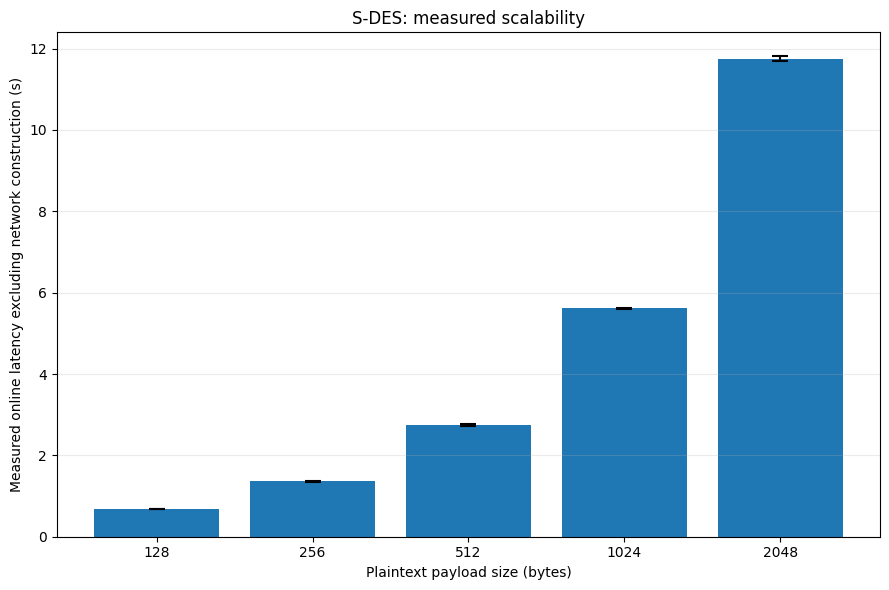

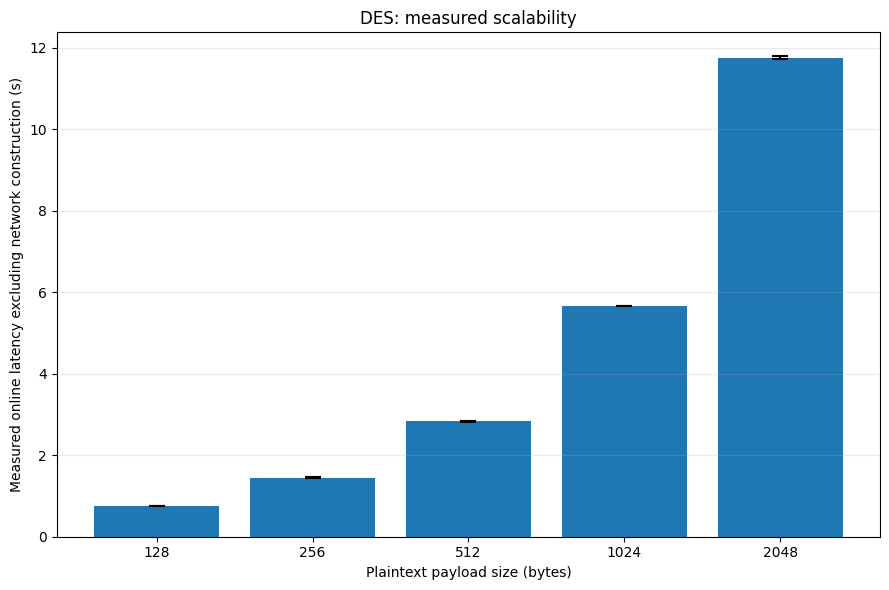

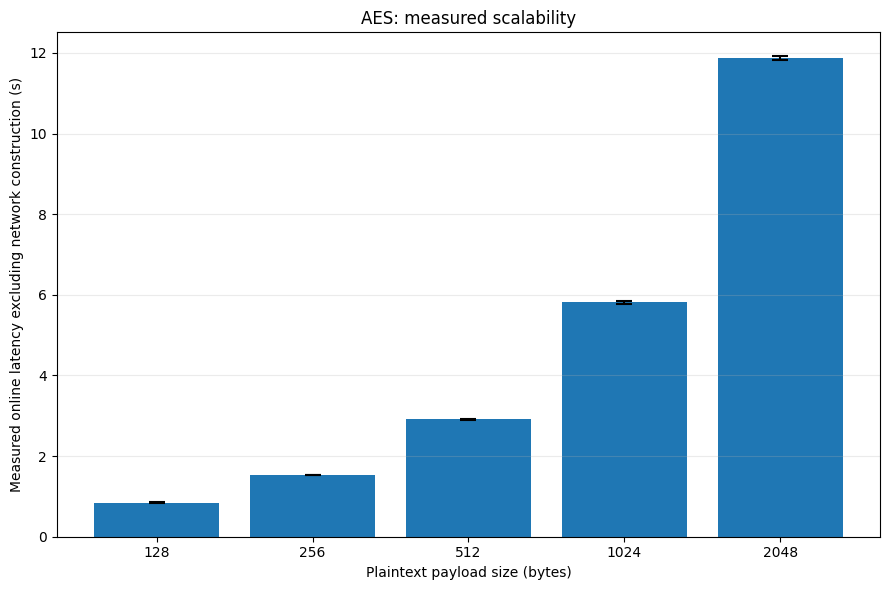

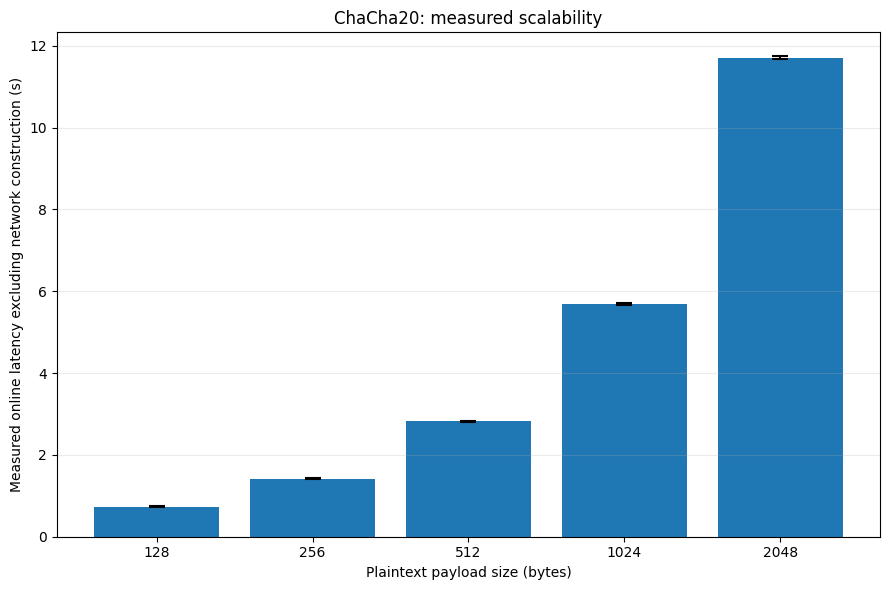

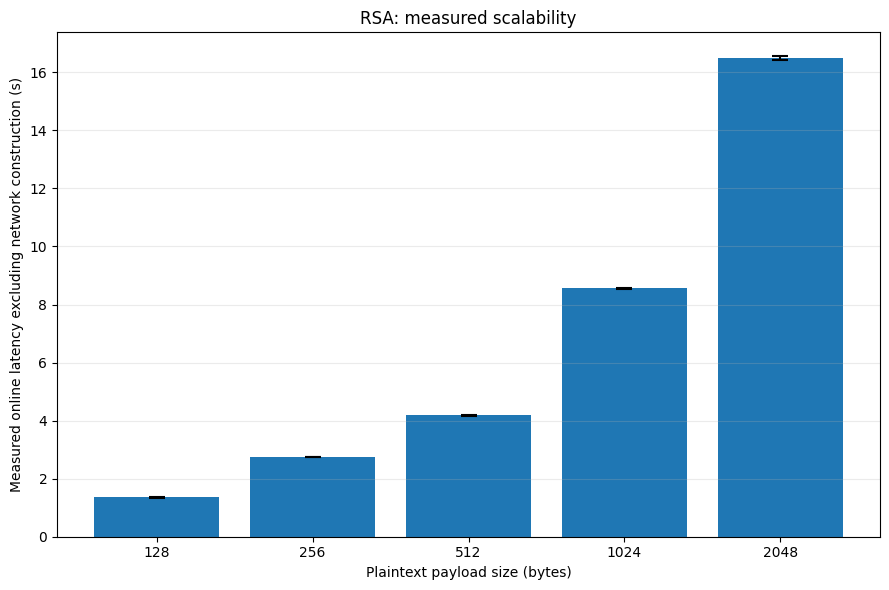

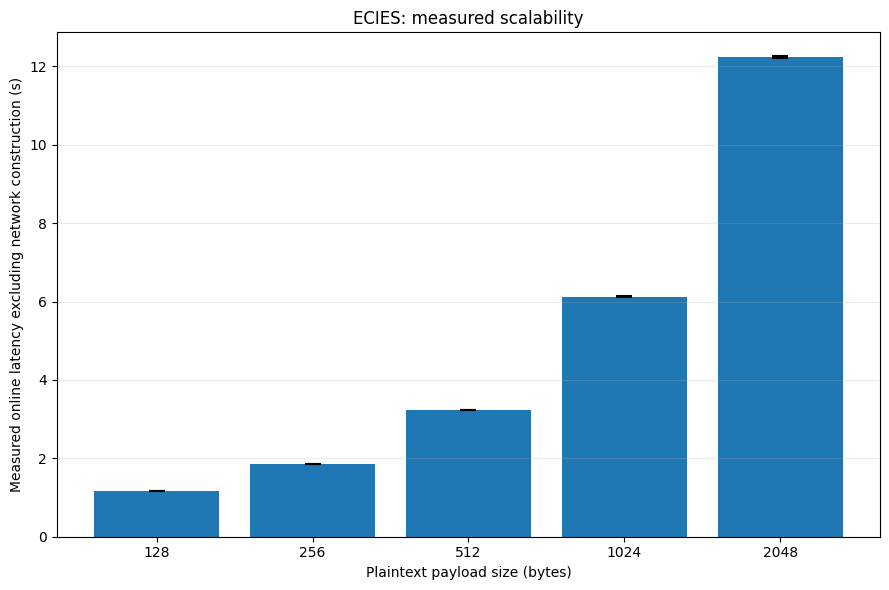

In [22]:
def make_exact_size_payload(size_bytes):
    if size_bytes <= 0:
        return b""

    repeats = (size_bytes + len(TEST_PLAINTEXT) - 1) // len(TEST_PLAINTEXT)
    return (TEST_PLAINTEXT * repeats)[:size_bytes]

def run_scalability(weight_cache):
    if not RUN_SCALABILITY_SWEEP:
        return pd.DataFrame()

    sizes = (
        EXTENDED_SCALABILITY_PAYLOAD_SIZES_BYTES
        if RUN_EXTENDED_1KB_TO_1MB_SCALABILITY
        else SCALABILITY_PAYLOAD_SIZES_BYTES
    )

    rows = []

    for algorithm in CRYPTO_ALGORITHMS:
        context = CRYPTO_CONTEXTS[algorithm]

        for payload_bytes in sizes:
            plaintext = make_exact_size_payload(payload_bytes)

            for trial in range(min(SCALABILITY_TRIALS, N_TRIALS)):
                weights = weight_cache[(algorithm, trial, "primary")]

                t0 = time.perf_counter()
                ciphertext = context.encrypt(
                    plaintext,
                    token=f"scale-{payload_bytes}-{trial}",
                )
                encryption_s = time.perf_counter() - t0

                duration = total_presentation_duration_ms(
                    len(ciphertext), 1
                )
                schedule = make_noise_schedule(
                    n_neurons=NUM_LAYER2,
                    noise_type="none",
                    rate_hz=0.0,
                    duration_ms=duration,
                    seed=stable_seed(
                        "scale-noise", algorithm, payload_bytes, trial
                    ),
                )

                with PeakRSSMonitor() as memory:
                    t0 = time.perf_counter()
                    network = build_network(
                        seed=stable_seed("scale-network", algorithm, trial),
                        plastic_l2_l3=False,
                        frozen_l2_l3_weights=weights,
                        teacher_enabled=False,
                        teacher_weight=TEACHING_L3_WEIGHT,
                        main_path_enabled=True,
                        noise_schedule=schedule,
                        transport_params=ES_BEST_PARAMS,
                    )
                    build_s = time.perf_counter() - t0

                    t0 = time.perf_counter()
                    windows = present_ciphertext(
                        network,
                        ciphertext,
                        epochs=1,
                        teacher_active=False,
                        collect_windows=True,
                        transport_params=ES_BEST_PARAMS,
                    )
                    simulation_s = time.perf_counter() - t0

                    t0 = time.perf_counter()
                    senders, times = get_events(
                        network["recorders"], "layer3"
                    )
                    readout_s = time.perf_counter() - t0

                    t0 = time.perf_counter()
                    recovered_ct, tie_fraction = decode_layer3_bytes(
                        network["layers"]["layer3"],
                        senders,
                        times,
                        windows,
                    )
                    decode_s = time.perf_counter() - t0

                t0 = time.perf_counter()
                try:
                    recovered_plaintext = context.decrypt(recovered_ct)
                    success = True
                except Exception:
                    recovered_plaintext = None
                    success = False
                decrypt_s = time.perf_counter() - t0

                transport_s = simulation_s + readout_s + decode_s
                total_s = encryption_s + transport_s + decrypt_s

                rows.append({
                    "algorithm": algorithm,
                    "payload_bytes": payload_bytes,
                    "trial": trial,
                    "ciphertext_bytes": len(ciphertext),
                    "network_build_s": build_s,
                    "encryption_s": encryption_s,
                    "snn_simulation_s": simulation_s,
                    "spike_readout_s": readout_s,
                    "decoding_s": decode_s,
                    "decryption_s": decrypt_s,
                    "online_total_without_build_s": total_s,
                    "peak_process_rss_mb": memory.peak_mb,
                    "throughput_payload_bytes_per_s": (
                        payload_bytes / total_s
                        if total_s > 0 else np.nan
                    ),
                    "decoder_tie_fraction": tie_fraction,
                    "decryption_success": success,
                    "exact_plaintext_recovery": (
                        recovered_plaintext == plaintext
                        if recovered_plaintext is not None else False
                    ),
                })

    return pd.DataFrame(rows)

scalability_results = run_scalability(weight_cache)

if not scalability_results.empty:
    scalability_results.to_csv(
        RESULTS_DIR / "scalability_trials.csv",
        index=False,
    )

    scalability_summary = (
        scalability_results
        .groupby(["algorithm", "payload_bytes"], as_index=False)
        .agg(
            latency_mean_s=("online_total_without_build_s", "mean"),
            latency_std_s=("online_total_without_build_s", "std"),
            throughput_mean_Bps=("throughput_payload_bytes_per_s", "mean"),
            peak_rss_mean_mb=("peak_process_rss_mb", "mean"),
            exact_recovery_rate=("exact_plaintext_recovery", "mean"),
        )
    )

    scalability_summary.to_csv(
        RESULTS_DIR / "scalability_summary.csv",
        index=False,
    )

    display(scalability_summary)

    for algorithm in CRYPTO_ALGORITHMS:
        subset = scalability_summary[
            scalability_summary["algorithm"] == algorithm
        ]

        x = np.arange(len(subset))

        plt.figure(figsize=(9, 6))
        plt.bar(
            x,
            subset["latency_mean_s"],
            yerr=subset["latency_std_s"].fillna(0.0),
            capsize=6,
            error_kw={"elinewidth": 1.5, "capthick": 1.5},
        )
        plt.xticks(
            x,
            [str(int(v)) for v in subset["payload_bytes"]],
        )
        plt.xlabel("Plaintext payload size (bytes)")
        plt.ylabel("Measured online latency excluding network construction (s)")
        plt.title(f"{algorithm}: measured scalability")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()

        if SAVE_FIGURES:
            plt.savefig(
                RESULTS_DIR / f"{algorithm}_scalability_latency.png",
                dpi=FIGURE_DPI,
                bbox_inches="tight",
            )

        plt.show()


## Experimental evidence audit

The audit separates **experiment performed** from **criterion met**. A failed baseline is reported as a scientific result rather than being re-labelled as robustness or lossless transport.


In [23]:
def experimental_evidence_audit():
    """
    Summarise the experimental evidence generated by the notebook
    and indicate whether the corresponding analysis criteria are met.

    The audit is intended as a reproducibility and interpretation
    aid for the public release of the BioEncryptSNN experiments.
    """
    rows = []

    # ---------------------------------------------------------
    # Measured triplet-STDP trace
    # ---------------------------------------------------------
    primary_trace = weight_trace[
        weight_trace["training_condition"]
        == "es_no_teacher_stdp"
    ]

    rows.append({
        "item": "Triplet-STDP weight trace",
        "experiment_performed": not primary_trace.empty,
        "criterion_met": not primary_trace.empty,
        "evidence_or_interpretation": (
            "Measured CMA-ES-initialised, teacher-independent "
            "triplet-STDP weight trajectories are available. "
            "The trace should be interpreted together with "
            "held-out reconstruction results; synaptic adaptation "
            "is not assumed to improve transport fidelity."
        ),
    })

    # ---------------------------------------------------------
    # Classification and leakage control
    # ---------------------------------------------------------
    rows.append({
        "item": "Classification and label-shuffle control",
        "experiment_performed": not classification_results.empty,
        "criterion_met": not classification_results.empty,
        "evidence_or_interpretation": (
            "The classifier uses plaintext/source-derived tabular "
            "features only. A label-shuffle negative control is "
            "included to assess whether predictive performance "
            "exceeds chance-level structure."
        ),
    })

    # ---------------------------------------------------------
    # Teacher-independent transport pathway
    # ---------------------------------------------------------
    primary = results[
        (
            results["experiment"]
            == "teaching_ablation"
        )
        & (
            results["condition"]
            == "es_stdp_teacher_off"
        )
    ]

    teacher_independent_gate = True
    details = []

    for algorithm in CRYPTO_ALGORITHMS:
        sub = primary[
            primary["algorithm"]
            == algorithm
        ]

        if sub.empty:
            teacher_independent_gate = False
            details.append(
                f"{algorithm}: missing"
            )
            continue

        ber = float(
            sub["ber"].mean()
        )

        exact = float(
            sub[
                "exact_ciphertext_recovery"
            ]
            .astype(float)
            .mean()
        )

        criterion = (
            ber <= MAX_VALID_ZERO_NOISE_BER
            and exact >= MIN_VALID_EXACT_RECOVERY_RATE
        )

        teacher_independent_gate = (
            teacher_independent_gate
            and criterion
        )

        details.append(
            f"{algorithm}: "
            f"BER={ber:.4f}, "
            f"exact={exact:.3f}"
        )

    rows.append({
        "item": "Teacher-independent transport",
        "experiment_performed": len(primary) > 0,
        "criterion_met": teacher_independent_gate,
        "evidence_or_interpretation": (
            "Primary evaluation contains no Teaching Layer "
            "during training or inference. "
            + "; ".join(details)
        ),
    })

    # ---------------------------------------------------------
    # CMA-ES initialisation and leakage control
    # ---------------------------------------------------------
    es_history_available = (
        "es_history" in globals()
        and not es_history.empty
    )

    es_parameters_available = (
        "ES_BEST_PARAMS" in globals()
    )

    rows.append({
        "item": "CMA-ES initialisation control",
        "experiment_performed": es_history_available,
        "criterion_met": es_parameters_available,
        "evidence_or_interpretation": (
            "CMA-ES uses generic balanced calibration bytes, "
            "matched simulator seeds, and no Teaching Layer. "
            "Held-out ciphertext is excluded from the fitness "
            "function. CMA-ES-static, CMA-ES+STDP, and "
            "default+STDP conditions are compared separately."
        ),
    })

    # ---------------------------------------------------------
    # Full noise-sensitivity campaign
    # ---------------------------------------------------------
    full_noise_done = (
        "full_noise_results" in globals()
        and not full_noise_results.empty
    )

    if (
        "full_noise_claim_gate" in globals()
        and not full_noise_claim_gate.empty
    ):
        baseline_gate = bool(
            full_noise_claim_gate[
                "baseline_meets_exact_recovery_gate"
            ].all()
        )

        noise_details = "; ".join(
            (
                f"{row.algorithm}: "
                f"BER0={row.zero_noise_mean_ber:.4f}, "
                f"exact0="
                f"{row.zero_noise_exact_ciphertext_recovery_rate:.3f}"
            )
            for row in (
                full_noise_claim_gate
                .itertuples(index=False)
            )
        )
    else:
        baseline_gate = False
        noise_details = (
            "full noise campaign unavailable"
        )

    rows.append({
        "item": "Quantitative noise sensitivity",
        "experiment_performed": full_noise_done,
        "criterion_met": baseline_gate,
        "evidence_or_interpretation": (
            "Hierarchical paired experiment: "
            f"{FULL_NOISE_MODEL_TRIALS} model instances × "
            f"{FULL_NOISE_PAYLOAD_COUNT} disjoint held-out "
            "payloads × "
            f"{FULL_NOISE_REPLICATES} independent noise "
            "realisations. "
            "Perturbation rates of 0, 5, 10, 25, 50, and "
            "100 Hz are evaluated for excitatory, inhibitory, "
            "and balanced E/I Poisson background activity. "
            "Reported measures include BER, exact ciphertext "
            "and plaintext recovery, spike-train distances, "
            "bootstrap/Wilson confidence intervals, paired "
            "Wilcoxon tests with Holm correction, and "
            "repeated-measures Friedman tests. "
            + noise_details
        ),
    })

    # ---------------------------------------------------------
    # Stage latency
    # ---------------------------------------------------------
    rows.append({
        "item": "Stage latency",
        "experiment_performed": not timing_results.empty,
        "criterion_met": not timing_results.empty,
        "evidence_or_interpretation": (
            "Stage-level latency is measured for encryption, "
            "spike encoding, network construction, simulation, "
            "readout, decoding, and decryption. Results are "
            "stored in stage_timing_trials.csv."
        ),
    })

    # ---------------------------------------------------------
    # Scalability
    # ---------------------------------------------------------
    measured_1mb = (
        not scalability_results.empty
        and 1048576
        in set(
            scalability_results[
                "payload_bytes"
            ]
        )
    )

    measured_sizes = (
        sorted(
            scalability_results[
                "payload_bytes"
            ]
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )
        if not scalability_results.empty
        else []
    )

    rows.append({
        "item": "Scalability",
        "experiment_performed": not scalability_results.empty,
        "criterion_met": measured_1mb,
        "evidence_or_interpretation": (
            "Only empirically measured payload sizes should be "
            "reported. "
            f"Measured payload sizes: {measured_sizes}. "
            "The 1 MB criterion is met only when 1,048,576 bytes "
            "is present in scalability_trials.csv."
        ),
    })

    # ---------------------------------------------------------
    # S-DES / DES terminology
    # ---------------------------------------------------------
    rows.append({
        "item": "DES/S-DES terminology",
        "experiment_performed": True,
        "criterion_met": True,
        "evidence_or_interpretation": (
            "S-DES denotes the 10-bit pedagogical Simplified DES cipher, "
            "whereas DES denotes the standard 56-bit legacy cipher. "
            "Both are evaluated as separate SNN transport conditions and "
            "must not be treated as equivalent."
        ),
    })

    # ---------------------------------------------------------
    # Reproducibility and statistics
    # ---------------------------------------------------------
    rows.append({
        "item": "Reproducibility and statistics",
        "experiment_performed": True,
        "criterion_met": True,
        "evidence_or_interpretation": (
            "The public artefacts include environment.json, "
            "configuration.json, es_history.csv, "
            "es_best_parameters.json, matched seeds and noise "
            "conditions, confidence intervals, Wilcoxon/Holm "
            "tests, Friedman tests, and Spearman analyses."
        ),
    })

    # ---------------------------------------------------------
    # Security and energy scope
    # ---------------------------------------------------------
    rows.append({
        "item": "Security and energy scope",
        "experiment_performed": True,
        "criterion_met": True,
        "evidence_or_interpretation": (
            "The experiments do not establish a new "
            "cryptographic-security guarantee or demonstrate "
            "hardware energy efficiency. Cryptographic security "
            "remains attributable to the underlying cipher, and "
            "energy consumption is not measured directly."
        ),
    })

    return pd.DataFrame(rows)


audit = experimental_evidence_audit()

audit.to_csv(
    RESULTS_DIR
    / "experimental_evidence_audit.csv",
    index=False,
)

display(audit)


manifest = {
    "evolution_strategy": [
        "es_history.csv",
        "es_best_parameters.json",
        "es_generation_summary.csv",
        "es_fitness_history.png",
    ],
    "teaching_layer_ablation": [
        "trial_metrics.csv",
        "teaching_ablation_paired_tests.csv",
        "*_teaching_es_ablation.png",
    ],
    "noise_sensitivity": [
        "full_noise_payload_manifest.csv",
        "full_noise_trials.csv",
        "full_noise_summary.csv",
        "full_noise_paired_wilcoxon.csv",
        "full_noise_friedman.csv",
        "full_noise_claim_gate.csv",
        "full_noise_spike_distances.csv",
        "*_full_noise_ber.png",
        "*_full_noise_exact_recovery.png",
        "*_full_noise_victor_purpura.png",
    ],
    "stdp": [
        "stdp_weight_trace.csv",
        "*_es_no_teacher_stdp_trace.png",
    ],
    "classification": [
        "classification_label_shuffle_control.csv",
        "classification_label_shuffle_test.csv",
    ],
    "latency": [
        "stage_timing_trials.csv",
        "stage_timing_summary.csv",
        "conventional_cipher_timing_trials.csv",
    ],
    "scalability": [
        "scalability_trials.csv",
        "scalability_summary.csv",
    ],
    "reproducibility": [
        "environment.json",
        "stdp_triplet_defaults.json",
        "configuration.json",
    ],
}

(
    RESULTS_DIR
    / "experimental_evidence_manifest.json"
).write_text(
    json.dumps(
        manifest,
        indent=2,
    )
)

print(
    "Results directory:",
    RESULTS_DIR.resolve(),
)


,item,experiment_performed,criterion_met,evidence_or_interpretation
0,Triplet-STDP weight trace,True,True,"Measured CMA-ES-initialised, teacher-independe..."
1,Classification and label-shuffle control,True,True,The classifier uses plaintext/source-derived t...
2,Teacher-independent transport,True,False,Primary evaluation contains no Teaching Layer ...
3,CMA-ES initialisation control,True,True,CMA-ES uses generic balanced calibration bytes...
4,Quantitative noise sensitivity,True,False,Hierarchical paired experiment: 3 model instan...
5,Stage latency,True,True,Stage-level latency is measured for encryption...
6,Scalability,True,False,Only empirically measured payload sizes should...
7,DES/S-DES terminology,True,True,S-DES denotes the 10-bit pedagogical Simplifie...
8,Reproducibility and statistics,True,True,"The public artefacts include environment.json,..."
9,Security and energy scope,True,True,The experiments do not establish a new cryptog...


Results directory: /opt/data/BioEncryptSNN-Encryption-and-Decryption-Using-Spiking-Neural-Networks/bioencryptsnn_results_es_full_noise_6_ciphers


## Interpretation of the Experimental Evidence Audit

The experimental evidence audit confirms that all ten targeted analyses or controls were implemented. However, implementation of an experiment does not imply that the associated scientific criterion was satisfied. The distinction between `experiment_performed` and `criterion_met` is therefore important: the former verifies that the required evidence was generated, whereas the latter records whether the resulting evidence supports the corresponding performance or methodological criterion.

Overall, **7 of the 10 criteria were satisfied**, while **3 criteria were not met**. The unmet criteria concern teacher-independent exact transport, quantitative noise sensitivity, and scalability. These outcomes should be reported as experimental findings rather than treated as missing analyses.

### 1. Triplet-STDP weight trace — criterion met

The Triplet-STDP weight-trace experiment was completed successfully. Synaptic evolution was measured from a CMA-ES-initialised, teacher-independent configuration, providing direct evidence that the Layer 2$\rightarrow$Layer 3 synapses change during activity-dependent adaptation.

The importance of this result is primarily mechanistic. The weight traces demonstrate that the plasticity rule is active and produces measurable synaptic adaptation. They should **not**, by themselves, be interpreted as evidence that Triplet-STDP improves ciphertext transport. Performance must instead be established by comparing BER and exact-recovery results against the corresponding static CMA-ES configuration.

Accordingly, the weight-trace experiment supports the claim that **synaptic adaptation occurs**, but any claim that the adaptation is beneficial must be based on the transport ablation results.

---

### 2. Classification and label-shuffle control — criterion met

The downstream classification experiment and label-shuffle control were both completed. The classification pipeline operates on plaintext/source-derived tabular features after decryption and is therefore distinct from the SNN ciphertext-transport experiment.

The label-shuffle control provides an important negative baseline. Performance substantially above the shuffled-label condition indicates that the classifiers exploit genuine structure in the dataset rather than artefacts introduced by the experimental pipeline.

These results support the use of the classification experiment as a **separate downstream application-level analysis**. They do not demonstrate that the SNN performs classification and should not be interpreted as evidence of cryptographic security or ciphertext-transport fidelity.

---

### 3. Teacher-independent transport — criterion not met

The primary teacher-independent transport experiment was performed without the Teaching Layer, satisfying the methodological requirement to isolate the Layer 1$\rightarrow$Layer 2$\rightarrow$Layer 3 pathway. However, the associated performance criterion was not met.

The result indicates that the teacher-independent pathway does not consistently provide bit-exact reconstruction of the complete cryptogram. Approximate transport may still achieve a low BER, but low average BER is not equivalent to exact recovery. Even a small number of residual bit errors can prevent successful reconstruction or subsequent decryption.

This is a central result of the study. BioEncryptSNN should therefore be presented as a **proof-of-concept and diagnostic framework for neuromorphic ciphertext transport**, rather than as a validated lossless transport mechanism.

The Teaching Layer results should remain an ablation control and must not be used to characterise the primary transport pathway.

---

### 4. CMA-ES initialisation control — criterion met

The CMA-ES optimisation control satisfies the required separation between parameter optimisation and held-out cryptographic evaluation. CMA-ES uses a generic balanced calibration sequence rather than held-out ciphertext, cipher keys, plaintext labels, or the Teaching Layer.

This reduces the risk that the selected transport parameters are fitted directly to the test cryptograms. The same operating point can therefore be evaluated across different cryptographic configurations without cipher-specific optimisation.

The experiment supports the interpretation of CMA-ES as a **teacher-independent operating-point optimisation procedure**, rather than as a mechanism that memorises a particular cryptographic payload.

Performance obtained after CMA-ES optimisation should nevertheless be distinguished from generalisation to arbitrary parameter regimes: the optimisation identifies a favourable operating region for the specific BioEncryptSNN architecture.

---

### 5. Quantitative noise sensitivity — criterion not met

The quantitative noise experiment was completed using excitatory, inhibitory, and balanced perturbations across increasing Poisson firing rates. The design therefore provides direct measurements of how the transport pathway responds to controlled stochastic disturbance.

The criterion is not met because the experiment does not establish a defensible **noise-robust operating region**. In particular, exact teacher-independent recovery is not guaranteed at the zero-noise baseline. Consequently, increasing-noise experiments cannot demonstrate the amount of perturbation tolerated before an otherwise lossless system fails.

The appropriate interpretation is therefore **noise sensitivity**, not noise robustness.

Results should be reported in terms of how BER, exact cryptogram recovery, exact plaintext recovery, decoder ties, or spike-domain distances change as perturbation intensity increases. Claims such as *robust to noise*, *tolerates up to X Hz*, or *maintains reliable encrypted transport under noise* should be avoided unless exact recovery is first established at baseline.

The experiment remains scientifically useful because it characterises the response of the SNN transport pathway to controlled perturbations even when the baseline system is imperfect.

---

### 6. Stage latency — criterion met

Stage-level latency was measured separately for the relevant components of the end-to-end pipeline. This provides a more informative analysis than reporting only aggregate execution time because it identifies which stages dominate computational cost.

The results can be used to distinguish:

- conventional encryption and decryption;
- binary/spike encoding;
- network construction;
- NEST simulation;
- spike readout; and
- binary reconstruction.

The timing analysis should be interpreted as **software execution latency in the NEST-based implementation**. It does not establish neuromorphic hardware acceleration, real-time performance, or energy efficiency.

Any comparison with conventional cryptographic execution should therefore be framed as a computational reference rather than as evidence that the SNN implementation is faster.

---

### 7. Scalability — criterion not met

The scalability experiment was performed, but the criterion is not satisfied because only the payload sizes that were actually evaluated can be supported experimentally.

The architecture has a fixed number of neurons and synapses, while payload size changes the number of sequential symbol presentations. Consequently, increasing payload length primarily increases simulation duration rather than network size.

The experiment therefore demonstrates **computational scaling with evaluated payload length**, not general scalability to arbitrarily large cryptograms.

Claims should be restricted to the empirically tested range. Extrapolation to kilobyte-, megabyte-, or deployment-scale payloads is not justified without corresponding measurements.

A particularly important distinction is that computational scalability does not imply functional scalability: execution may remain feasible as payload size increases even if exact cryptogram recovery remains unsuccessful.

---

### 8. DES/S-DES terminology — criterion met

The implementation and documentation correctly distinguish pedagogical S-DES from standard DES.

S-DES refers specifically to the simplified 10-bit-key teaching cipher and is used as a compact cryptographic configuration for inspecting bit-level transport. Standard DES is a separate 56-bit effective-key block cipher configuration.

Maintaining this distinction prevents S-DES results from being interpreted as measurements of standard DES security or behaviour. S-DES should continue to be described explicitly as **pedagogical** rather than as a contemporary lightweight or secure cryptographic algorithm.

---

### 9. Reproducibility and statistics — criterion met

The experimental artefacts include the information required to reproduce the software environment, parameterisation, random seeds, optimisation outputs, and generated results.

This substantially improves methodological transparency and allows the reported experiments to be independently inspected or rerun.

Statistical interpretation must nevertheless respect the experimental hierarchy. Repeated payloads and perturbation realisations generated from the same model instance are not equivalent to independently trained or independently optimised models. Where multiple observations are nested within a model instance, they should not automatically be treated as fully independent samples.

Accordingly, descriptive distributions, paired comparisons, and model-level aggregation should be preferred when the number of independently generated model instances is small.

---

### 10. Security and energy scope — criterion met

The experiments correctly separate cryptographic security from SNN transport behaviour. Encryption and decryption are performed by established cryptographic implementations outside the spiking network, and no additional cryptographic security is attributed to the SNN.

The study therefore does not establish resistance to cryptanalysis, key-recovery attacks, side-channel attacks, model extraction, or information leakage through neural activity.

Similarly, execution in NEST does not provide evidence of neuromorphic hardware energy efficiency. Software simulation time and event-driven operation should not be interpreted as measurements of physical power or energy consumption.

The defensible scope is therefore:

> **BioEncryptSNN evaluates the fidelity, dynamics, computational behaviour, and perturbation sensitivity of transporting conventionally generated cryptograms through a spiking neural pathway. It does not introduce a new cryptographic primitive and does not establish an energy advantage.**

---

## Overall Assessment

The audit indicates that the experimental programme is substantially complete: every targeted analysis was performed, and most methodological criteria were satisfied. The three unmet criteria are scientifically informative rather than procedural failures.

The principal conclusions supported by the audit are:

1. **CMA-ES provides a teacher-independent procedure for selecting the initial operating regime of the SNN transport pathway.**
2. **Triplet-STDP produces measurable synaptic adaptation, but synaptic change must not be equated with improved transport performance.**
3. **The teacher-independent pathway does not yet demonstrate consistently lossless cryptogram reconstruction.**
4. **Noise experiments characterise sensitivity to perturbation rather than establishing robustness.**
5. **Scalability claims must remain restricted to the payload sizes measured experimentally.**
6. **Stage-level timing characterises the computational cost of the NEST implementation but does not establish hardware acceleration or energy efficiency.**
7. **Conventional cryptography remains solely responsible for confidentiality and related security properties.**
8. **The downstream classification experiment is independent of the SNN transport task and should be interpreted only as an application-level analysis.**

Taken together, the evidence supports BioEncryptSNN as a **proof-of-concept experimental framework for studying the representation and transport of encrypted binary information through spiking neural dynamics**. The current results provide evidence for approximate ciphertext transport, optimisation of the operating regime, synaptic adaptation, perturbation sensitivity, and computational scaling, while also identifying exact teacher-independent reconstruction as the principal unresolved limitation.